**Escenario**: Validacion de ingresos declarados / Income Consistency Validator

**Uso del modelo**: estimar ingreso esperado y compararlo contra el ingreso declarado para generar alertas de posible inconsistencia.

**Target de entrenamiento**: ingreso real observado en nomina.

**Poblacion de inferencia**: nuevos solicitantes de credito con variables disponibles al momento de solicitud.

# Avance 1 - Preparacion de datos previo EDA

**1.Objetivo**: preparar e integrar las diferentes fuentes de datos disponibles para el proyecto de estimacion de ingresos.

Antes de realizar el análisis exploratorio de datos (EDA), se ejecutan tareas de lectura, limpieza, validación de llaves, transformación de variables y consolidacion de un dataframe maestro o final.

Las fuentes utilizadas son:

- Datos de nomina
- Datos sociodemograficos
- Datos de direcciones
- Datos de coordenadas
- Datos de movilidad derivados de Google Maps
- Datos de buro

**2. Libreras**

In [1]:
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 80)

**3. Lectura de archivos**

In [178]:
df_coord[df_coord['aux_direccion'].str.contains('TEMIS207')]

,latitude,longitude,score,direccion_sugerida,direccion,aux_direccion
232047,25.739348,-100.292171,97.4,"Calle Temis 207, Residencial Nova, San NicolÃ¡s De Los Garza, Nuevo LeÃ³n, 6...","TEMIS 207 ,RESIDENCIAL NOVA ,SAN NICOLáS DE LOS GARZA ,66464 ,NL","TEMIS207,RESIDENCIALNOVA,SANNICOLáSDELOSGARZA,66464,NL"


In [182]:
df_master_final[df_master_final['NUMERO_CLIENTE']==2254981]['AUX_DIRECCION'].iloc[0]

'TEMIS207,RESIDENCIALNOVA,SANNICOLáSDELOSGARZA,66464,NL'

In [181]:
a='TEMIS207,RESIDENCIALNOVA,SANNICOLáSDELOSGARZA,66464,NL'
b='TEMIS207,RESIDENCIALNOVA,SANNICOLáSDELOSGARZA,66464,NL'
a==b

True

In [2]:
path = r"C:\Users\cesar\Downloads\DataBaseAfirme"


df_nomina = pd.read_csv(
    f"{path}\\bd_datos_nomima.txt",
    sep="|",
    encoding="latin1"
)

df_socio = pd.read_csv(
    f"{path}\\bd_datos_sociodemograficos.txt",
    sep="|",
    encoding="latin1"
)

df_direcciones = pd.read_csv(
    f"{path}\\bd_poblacion_direcciones.txt",
    sep="|",
    encoding="latin1"
)

df_coord = pd.read_csv(
    f"{path}\\bd_poblacion_coordenadas.txt",
    sep="|",
    encoding="latin1"
)

cols_maps = [
    "vect_dist_clean",
    "text_busq_st_code_traffic_clean",
    "text_busq_min_time_clean",
    "text_busq_max_time_clean",
    "direccion", #direccion_af
    "TRACUN_MASK" #TRACUN
]

df_maps = pd.read_csv(
    f"{path}\\info_google_final.txt",
    sep="|",
    encoding="latin1",
    usecols=cols_maps
)

# Bases de datos buro
df_buro_poblacion = pd.read_csv(
    f"{path}\\bd_poblacion_consulta_buro.txt",
    sep="|",
    encoding="latin1"
)

df_buro_consultas = pd.read_csv(
    f"{path}\\bd_cons_buro_vers.txt",
    sep="|",
    encoding="latin1"
)

df_buro_direcciones = pd.read_csv(
    f"{path}\\bd_variables_dirs_buro.txt",
    sep="|",
    encoding="latin1"
)

df_buro_cuentas = pd.read_csv(
    f"{path}\\bd_cuentas_buro.txt",
    sep="|",
    encoding="latin1"
)


print(df_nomina.shape)
print(df_socio.shape)
print(df_direcciones.shape)
print(df_coord.shape)
print(df_maps.shape)

print("Bases Buro")
print(df_buro_poblacion.shape)
print(df_buro_consultas.shape)
print(df_buro_direcciones.shape)
print(df_buro_cuentas.shape)

C:\Users\cesar\AppData\Local\Temp\ipykernel_8900\4033319121.py:16: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_direcciones = pd.read_csv(


(395817, 10)
(410308, 5)
(410308, 12)
(393941, 5)
(247635, 6)
Bases Buro
(40656, 4)
(40715, 11)
(40656, 8)
(40715, 26)


Las fuentes de datos presentan tamaños diferentes, lo cual nos indica que no todas las bases contienen exactamente la misma poblacion de clientes. Por esta razon antes de construir el dataset maestro es necesario validar las llaves de union por cliente y la cobertura entre fuentes.

La base de nomina será la fuente principal, ya que contiene la variable objetivo `AVG_ING_MENSUAL`. Las demas fuentes se integraran como variables explicativas siempre que exista correspondencia mediante `NUMERO_CLIENTE`.

**4. Exploracion inicial de estructura**

In [33]:
def resumen_estructura(nombre, df):
    print("=" * 70)
    print(f"DATAFRAME: {nombre}")
    print("=" * 70)
    print(f"Filas: {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]:,}")
    print("\nColumnas:")
    print(df.columns.tolist())
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nPrimeros registros:")
    display(df.head(3))

resumen_estructura("Nomina", df_nomina)
resumen_estructura("Sociodemografico", df_socio)
resumen_estructura("Direcciones", df_direcciones)
resumen_estructura("Coordenadas", df_coord)
resumen_estructura("Google Maps", df_maps)

resumen_estructura("Buro poblacion", df_buro_poblacion)
resumen_estructura("Buro consultas", df_buro_consultas)
resumen_estructura("Buro direcciones", df_buro_direcciones)
resumen_estructura("Buro cuentas", df_buro_cuentas)

DATAFRAME: Nomina
Filas: 395,817
Columnas: 10

Columnas:
['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'AVG_DAYS_FREQ', 'MEDIANA_ING_MENSUAL', 'AVG_ING_MENSUAL', 'FECHA_FIRST_DEPOSITO', 'MONTH_LAST_DEPOSITO', 'FECHA_RANGO_IZQ', 'FECHA_LAST_DEPOSITO', 'NUMERO_CLIENTE']

Tipos de datos:
NUM_EMPRESAS                     int64
MEDIANA_DAYS_FREQ              float64
AVG_DAYS_FREQ                  float64
MEDIANA_ING_MENSUAL            float64
AVG_ING_MENSUAL                float64
FECHA_FIRST_DEPOSITO    datetime64[ns]
MONTH_LAST_DEPOSITO     datetime64[ns]
FECHA_RANGO_IZQ         datetime64[ns]
FECHA_LAST_DEPOSITO     datetime64[ns]
NUMERO_CLIENTE                   int64
dtype: object

Primeros registros:


,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,MEDIANA_ING_MENSUAL,AVG_ING_MENSUAL,FECHA_FIRST_DEPOSITO,MONTH_LAST_DEPOSITO,FECHA_RANGO_IZQ,FECHA_LAST_DEPOSITO,NUMERO_CLIENTE
0,0,30.0,30.400000,3856.81,4285.186000,2015-01-02,2026-03-01,2025-03-01,2026-03-31,253502
1,1,15.0,15.315789,7745.80,8101.263158,2015-01-14,2026-03-01,2025-03-01,2026-03-31,976759
2,1,15.0,14.466667,11655.20,11643.901333,2015-09-28,2026-03-01,2025-03-01,2026-03-27,2064509


DATAFRAME: Sociodemografico
Filas: 410,308
Columnas: 5

Columnas:
['SEXO', 'ESTADO_CIVIL', 'FECHA_NACIMIENTO', 'FECHA_CLIENTE_DESDE', 'NUMERO_CLIENTE']

Tipos de datos:
SEXO                           object
ESTADO_CIVIL                   object
FECHA_NACIMIENTO       datetime64[ns]
FECHA_CLIENTE_DESDE    datetime64[ns]
NUMERO_CLIENTE                  int64
dtype: object

Primeros registros:


,SEXO,ESTADO_CIVIL,FECHA_NACIMIENTO,FECHA_CLIENTE_DESDE,NUMERO_CLIENTE
0,F,1,1960-05-18,2002-03-20,164228
1,M,1,1985-10-28,2005-04-07,217695
2,M,2,1960-08-18,2006-07-24,251079


DATAFRAME: Direcciones
Filas: 410,308
Columnas: 9

Columnas:
['CALLE', 'COLONIA', 'CIUDAD', 'CODIGO_ESTADO', 'CP', 'CP_CALCULADO', 'CLAVE_PAIS', 'DIRECCION', 'NUMERO_CLIENTE']

Tipos de datos:
CALLE             object
COLONIA           object
CIUDAD            object
CODIGO_ESTADO     object
CP                 Int64
CP_CALCULADO      object
CLAVE_PAIS        object
DIRECCION         object
NUMERO_CLIENTE     int64
dtype: object

Primeros registros:


...

,ID_BURO_FINAL,COUNT_6M,COUNT_9M,COUNT_12M,COUNT_18M,COUNT_24M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,NUMERO_CLIENTE
0,3297654,2,5,5,5,5,0,0.0,3.0,4.0,5354254
1,3303091,7,12,12,14,19,0,2.0,3.0,8.0,4124626
2,3310978,3,10,10,15,21,2,2.0,4.0,7.0,740046


DATAFRAME: Buro direcciones
Filas: 40,656
Columnas: 8

Columnas:
['ID_BURO_FINAL', 'FLAG_CAMBIO_3M', 'FLAG_CAMBIO_6M', 'FLAG_CAMBIO_9M', 'FLAG_CAMBIO_12M', 'FLAG_CAMBIO_18M', 'FLAG_CAMBIO_24M', 'NUMERO_CLIENTE']

Tipos de datos:
ID_BURO_FINAL      int64
FLAG_CAMBIO_3M     int64
FLAG_CAMBIO_6M     int64
FLAG_CAMBIO_9M     int64
FLAG_CAMBIO_12M    int64
FLAG_CAMBIO_18M    int64
FLAG_CAMBIO_24M    int64
NUMERO_CLIENTE     int64
dtype: object

Primeros registros:


,ID_BURO_FINAL,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M,NUMERO_CLIENTE
0,3297654,0,0,0,1,1,1,5354254
1,3303091,0,1,1,1,1,1,4124626
2,3310978,1,1,1,1,2,2,740046


DATAFRAME: Buro cuentas
Filas: 40,656
Columnas: 26

Columnas:
['ID_BURO_FINAL', 'COUNT_FLAG_CLOSED', 'COUNT_FLAG_OPEN', 'COUNT_FLAG_OTORG_AFIRME', 'COUNT_FLAG_SALDO_VDO', 'COUNT_FLAG_REEST', 'COUNT_FLAG_6M', 'COUNT_FLAG_12M', 'COUNT_FLAG_18M', 'COUNT_FLAG_24M', 'COUNT_FLAG_MAS_24M', 'MAX_PEOR_MOP_IN_3M', 'MAX_PEOR_MOP_IN_6M', 'MAX_PEOR_MOP_IN_9M', 'MAX_PEOR_MOP_IN_12M', 'MAX_PEOR_MOP_IN_18M', 'MAX_PEOR_MOP_IN_24M', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'SUM_MONTO_OTORG', 'AVG_MESES_ENTRE_CUENTAS_APER', 'MAX_MESES_ENTRE_CUENTAS_APER', 'MIN_MESES_ENTRE_CUENTAS_APER', 'COUNT_DIST_OTORG', 'COUNT_DIST_CTO', 'NUMERO_CLIENTE']

Tipos de datos:
ID_BURO_FINAL                     int64
COUNT_FLAG_CLOSED               float64
COUNT_FLAG_OPEN                 float64
COUNT_FLAG_OTORG_AFIRME         float64
COUNT_FLAG_SALDO_VDO            float64
COUNT_FLAG_REEST                float64
COUNT_FLAG_6M                     int64
COUNT_FLAG_12M                    int64
COUNT_FLAG_18M            

,ID_BURO_FINAL,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,COUNT_FLAG_12M,COUNT_FLAG_18M,COUNT_FLAG_24M,COUNT_FLAG_MAS_24M,MAX_PEOR_MOP_IN_3M,MAX_PEOR_MOP_IN_6M,MAX_PEOR_MOP_IN_9M,MAX_PEOR_MOP_IN_12M,MAX_PEOR_MOP_IN_18M,MAX_PEOR_MOP_IN_24M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO,NUMERO_CLIENTE
0,3297654,2.0,0.0,0.0,1.0,0.0,0,1,1,1,1,2.0,2.0,2.0,2.0,2.0,2.0,4435.0,569.0,7399.0,16.500000,27.0,6.0,2,2,5354254
1,3303091,7.0,17.0,7.0,3.0,0.0,9,14,14,14,10,9.0,9.0,9.0,9.0,9.0,9.0,24368.0,12736.0,174450.0,38.333333,111.0,3.0,5,5,4124626
2,3310978,10.0,66.0,61.0,4.0,0.0,5,14,20,28,48,9.0,9.0,9.0,9.0,9.0,9.0,451507.0,5424.0,789036.0,38.131579,176.0,3.0,8,7,740046


**5. Estandarizacion de nombres y llaves**

In [3]:
df_nomina = df_nomina.rename(columns={"TRACUN": "NUMERO_CLIENTE"})
df_socio = df_socio.rename(columns={"TRACUN": "NUMERO_CLIENTE"})
df_maps = df_maps.rename(columns={"TRACUN_MASK": "NUMERO_CLIENTE"})

df_buro_consultas = df_buro_consultas.rename(
    columns={"TRACUN_MASK": "NUMERO_CLIENTE"}
)

df_buro_direcciones = df_buro_direcciones.rename(
    columns={"TRACUN_MASK": "NUMERO_CLIENTE"}
)

df_buro_cuentas = df_buro_cuentas.rename(
    columns={"TRACUN_MASK": "NUMERO_CLIENTE"}
)

In [4]:
#columnas que no se usaran
df_direcciones = df_direcciones.drop(
    columns=["Unnamed: 0", "TRACUN", "CUSCTR"],
    errors="ignore"
)

#renombrar 
df_direcciones = df_direcciones.rename(columns={
    "TRACUN_MASK": "NUMERO_CLIENTE",
    "CUSCCS": "CLAVE_PAIS",
    "CUSPOB": "CP_CALCULADO",
    "CUSZPC": "CP",
    "CUSSTE": "CODIGO_ESTADO",
    "CUSCTY": "CIUDAD",
    "CUSNA3": "CALLE",
    "CUSNA4": "COLONIA"
})

In [5]:
columnas_fecha_nomina = [
    "FECHA_FIRST_DEPOSITO",
    "MONTH_LAST_DEPOSITO",
    "FECHA_RANGO_IZQ",
    "FECHA_LAST_DEPOSITO"
]

for col in columnas_fecha_nomina:
    df_nomina[col] = pd.to_datetime(df_nomina[col], errors="coerce")

In [6]:
columnas_fecha_socio = [
    "FECHA_NACIMIENTO",
    "FECHA_CLIENTE_DESDE"
]

for col in columnas_fecha_socio:
    df_socio[col] = pd.to_datetime(
        df_socio[col], 
        errors="coerce"
    )

In [7]:
columnas_fecha_buro_poblacion = [
    "FECHA_CONS_FINAL",
    "FECHA_LAST_DEPOSITO"
]

for col in columnas_fecha_buro_poblacion:
    df_buro_poblacion[col] = (
        df_buro_poblacion[col]
        .astype("string")
        .str.strip()
    )

    df_buro_poblacion[col] = pd.to_datetime(
        df_buro_poblacion[col],
        errors="coerce",
        dayfirst=True,
        format="mixed"
    )

#Validacion
df_buro_poblacion["FECHA_CONS_FINAL"].isna().sum()

0

**6. Validacion y conversion de llaves**

In [8]:
dataframes_con_llave_cliente = {
    "df_nomina": df_nomina,
    "df_socio": df_socio,
    "df_direcciones": df_direcciones,
    "df_maps": df_maps,
    
    "df_buro_poblacion": df_buro_poblacion,
    "df_buro_consultas": df_buro_consultas,
    "df_buro_direcciones": df_buro_direcciones,
    "df_buro_cuentas": df_buro_cuentas
}

for nombre, df in dataframes_con_llave_cliente.items():
    df["NUMERO_CLIENTE"] = pd.to_numeric(df["NUMERO_CLIENTE"], errors="coerce")
    print(nombre, "nulos en NUMERO_CLIENTE:", df["NUMERO_CLIENTE"].isna().sum())
    df.dropna(subset=["NUMERO_CLIENTE"], inplace=True)
    df["NUMERO_CLIENTE"] = df["NUMERO_CLIENTE"].astype("int64")

df_nomina nulos en NUMERO_CLIENTE: 0
df_socio nulos en NUMERO_CLIENTE: 0
df_direcciones nulos en NUMERO_CLIENTE: 0
df_maps nulos en NUMERO_CLIENTE: 0
df_buro_poblacion nulos en NUMERO_CLIENTE: 0
df_buro_consultas nulos en NUMERO_CLIENTE: 59
df_buro_direcciones nulos en NUMERO_CLIENTE: 0
df_buro_cuentas nulos en NUMERO_CLIENTE: 59


La variable `NUMERO_CLIENTE` se estandarizo como entero en todas las fuentes donde aparece. Esta validacion es cirtica porque las llaves deben tener el mismo tipo de dato antes de realizar los JOIN.

In [40]:
dataframes_con_llave_buro = {
    "df_buro_poblacion": df_buro_poblacion,
    "df_buro_consultas": df_buro_consultas,
    "df_buro_direcciones": df_buro_direcciones,
    "df_buro_cuentas": df_buro_cuentas
}

for nombre, df in dataframes_con_llave_buro.items():
    df["ID_BURO_FINAL"] = pd.to_numeric(df["ID_BURO_FINAL"], errors="coerce")
    print(nombre, "nulos en ID_BURO_FINAL:", df["ID_BURO_FINAL"].isna().sum())
    df.dropna(subset=["ID_BURO_FINAL"], inplace=True)
    df["ID_BURO_FINAL"] = df["ID_BURO_FINAL"].astype("int64")

df_buro_poblacion nulos en ID_BURO_FINAL: 0
df_buro_consultas nulos en ID_BURO_FINAL: 0
df_buro_direcciones nulos en ID_BURO_FINAL: 0
df_buro_cuentas nulos en ID_BURO_FINAL: 0


In [41]:
for nombre, df in dataframes_con_llave_cliente.items():
    print("="*60)
    print(nombre)
    print("Clientes unicos:", df["NUMERO_CLIENTE"].nunique())
    print("Registros totales:", len(df))
    print("Duplicados por cliente:", df["NUMERO_CLIENTE"].duplicated().sum())

df_nomina
Clientes unicos: 395817
Registros totales: 395817
Duplicados por cliente: 0
df_socio
Clientes unicos: 410308
Registros totales: 410308
Duplicados por cliente: 0
df_direcciones
Clientes unicos: 410308
Registros totales: 410308
Duplicados por cliente: 0
df_maps
Clientes unicos: 31407
Registros totales: 247635
Duplicados por cliente: 216228
df_buro_poblacion
Clientes unicos: 40656
Registros totales: 40656
Duplicados por cliente: 0
df_buro_consultas
Clientes unicos: 40656
Registros totales: 40656
Duplicados por cliente: 0
df_buro_direcciones
Clientes unicos: 40656
Registros totales: 40656
Duplicados por cliente: 0
df_buro_cuentas
Clientes unicos: 40656
Registros totales: 40656
Duplicados por cliente: 0


**7. Limpieza y estandarizacion de direcciones**

In [9]:
df_direcciones["CP"] = (
    pd.to_numeric(df_direcciones["CP"], errors="coerce")
    .astype("Int64")
)

**8. Preparacion de coordenadas geograficas**

Coordenadas:

Antes de generar un cruce hacia la base de coordenadas haremos una variable auxiliar para cada base de datos

Estos auxiliares contemplan la direccion sin espacios para su correcto join

In [136]:
#['AUX_DIRECCION']=df_master_base['DIRECCION'].str.replace(' +','',regex=True)
from ftfy import fix_encoding
df_coord['direccion']=df_coord['direccion'].apply(fix_encoding)
df_coord['aux_direccion']=df_coord['direccion'].str.replace(' +','',regex=True)
df_coord['aux_direccion']=df_coord['aux_direccion'].str.replace(' S/N','').str.strip()
df_coord['aux_direccion']=df_coord['aux_direccion'].str.replace(' SN ','').str.strip()

In [64]:
print("Direcciones duplicadas en df_coord:")
print(df_coord["aux_direccion"].duplicated().sum())

df_coord["aux_direccion"].value_counts().head(5)

Direcciones duplicadas en df_coord:
4420


aux_direccion
ESTADIOUNIVERSITARIOPUERTA13,CIUDADUNIVERSITARIA,SANNICOLASDELOSGARZA,66455,NL    5
PRIMERA,BUENAVISTA,GENERALCEPEDA,25950,COA                                        4
-LOCPURUNGUEO,LOCPURUNGUEO,TIQUICHEODENICOLASROMERO,61370,MIC                     4
LOCPEÃ?ADELPANAL,LOCPEÃ?ADELPANAL,TARIMBARO,58880,MIC                           3
LOCTELCRUZ,LOCTELCRUZ,CUAUTITLANDEGARCIABARRAGAN,48963,JAL                        3
Name: count, dtype: int64

In [194]:
#Eliminamos los duplicados que se tienen en la columna "aux_direccion", esto es critico para no tener duplicados por numero de cliente en nuestro df final
df_coord_unique = (
    df_coord
    .sort_values("score", ascending=False)
    .drop_duplicates(subset=["aux_direccion"], keep="first")
)

In [66]:
print("Duplicados en aux_direccion:", df_coord_unique["aux_direccion"].duplicated().sum())
print("Tamaño df_coord original:", df_coord.shape)
print("Tamaño df_coord_unique:", df_coord_unique.shape)

Duplicados en aux_direccion: 0
Tamaño df_coord original: (393941, 6)
Tamaño df_coord_unique: (389521, 6)


### Validacion y consolidacion de coordenadas geograficas

Durante la integracion de la informacion geografica se identifico que la base de coordenadas contenia multiples registros asociados a una misma direccion. Esta situacion puede originarse por distintos factores entre ellos:

- multiples intentos de geocodificación realizados sobre una misma direccion
- variaciones en el formato textual de las direcciones
- respuestas diferentes provenientes de la API
- registros repetidos dentro del proceso de extraccion

Debido a esto antes de realizar la integración con el dataset maestro se llevaron a cabo validaciones para identificar direcciones duplicadas y evaluar la consistencia de las coordenadas obtenidas.

Posteriormente se construyo una tabla auxiliar unica por dirección (`df_coord_unique`) con el objetivo de evitar duplicidad de registros al momento de realizar los merges a nivel cliente.

Para conservar unicamente una coordenada representativa por direccion, se selecciono el registro con el mayor valor de `score` proporcionado por la API de geocodificacion. Este score representa el nivel de confianza o precision de la coincidencia encontrada entre la direccion original y la dirección geolocalizada.

De esta manera se priorizp la coordenada con mayor calidad geografica disponible para cada dirección, reduciendo posibles inconsistencias espaciales dentro del dataset final.

**9. Preparacion de base de datos de Google Maps**

La base de Google Maps contiene informacion de un proceso de web scraping realizado sobre direcciones de clientes. Su objetivo es sumar a el dataset con variables de movilidad y accesibilidad, tales como distancia a la sucursal bancaria mas cercana, tiempo estimado de traslado y nivel de trafico.

Estas variables pueden funcionar como proxies geograficos y de accesibilidad, ya que permiten representar que tan cerca o lejos se encuentra un cliente de una sucursal asi como las condiciones de traslado en una hora de alta demanda. Esta informacion puede ser util para el analisis exploratorio y para futuros modelos predictivos ya que la ubicacion y la movilidad pueden estar relacionadas indirectamente con caracteristicas socioeconomicas o de comportamiento financiero

In [12]:
print("Tamaño original df_maps:", df_maps.shape)
print("Duplicados:", df_maps.duplicated().sum())
print("Duplicados por cliente:", df_maps["NUMERO_CLIENTE"].duplicated().sum())

df_maps.groupby("NUMERO_CLIENTE").size().describe()

Tamaño original df_maps: (247635, 6)
Duplicados: 54704
Duplicados por cliente: 216228


count    31407.000000
mean         7.884707
std          2.490455
min          1.000000
25%          9.000000
50%          9.000000
75%          9.000000
max         18.000000
dtype: float64

Solo tenemos **31,407 clientes unicos**, en promedio **cada cliente tiene 7 registros de rutas**, algunos **clientes llegan a tener hasta 18 registros**.

El dataset de Google Maps contiene multiples registros por cliente debido a que para una misma direccion pueden existir varias rutas, tiempos o condiciones de trafico. Por este motivo antes de integrarlo con el resto de las fuentes, es necesario reducirlo a una sola fila por cliente.

Debido a que un mismo cliente puede tener multiples registros en la base de google maps, no es conveniente integrar esta tabla directamente al dataset maestro/final. Si se hiciera un JOIN sin una agregacion previa, se duplicarian clientes y se alteraria la estructura del conjunto de datos.

Se considero utilizar unicamente la distancia o tiempo minimo, ya que estos valores representan el mejor escenario posible. Sin embargo esta decision podria introducir un sesgo optimista porque asumiria que el cliente siempre enfrenta la ruta mas favorable

Por esta razon, se decidio generar variables agregadas a nivel cliente mediante estadisticas minimas, promedio y maximas. El minimo representa la mejor condición de accesibilidad, el promedio representa una condicion tipica y el maximo representa el peor escenario observado. Para la variable categorica de trafico se utilizo la moda porque permite conservar la condicion de trafico mas frecuente para cada cliente.

In [48]:
rutas_por_cliente = df_maps.groupby("NUMERO_CLIENTE").size()

rutas_por_cliente.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    31407.000000
mean         7.884707
std          2.490455
min          1.000000
50%          9.000000
75%          9.000000
90%          9.000000
95%          9.000000
99%          9.000000
max         18.000000
dtype: float64

### Analisis de número de rutas por cliente en Google Maps

Se analizo la cantidad de registros de rutas asociadas a cada cliente dentro de la base de Google Maps. Los resultados muestran que la mayoría de los clientes presentan una cantidad relativamente estable de rutas evaluadas.

La mediana observada es de 6 rutas por cliente, mientras que el percentil 75 y 90 corresponden a 9 rutas, lo cual sugiere que el proceso de scraping genero un numero relativamente consistente de sucursales o trayectos por cliente.

Sin embargo tambien se identificaron valores atipicos importantes. Aunque el 99% de los clientes tiene 40 rutas o menos, existen casos extremos con hasta 210 rutas registradas para un solo cliente. Esto indica una distribucion altamente asimetrica con cola larga hacia la derecha.

Estos valores extremos podrian estar relacionados con:
- multiples direcciones asociadas al cliente,
- duplicidad de registros,
- variaciones en el proceso de scraping,
- multiples sucursales evaluadas,
- posibles inconsistencias en la informacion geografica.

Eliminar duplicados exactos:

In [13]:
df_maps = df_maps.drop_duplicates()

In [50]:
print("Tamaño despues de eliminar:", df_maps.shape)

Tamaño despues de eliminar: (192931, 6)


Convertir distancia y tiempos

In [14]:
def distancia_a_km(valor):
    valor = str(valor).strip().lower()
    
    if "km" in valor:
        return float(valor.replace("km", "").strip())
    
    elif "metro" in valor:
        metros = float(valor.replace("metros", "").replace("metro", "").strip())
        return metros / 1000
    
    else:
        return np.nan

In [15]:
import re

def tiempo_a_minutos(valor):
    valor = str(valor).strip().lower()
    
    horas = 0
    minutos = 0
    match_horas = re.search(r"(\d+)\s*h", valor)
    match_minutos = re.search(r"(\d+)\s*min", valor)
    
    if match_horas:
        horas = int(match_horas.group(1))
    
    if match_minutos:
        minutos = int(match_minutos.group(1))
    
    if match_horas or match_minutos:
        return horas * 60 + minutos
    
    return np.nan

In [16]:
df_maps["distancia_km"] = df_maps["vect_dist_clean"].apply(distancia_a_km)
df_maps["tiempo_min_minutos"] = df_maps["text_busq_min_time_clean"].apply(tiempo_a_minutos)
df_maps["tiempo_max_minutos"] = df_maps["text_busq_max_time_clean"].apply(tiempo_a_minutos)

C:\Users\cesar\AppData\Local\Temp\ipykernel_8900\2494067865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_maps["distancia_km"] = df_maps["vect_dist_clean"].apply(distancia_a_km)
C:\Users\cesar\AppData\Local\Temp\ipykernel_8900\2494067865.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_maps["tiempo_min_minutos"] = df_maps["text_busq_min_time_clean"].apply(tiempo_a_minutos)
C:\Users\cesar\AppData\Local\Temp\ipykernel_8900\2494067865.py:3: SettingWithCopyWarning: 
A value is trying to be set on

In [54]:
df_maps.head(2)

,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion,NUMERO_CLIENTE,distancia_km,tiempo_min_minutos,tiempo_max_minutos
0,6.5 km,medium,14 min,24 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,6.5,14,24
1,6.5 km,medium,14 min,28 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,6.5,14,28


**10. Agregacion por cliente de Google Maps**

In [17]:
def moda(serie):
    conteos = serie.value_counts()
    
    if len(conteos) == 0:
        return np.nan
    
    return conteos.index[0]

Para la variable de trafico se utiliza la moda. En caso de empate entre categorias, se conserva la primera categoría retornada por `value_counts()`. Esta decision puede revisarse posteriormente si la variable resulta relevante para el modelo.

In [18]:
df_maps_agg = df_maps.groupby("NUMERO_CLIENTE", sort=False).agg(
    dist_min_km=("distancia_km", "min"),
    dist_mean_km=("distancia_km", "mean"),
    dist_max_km=("distancia_km", "max"),
    
    time_min_min=("tiempo_min_minutos", "min"),
    time_min_mean=("tiempo_min_minutos", "mean"),
    
    time_max_max=("tiempo_max_minutos", "max"),
    time_max_mean=("tiempo_max_minutos", "mean"),
    
    traffic_mode=("text_busq_st_code_traffic_clean", moda)
).reset_index()

In [57]:
df_maps_agg.head()

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
0,5495715,5.7,6.000000,6.5,14,14.000000,30,27.333333,medium
1,5996353,5.0,5.166667,5.4,12,12.000000,24,22.000000,light
2,466881,28.9,37.500000,46.1,35,42.500000,80,70.000000,medium
3,5940670,29.2,38.366667,52.3,45,50.000000,100,87.500000,medium
4,6514829,7.3,7.650000,8.0,14,15.333333,45,38.333333,hard


In [58]:
df_maps_agg["traffic_mode"] = (
    df_maps_agg["traffic_mode"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({
        "rojo": "heavy",
        "red": "heavy",
        "medium": "medium",
        "light": "light"
    })
)

### Normalizacion de categorias de trafico

La variable `traffic_mode` proveniente de Google Maps presentaba categorias en diferentes idiomas y formatos por ejemplo valores como `rojo`, `medium` y `light`.

Con el objetivo de mantener consistencia semantica y facilitar el analisis exploratorio y el posterior procesamiento del modelo, se realizo una homologacion de categorias, unificando todos los valores a un unico formato en ingles.

**11. Preparacion de bases de buro de credito**

In [59]:
buro_dfs = {
    "df_buro_poblacion": df_buro_poblacion,
    "df_buro_consultas": df_buro_consultas,
    "df_buro_direcciones": df_buro_direcciones,
    "df_buro_cuentas": df_buro_cuentas
}

for nombre, df in buro_dfs.items():
    print("=" * 60)
    print(nombre)
    print("Registros:", len(df))
    print("Clientes unicos:", df["NUMERO_CLIENTE"].nunique())
    print("Duplicados NUMERO_CLIENTE:", df["NUMERO_CLIENTE"].duplicated().sum())
    print("IDs buro unicos:", df["ID_BURO_FINAL"].nunique())
    print("Duplicados ID_BURO_FINAL:", df["ID_BURO_FINAL"].duplicated().sum())

df_buro_poblacion
Registros: 40656
Clientes unicos: 40656
Duplicados NUMERO_CLIENTE: 0
IDs buro unicos: 40653
Duplicados ID_BURO_FINAL: 3
df_buro_consultas
Registros: 40656
Clientes unicos: 40656
Duplicados NUMERO_CLIENTE: 0
IDs buro unicos: 40653
Duplicados ID_BURO_FINAL: 3
df_buro_direcciones
Registros: 40656
Clientes unicos: 40656
Duplicados NUMERO_CLIENTE: 0
IDs buro unicos: 40653
Duplicados ID_BURO_FINAL: 3
df_buro_cuentas
Registros: 40656
Clientes unicos: 40656
Duplicados NUMERO_CLIENTE: 0
IDs buro unicos: 40653
Duplicados ID_BURO_FINAL: 3


In [24]:
# Integracion inicial de buro

# df_buro_poblacion, 1
# df_buro_consultas, 2
# df_buro_direcciones, 3
# df_buro_cuentas, 4

df_buro = df_buro_poblacion.copy() #1

df_buro = df_buro.merge(
    df_buro_consultas, #2
    on="NUMERO_CLIENTE",
    how="left",
    suffixes=("", "_consultas")
)

df_buro = df_buro.merge(
    df_buro_direcciones, #3
    on="NUMERO_CLIENTE",
    how="left",
    suffixes=("", "_direcciones")
)

df_buro = df_buro.merge(
    df_buro_cuentas, #4
    on="NUMERO_CLIENTE",
    how="left",
    suffixes=("", "_cuentas")
)

print("Tamaño df_buro:", df_buro.shape)
print("Clientes unicos:", df_buro["NUMERO_CLIENTE"].nunique())
print("Clientes duplicados:", df_buro["NUMERO_CLIENTE"].duplicated().sum())

Tamaño df_buro: (40656, 46)
Clientes unicos: 40656
Clientes duplicados: 0


In [61]:
df_buro.head(2)

,FECHA_CONS_FINAL,ID_BURO_FINAL,FECHA_LAST_DEPOSITO,NUMERO_CLIENTE,ID_BURO_FINAL_consultas,COUNT_6M,COUNT_9M,COUNT_12M,COUNT_18M,COUNT_24M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,ID_BURO_FINAL_direcciones,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M,ID_BURO_FINAL_cuentas,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,COUNT_FLAG_12M,COUNT_FLAG_18M,COUNT_FLAG_24M,COUNT_FLAG_MAS_24M,MAX_PEOR_MOP_IN_3M,MAX_PEOR_MOP_IN_6M,MAX_PEOR_MOP_IN_9M,MAX_PEOR_MOP_IN_12M,MAX_PEOR_MOP_IN_18M,MAX_PEOR_MOP_IN_24M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO
0,2025-09-11,3446154,2026-03-31,37,3446154,5,7,11,17,24,0,0.0,2.0,3.0,3446154,0,0,0,0,0,0,3446154,4.0,7.0,3.0,0.0,0.0,0,0,0,0,11,1.0,1.0,1.0,1.0,1.0,1.0,68709.0,0.0,3229949.0,203.636364,550.0,28.0,5,4
1,2025-12-03,3511966,2026-03-30,218,3511966,2,4,5,6,7,0,0.0,2.0,2.0,3511966,0,0,0,0,0,1,3511966,5.0,4.0,7.0,0.0,0.0,0,0,0,0,9,1.0,1.0,1.0,1.0,1.0,1.0,269586.0,0.0,2090521.0,222.444444,343.0,50.0,3,3


In [62]:
df_buro.filter(like="ID_BURO_FINAL").head()

,ID_BURO_FINAL,ID_BURO_FINAL_consultas,ID_BURO_FINAL_direcciones,ID_BURO_FINAL_cuentas
0,3446154,3446154,3446154,3446154
1,3511966,3511966,3511966,3511966
2,3556628,3556628,3556628,3556628
3,3511945,3511945,3511945,3511945
4,3535337,3535337,3535337,3535337


In [25]:
columnas_id_buro = [col for col in df_buro.columns if "ID_BURO_FINAL" in col]

for col in columnas_id_buro:
    print(col, df_buro[col].isna().sum())

ID_BURO_FINAL 0
ID_BURO_FINAL_consultas 0
ID_BURO_FINAL_direcciones 0
ID_BURO_FINAL_cuentas 0


In [64]:
(
    (df_buro["ID_BURO_FINAL"] == df_buro["ID_BURO_FINAL_consultas"]) &
    (df_buro["ID_BURO_FINAL"] == df_buro["ID_BURO_FINAL_direcciones"]) &
    (df_buro["ID_BURO_FINAL"] == df_buro["ID_BURO_FINAL_cuentas"])
).all()

True

In [26]:
df_buro.drop(
    columns=[
        "ID_BURO_FINAL_consultas",
        "ID_BURO_FINAL_direcciones",
        "ID_BURO_FINAL_cuentas"
    ],
    inplace=True
)

df_buro.filter(like="ID_BURO_FINAL").head()

,ID_BURO_FINAL
0,3446154
1,3511966
2,3556628
3,3511945
4,3535337


### Validacion de consistencia de identificadores de buro

Durante la integracion de las distintas fuentes de buro de credito se identifico que multiples tablas contenian la columna `ID_BURO_FINAL`.

Despues de realizar los merges correspondientes, se valido que los identificadores fueran consistentes entre todas las fuentes integradas. Una vez confirmada la equivalencia entre columnas, se conservaron unicamente una version del identificador y se eliminaron las columnas duplicadas generadas automaticamente durante los merges.
Esto permite mantener un dataset mos limpio y evitar redundancia innecesaria de variables.

**12. Validaciones de cobertura entre fuentes**

In [66]:
cliente = 5495715

df_maps[df_maps["NUMERO_CLIENTE"] == cliente]

,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion,NUMERO_CLIENTE,distancia_km,tiempo_min_minutos,tiempo_max_minutos
0,6.5 km,medium,14 min,24 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,6.5,14,24
1,6.5 km,medium,14 min,28 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,6.5,14,28
2,6.5 km,medium,14 min,30 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,6.5,14,30
3,5.7 km,medium,14 min,24 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,5.7,14,24
4,5.7 km,medium,14 min,28 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,5.7,14,28
5,5.7 km,medium,14 min,30 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,5.7,14,30
6,5.8 km,medium,14 min,24 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,5.8,14,24
7,5.8 km,medium,14 min,28 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,5.8,14,28
8,5.8 km,medium,14 min,30 min,"- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,TLALNEPANTLA DE BAZ ,54140 ,MX",5495715,5.8,14,30


In [67]:
df_maps_agg[df_maps_agg["NUMERO_CLIENTE"] == cliente]

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
0,5495715,5.7,6.0,6.5,14,14.0,30,27.333333,medium


Para el cliente seleccionado, los registros originales muestran diferentes rutas hacia una sucursal bancaria. Despues de la agregacion estos registros se resumen en una sola fila que conserva la distancia minima, promedio y maxima asi como el tiempo minimo, promedio y maximo. Esto permitee integrar la informacion de movilidad al dataset maestro7Final sin duplicar clientes.

**dist_min_km (5.7 km)** es la sucursal mas cercana

**dist_mean_km (6.0 km)** es ladistancia mas tipica

**dist_max_km (6.5 km)** es la peor alternativa

**time_min_min (14 min)** es la mejor escenario en tiempo

**time_max_max (30 min)** es el peor trafico que se tiene

In [68]:
cliente2 = 6514829

df_maps[df_maps["NUMERO_CLIENTE"] == cliente2]

,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion,NUMERO_CLIENTE,distancia_km,tiempo_min_minutos,tiempo_max_minutos
31,8.0 km,hard,14 min,35 min,"-4TA CDA GIRALDA 29 2 ,SAN RAMON 3ERA SECC ,PUEBLA ,72490 ,PUE",6514829,8.0,14,35
32,8.0 km,hard,16 min,35 min,"-4TA CDA GIRALDA 29 2 ,SAN RAMON 3ERA SECC ,PUEBLA ,72490 ,PUE",6514829,8.0,16,35
33,8.0 km,hard,16 min,45 min,"-4TA CDA GIRALDA 29 2 ,SAN RAMON 3ERA SECC ,PUEBLA ,72490 ,PUE",6514829,8.0,16,45
37,7.3 km,hard,14 min,35 min,"-4TA CDA GIRALDA 29 2 ,SAN RAMON 3ERA SECC ,PUEBLA ,72490 ,PUE",6514829,7.3,14,35
38,7.3 km,hard,16 min,35 min,"-4TA CDA GIRALDA 29 2 ,SAN RAMON 3ERA SECC ,PUEBLA ,72490 ,PUE",6514829,7.3,16,35
39,7.3 km,hard,16 min,45 min,"-4TA CDA GIRALDA 29 2 ,SAN RAMON 3ERA SECC ,PUEBLA ,72490 ,PUE",6514829,7.3,16,45


In [69]:
df_maps_agg[df_maps_agg["NUMERO_CLIENTE"] == cliente2]

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
4,6514829,7.3,7.65,8.0,14,15.333333,45,38.333333,hard


Validacion

In [70]:
clientes_nomina = set(df_nomina["NUMERO_CLIENTE"].dropna())
clientes_maps = set(df_maps_agg["NUMERO_CLIENTE"].dropna())

clientes_comunes = clientes_nomina.intersection(clientes_maps)

print("Clientes unicos nomina:", len(clientes_nomina))
print("Clientes unicos Google Maps:", len(clientes_maps))
print("Clientes comun:", len(clientes_comunes))
print("Porcentaje de nomina con Google Maps:", round(len(clientes_comunes) / len(clientes_nomina) * 100, 2))

Clientes unicos nomina: 395817
Clientes unicos Google Maps: 31407
Clientes comun: 31407
Porcentaje de nomina con Google Maps: 7.93


### Cobertura de informacion geografica

Se observo que únicamente 31,407 clientes de la base de nomina cuentan actualmente con información derivada de Google Maps

Por esta razon el analisis exploratorio y la construcción inicial del dataset maestro se realizaron unicamente sobre los clientes con informacion geografica disponible.

Es importante considerar que esta restriccion podria introducir sesgos de cobertura, ya que la poblacion final utilizada podria no ser completamente representativa de la población total de clientes nomina. Sin embargo se espera que esta cobertura aumente conforme se incorporen mas registros de Google Maps y la informacion de buro de credito en etapas posteriores del proyecto.
Debido a que las variables de movilidad son relevantes para el analisis, se construira una version del dataset maestro/final conservando unicamente los clientes que tienen informacion disponible en Google Maps.

**13. Integracion del dataset maestro**

In [195]:
df_master_base = (
    df_nomina
    .merge(df_socio, on="NUMERO_CLIENTE", how="left")
    .merge(df_direcciones, on="NUMERO_CLIENTE", how="left")
)

In [196]:
from ftfy import fix_encoding
df_master_base['DIRECCION']=df_master_base['DIRECCION'].apply(fix_encoding)

In [197]:
df_master_base['AUX_DIRECCION']=df_master_base['DIRECCION'].str.replace(' S/N','').str.strip()
df_master_base['AUX_DIRECCION']=df_master_base['AUX_DIRECCION'].str.replace(' SN ','').str.strip()

In [198]:
#columna auxiliar para unir con df_coord_unique

df_master_base['AUX_DIRECCION'] = (
    df_master_base['AUX_DIRECCION']
    .str.replace(' +', '', regex=True)
)

In [200]:
df_master_base = df_master_base.merge(
    df_coord_unique,
    left_on="AUX_DIRECCION",
    right_on="aux_direccion",
    how="left"
)

In [201]:
df_master_base[df_master_base['NUMERO_CLIENTE']==2254981]['latitude']

32507    25.739348
Name: latitude, dtype: float64

Maps

In [202]:
df_master_final = df_master_base.merge(
    df_maps_agg,
    on="NUMERO_CLIENTE",
    how="inner"
)

Buro

In [203]:
df_master_final = df_master_final.merge(
    df_buro,
    on="NUMERO_CLIENTE",
    how="inner"
)

**14. Validaciones finales del dataset maestro**

In [204]:
df_master_final[df_master_final['NUMERO_CLIENTE']==2254981]['latitude']

3165    25.739348
Name: latitude, dtype: float64

In [208]:
df_master_final_bf_fe=df_master_final.copy()
%store df_master_final_bf_fe

Stored 'df_master_final_bf_fe' (DataFrame)


In [206]:
df_master_final[['NUMERO_CLIENTE','latitude','longitude','direccion_sugerida','ID_BURO_FINAL']].to_csv(r"C:\Users\cesar\Downloads\df_master_final_for_near_poi.csv",sep='|',index=False)

In [32]:
#print("Tamaño df_master_base:", df_master_base.shape)
print("Tamaño df_master_final:", df_master_final.shape)
print("Clientes duplicados:", df_master_final["NUMERO_CLIENTE"].duplicated().sum())

Tamaño df_master_final: (31407, 79)
Clientes duplicados: 0


In [33]:
df_master_final = df_master_final.drop(
    columns=[
        "AUX_DIRECCION",
        "aux_direccion",
        "DIRECCION",
        "direccion"
    ]
)

df_master_final.head(3)

,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,MEDIANA_ING_MENSUAL,AVG_ING_MENSUAL,FECHA_FIRST_DEPOSITO,MONTH_LAST_DEPOSITO,FECHA_RANGO_IZQ,FECHA_LAST_DEPOSITO_x,NUMERO_CLIENTE,SEXO,ESTADO_CIVIL,FECHA_NACIMIENTO,FECHA_CLIENTE_DESDE,CALLE,COLONIA,CIUDAD,CODIGO_ESTADO,CP,CP_CALCULADO,CLAVE_PAIS,latitude,longitude,score,direccion_sugerida,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode,FECHA_CONS_FINAL,ID_BURO_FINAL,FECHA_LAST_DEPOSITO_y,COUNT_6M,COUNT_9M,COUNT_12M,COUNT_18M,COUNT_24M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,COUNT_FLAG_12M,COUNT_FLAG_18M,COUNT_FLAG_24M,COUNT_FLAG_MAS_24M,MAX_PEOR_MOP_IN_3M,MAX_PEOR_MOP_IN_6M,MAX_PEOR_MOP_IN_9M,MAX_PEOR_MOP_IN_12M,MAX_PEOR_MOP_IN_18M,MAX_PEOR_MOP_IN_24M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO
0,1,15.0,14.466667,11655.20,11643.901333,2015-09-28,2026-03-01,2025-03-01,2026-03-27,2064509,F,1,1955-04-17,2015-08-17,C GUADALUPE SN,LOC AMOJILECA,CHILPANCINGO DE LOS BRAVO,GRO,39100,NaN,MEX,NaN,NaN,NaN,NaN,2.8,3.150000,3.5,8,8.500000,14,12.000000,light,2025-11-03 00:00:00,3487965,2026-03-27,1,1,1,2,2,0,0.0,2.0,1.0,1,1,1,1,1,1,4.0,158.0,126.0,1.0,0.0,6,13,18,23,139,9.0,9.0,9.0,9.0,9.0,9.0,44275.0,11747.0,1398920.0,65.734568,206.0,1.0,4,5
1,1,15.0,15.409091,46521.05,85064.549545,2015-01-14,2026-03-01,2025-03-01,2026-03-30,62737,M,2,1977-05-12,1998-10-26,VIA ANTONIO PISANO 459,JOLLA DE ANAHUAC,GENERAL ESCOBEDO,NL,66055,66055,MEX,25.775861,-100.315073,96.09,"Calle Antonio Pisano 459, Ciudad General Escobedo, General Escobedo, Nuevo L...",1.8,2.266667,2.6,5,6.000000,12,10.000000,light,2025-07-01 00:00:00,3562803,2026-03-30,7,7,7,7,7,0,0.0,2.0,2.0,0,1,1,1,1,1,3.0,43.0,42.0,0.0,0.0,1,1,1,1,45,1.0,1.0,1.0,1.0,1.0,1.0,218159.0,0.0,1429049.0,155.478261,286.0,0.0,4,6
2,1,15.0,15.347826,16807.64,28767.612609,2015-01-14,2026-03-01,2025-03-01,2026-03-30,233450,M,1,1979-10-23,2006-01-11,AV ALFONSO REYES 3009,FRACC BERNARDO REYES,MONTERREY,NL,64280,NaN,MEX,25.713191,-100.340129,100.00,"Avenida Alfonso Reyes 3009, Bernardo Reyes, Monterrey, Nuevo LeÃ³n, 64280",3.8,4.333333,4.6,9,9.666667,28,24.666667,hard,2026-01-13 08:35:03,3538369,2026-03-30,1,2,7,8,8,0,2.0,3.0,5.0,0,0,0,0,0,1,6.0,55.0,54.0,1.0,0.0,0,0,1,1,60,2.0,2.0,2.0,2.0,2.0,2.0,56075.0,10510.0,867732.0,129.688525,236.0,15.0,5,4


In [90]:
df_maps_agg[df_maps_agg['NUMERO_CLIENTE']==2840122]

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
23864,2840122,6.6,6.8,7.0,14,15.0,16,15.0,nan


In [78]:
df_master_final.head(3).to_excel(
    "muestra_df_master_final.xlsx",
    index=False
)

In [79]:
#PENDIENTE REVISAR NAN
df_master_final["traffic_mode"].value_counts(dropna=False)

traffic_mode
light     20055
medium     7840
hard       2774
nan         738
Name: count, dtype: int64

In [91]:
df_maps["text_busq_st_code_traffic_clean"].value_counts(dropna=False)

text_busq_st_code_traffic_clean
light     115206
medium     51054
hard       17550
NaN         9121
Name: count, dtype: int64

# EDA
# 1. Estructura de los datos

En esta seccion se analizara la estructura general del dataset maestro/final (`df_master_final`), incluyendo tipos de datos, variables disponibles y valores faltantes.

Este analisis permite entender la calidad de los datos antes de aplicar tecnicas de modelado.

In [44]:
df_master_final[df_master_final['latitude'].isnull()].columns

Index(['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'AVG_DAYS_FREQ',
       'MEDIANA_ING_MENSUAL', 'AVG_ING_MENSUAL', 'FECHA_FIRST_DEPOSITO',
       'MONTH_LAST_DEPOSITO', 'FECHA_RANGO_IZQ', 'FECHA_LAST_DEPOSITO_x',
       'NUMERO_CLIENTE', 'SEXO', 'ESTADO_CIVIL', 'FECHA_NACIMIENTO',
       'FECHA_CLIENTE_DESDE', 'CALLE', 'COLONIA', 'CIUDAD', 'CODIGO_ESTADO',
       'CP', 'CP_CALCULADO', 'CLAVE_PAIS', 'latitude', 'longitude', 'score',
       'direccion_sugerida', 'dist_min_km', 'dist_mean_km', 'dist_max_km',
       'time_min_min', 'time_min_mean', 'time_max_max', 'time_max_mean',
       'traffic_mode', 'FECHA_CONS_FINAL', 'ID_BURO_FINAL',
       'FECHA_LAST_DEPOSITO_y', 'COUNT_6M', 'COUNT_9M', 'COUNT_12M',
       'COUNT_18M', 'COUNT_24M', 'COUNT_MAS_24M', 'COUNT_AUTOCONS',
       'NUM_DIF_TRAM', 'NUM_DIF_CONS', 'FLAG_CAMBIO_3M', 'FLAG_CAMBIO_6M',
       'FLAG_CAMBIO_9M', 'FLAG_CAMBIO_12M', 'FLAG_CAMBIO_18M',
       'FLAG_CAMBIO_24M', 'COUNT_FLAG_CLOSED', 'COUNT_FLAG_OPEN',
       'COUNT_FLAG_O

In [92]:
df_master_final.shape

(31407, 75)

In [34]:
df_master_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31407 entries, 0 to 31406
Data columns (total 75 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   NUM_EMPRESAS                  31407 non-null  int64         
 1   MEDIANA_DAYS_FREQ             31378 non-null  float64       
 2   AVG_DAYS_FREQ                 31378 non-null  float64       
 3   MEDIANA_ING_MENSUAL           31407 non-null  float64       
 4   AVG_ING_MENSUAL               31407 non-null  float64       
 5   FECHA_FIRST_DEPOSITO          31407 non-null  datetime64[ns]
 6   MONTH_LAST_DEPOSITO           31407 non-null  datetime64[ns]
 7   FECHA_RANGO_IZQ               31407 non-null  datetime64[ns]
 8   FECHA_LAST_DEPOSITO_x         31407 non-null  datetime64[ns]
 9   NUMERO_CLIENTE                31407 non-null  int64         
 10  SEXO                          31407 non-null  object        
 11  ESTADO_CIVIL                

El dataset contiene 31,407 registros(clientes) y 75 variables, de las cuales 33 variables NO pertenecen a buro.

Las variables incluyen:
- Variables financieras (ingresos, frecuencia de depositos)
- Variables sociodemograficas (edad, sexo, estado civil)
- Variables geograficas (direccion, estado, CP etc)
- Variables de movilidad (distancia, tiempo, trafico)
- Variables de buro

Tipos de variables

In [94]:
numericas = df_master_final.select_dtypes(include=["int64", "float64"]).columns
categoricas = df_master_final.select_dtypes(include=["object"]).columns
fechas = df_master_final.select_dtypes(include=["datetime64"]).columns

print("Numericas:", len(numericas))
print("Categoricas:", len(categoricas))
print("Fechas:", len(fechas))

Numericas: 57
Categoricas: 10
Fechas: 8


Valores faltantes

In [95]:
missing = df_master_final.isna().mean().sort_values(ascending=False)
missing.head(10)

CP_CALCULADO                    0.139364
longitude                       0.057917
direccion_sugerida              0.057917
score                           0.057917
latitude                        0.057917
MIN_MESES_ENTRE_CUENTAS_APER    0.028306
MAX_MESES_ENTRE_CUENTAS_APER    0.028306
AVG_MESES_ENTRE_CUENTAS_APER    0.028306
COLONIA                         0.001178
AVG_DAYS_FREQ                   0.000923
dtype: float64

# 2. Analisis univariante

En esta sección se analiza la distribucion de las variables individuales para identificar patrones, sesgos y valores atipicos.

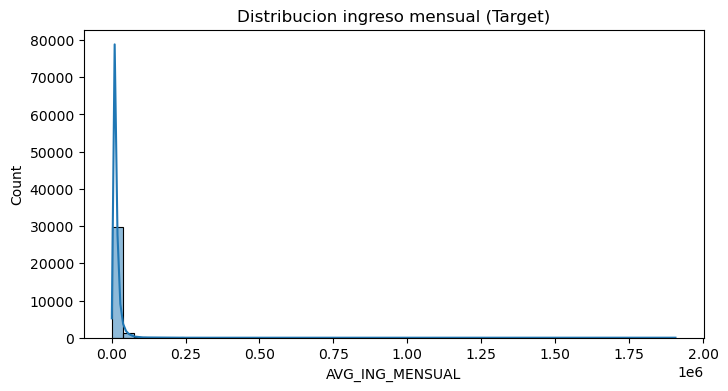

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df_master_final["AVG_ING_MENSUAL"], bins=50, kde=True)
plt.title("Distribucion ingreso mensual (Target)")
plt.show()

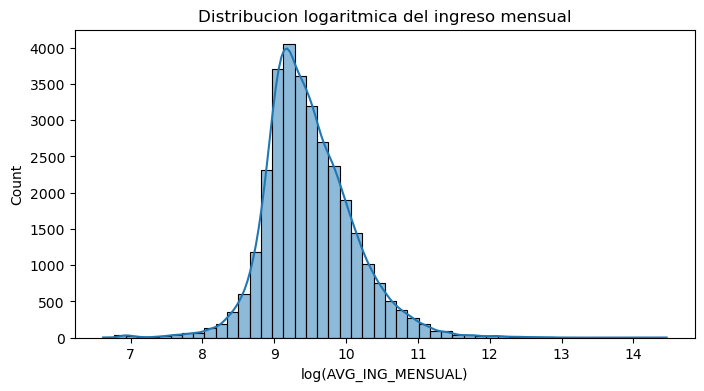

In [97]:
plt.figure(figsize=(8,4))

sns.histplot(
    np.log1p(df_master_final["AVG_ING_MENSUAL"]),
    bins=50,
    kde=True
)

plt.title("Distribucion logaritmica del ingreso mensual")
plt.xlabel("log(AVG_ING_MENSUAL)")
plt.show()

<Axes: xlabel='AVG_ING_MENSUAL', ylabel='Count'>

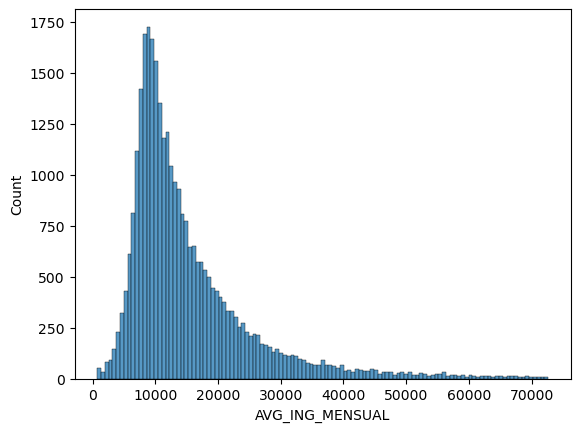

In [98]:
limite = df_master_final["AVG_ING_MENSUAL"].quantile(0.99)

sns.histplot(
    df_master_final[
        df_master_final["AVG_ING_MENSUAL"] <= limite
    ]["AVG_ING_MENSUAL"]
)

La variable objetivo presenta una distribucion altamente asimetrica con cola larga hacia la derecha, caracteristica comun en variables de ingreso. Se identificaron valores extremos considerablemente superiores al comportamiento promedio de la poblacion.

Debido a esta asimetria, se evaluara posteriormente el uso de transformaciones logaritmicas sobre la variable objetivo con el fin de estabilizar la varianza y mejorar el desempeño de los modelos predictivos.

In [99]:
pd.set_option('display.float_format', '{:,.2f}'.format)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


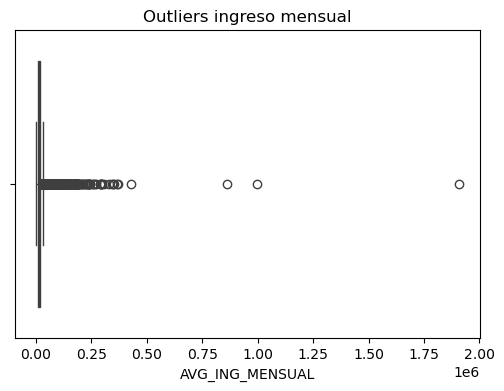

In [100]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_master_final["AVG_ING_MENSUAL"])
plt.title("Outliers ingreso mensual")
plt.show()

In [101]:
df_master_final["AVG_ING_MENSUAL"].describe(
    percentiles=[0.90,0.95,0.99,0.995]
)

count      31,407.00
mean       16,518.83
std        20,605.53
min           745.35
50%        12,216.78
90%        28,735.26
95%        38,765.83
99%        72,850.84
99.5%      96,783.04
max     1,906,696.15
Name: AVG_ING_MENSUAL, dtype: float64

La media es mucho mayor que la mediana, esto quiere decir que los ingresos altos están jalando la media hacia arriba.

Se observa una distribucion sesgada a la derecha, lo cual indica la presencia de clientes con ingresos muy mayores al promedio.
Esto nos sugiere que podria ser necesario aplicar transformaciones como logaritmos en las siguientes etapas.

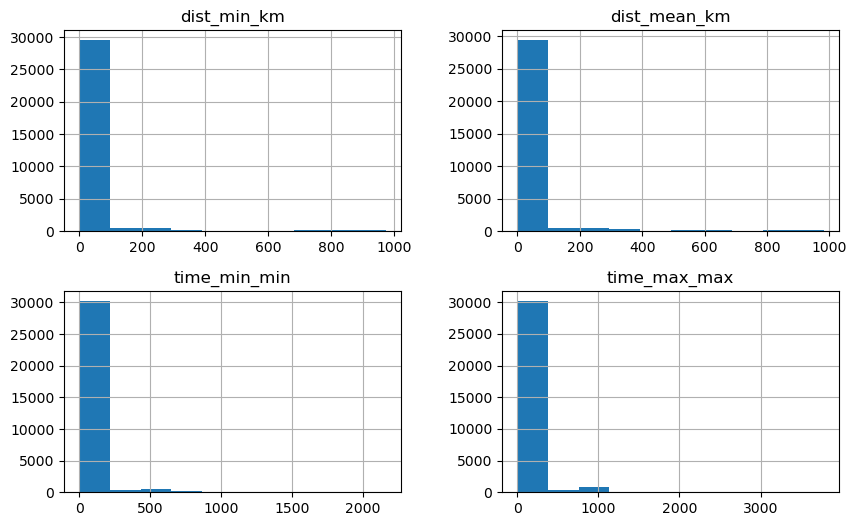

In [102]:
import matplotlib.pyplot as plt
cols = ["dist_min_km", "dist_mean_km", "time_min_min", "time_max_max"]

df_master_final[cols].hist(figsize=(10,6))
plt.show()

Se observa que las variables de distancia y tiempo presentan una distribucion altamente sesgada a la derecha. La mayoria de los clientes se encuentran relativamente cerca de una sucursal bancaria (distancias bajs y tiempos cortos), mientras que existe un grupo reducido de clientes con valores extremadamente altos.

Estos valores extremos pueden deberse a ubicaciones alejadas o a inconsistencias en los datos del scraping.

La presencia de valores extremadamente altos nos habla la existencia de outliers que podrian afectar negativamente el entrenamiento de modelos

Estos valores seran evaluados para determinar si corresponden a casos reales o errores de medicion.

In [103]:
df_master_final[
    df_master_final["dist_max_km"] > 300
]

,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,MEDIANA_ING_MENSUAL,AVG_ING_MENSUAL,FECHA_FIRST_DEPOSITO,MONTH_LAST_DEPOSITO,FECHA_RANGO_IZQ,FECHA_LAST_DEPOSITO_x,NUMERO_CLIENTE,SEXO,ESTADO_CIVIL,FECHA_NACIMIENTO,FECHA_CLIENTE_DESDE,CALLE,COLONIA,CIUDAD,CODIGO_ESTADO,CP,CP_CALCULADO,CLAVE_PAIS,latitude,longitude,score,direccion_sugerida,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode,FECHA_CONS_FINAL,ID_BURO_FINAL,FECHA_LAST_DEPOSITO_y,COUNT_6M,COUNT_9M,COUNT_12M,COUNT_18M,COUNT_24M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,COUNT_FLAG_12M,COUNT_FLAG_18M,COUNT_FLAG_24M,COUNT_FLAG_MAS_24M,MAX_PEOR_MOP_IN_3M,MAX_PEOR_MOP_IN_6M,MAX_PEOR_MOP_IN_9M,MAX_PEOR_MOP_IN_12M,MAX_PEOR_MOP_IN_18M,MAX_PEOR_MOP_IN_24M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO
60,1,7.00,7.44,"36,912.00","47,035.44",2020-07-17,2026-03-01,2025-03-01,2026-03-27,4431475,M,2,1974-06-29,2020-07-07,FLORARES MZA 12 LT 33,15 DE ENERO,LAZARO CARDENAS,MIC,60990,60990,MEX,18.02,-102.21,84.00,"60990, Las Guacamayas, MichoacÃ¡n de Ocampo",284.00,313.00,359.00,810,833.33,1130,"1,116.67",light,2025-08-04 10:40:42,3415969,2026-03-27,3,3,3,6,6,0,0.00,2.00,3.00,0,1,1,1,1,1,5.00,19.00,3.00,0.00,0.00,1,2,2,2,22,1.00,1.00,5.00,5.00,5.00,5.00,"51,175.00",0.00,"530,028.00",152.46,283.00,5.00,4,6
68,1,15.00,17.44,"10,175.86","10,215.66",2015-01-12,2026-03-01,2025-03-01,2026-03-30,1534060,F,1,1981-01-16,2013-04-23,C MARGARITO DAMIAN VARGAS 10,BARR SAN ANTONIO,CHILPANCINGO DE LOS BRAVO,GRO,39069,NaN,MEX,17.55,-99.50,100.00,"Calle Margarito DamiÃ¡n Vargas 10, San Antonio, Chilpancingo De Los Bravo, G...",544.00,566.33,589.00,350,363.33,560,536.67,light,2025-08-01 00:00:00,3414486,2026-03-30,2,3,3,4,5,0,0.00,2.00,2.00,0,0,0,0,0,0,4.00,121.00,87.00,1.00,0.00,8,14,24,27,98,9.00,9.00,9.00,9.00,9.00,9.00,"22,354.00","4,572.00","650,934.00",72.98,234.00,1.00,6,5
108,1,15.00,15.35,"48,576.76","56,264.73",2018-09-14,2026-03-01,2025-03-01,2026-03-30,3170216,M,2,1988-08-02,2018-08-31,2DA C DE SATURNO 103,ENSUE#OS,CUAUTITLAN IZCALLI,MX,54740,NaN,MEX,19.66,-99.22,97.88,"Calle Saturno 103, EnsueÃ±os, CuautitlÃ¡n Izcalli, MÃ©xico, 54740",903.00,933.33,959.00,500,560.00,900,800.00,light,2026-02-27 18:48:33,3568211,2026-03-30,16,19,29,39,50,0,1.00,4.00,6.00,0,1,2,2,2,2,11.00,170.00,160.00,0.00,0.00,12,24,36,47,134,3.00,3.00,3.00,3.00,3.00,3.00,"1,102,083.00",0.00,"3,607,172.00",49.49,169.00,0.00,5,6
156,1,15.00,17.67,"11,916.22","12,377.03",2015-01-19,2026-03-01,2025-03-01,2026-03-30,1222769,M,2,1962-01-31,2011-12-06,C LAZARO CARDENAS SN,LAS PETAQUILLAS,CHILPANCINGO DE LOS BRAVO,GRO,39105,39090,MEX,NaN,NaN,NaN,NaN,214.00,259.67,315.00,710,753.33,1110,"1,080.00",light,2025-06-23 14:17:07,3381927,2026-03-30,4,4,7,13,18,0,0.00,2.00,4.00,0,0,1,2,2,2,2.00,39.00,25.00,0.00,0.00,0,2,4,8,33,1.00,2.00,2.00,2.00,2.00,2.00,"173,221.00",0.00,"750,643.00",104.24,264.00,7.00,5,6
174,1,7.00,6.79,"11,738.60","11,600.81",2020-02-07,2026-03-01,2025-03-01,2026-03-27,4198148,F,1,1981-09-04,2020-02-07,AV PASEO DE LOS BOSQUES 172,BOSQUES DE LA HACIENDA 1A SECCION,CUAUTITLAN IZCALLI,MX,54715,54770,MEX,19.69,-99.22,96.46,"Paseo de los Bosques 172, Bosques de La Hacienda, CuautitlÃ¡n Izcalli, MÃ©xi...",873.00,914.67,955.00,470,556.67,900,790.00,light,2026-03-14 00:00:00,3585929,2026-03-27,2,2,2,3,4,0,0.00,2.00,3.00,0,1,1,1,2,2,5.00,143.00,93.00,2.00,0.00,10,21,30,42,106,9.00,9.00,9.00,9.00,9.00,9.00,"9,642.00","6,520.00","1,092,673.00",60.23,246.00,0.00,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Se identificaron observaciones extremas en variables geograficas y de movilidad, incluyendo distancias y tiempos considerablemente superiores al comportamiento esperado para trayectos urbanos normales.

Estos casos podrian estar asociados a:

-errores de geocodificacion

-coordenadas incorrectas

-inconsistencias en el scraping

-asignaciones atIpicas de sucursales

Por esta razon en etapas posteriores se evaluara la aplicación de reglas de validacion y tratamiento de valores extremos para las variables geograficas.

In [104]:
#INVESTIGAR
df_master_final[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
NUM_EMPRESAS,"31,407.00",1.11,0.46,0.00,1.00,1.00,1.00,4.00
MEDIANA_DAYS_FREQ,"31,378.00",12.73,20.04,0.00,7.00,15.00,15.00,"2,492.00"
AVG_DAYS_FREQ,"31,378.00",14.51,34.86,2.33,7.06,14.09,15.41,"2,492.00"
MEDIANA_ING_MENSUAL,"31,407.00","14,941.38","17,910.82",0.05,"8,439.78","11,328.80","16,916.51","1,873,826.52"
AVG_ING_MENSUAL,"31,407.00","16,518.83","20,605.53",745.35,"8,893.05","12,216.78","18,671.55","1,906,696.15"
NUMERO_CLIENTE,"31,407.00","4,989,113.52","1,958,539.58",37.00,"3,966,344.00","5,892,194.00","6,508,298.00","7,019,780.00"
CP,"31,407.00","57,866.38","17,929.12",0.00,"50,838.50","65,580.00","66,640.00","664,478.00"
latitude,"29,588.00",24.01,3.03,16.47,20.62,25.68,25.79,32.47
longitude,"29,588.00",-100.42,2.22,-114.82,-100.63,-100.30,-100.14,-86.74
score,"29,588.00",95.76,4.40,74.25,94.87,97.66,98.50,100.00


Hallazgos rapidos sin buro:

* La mayoria de clientes recibe nomina de una sola empresa.
* MEDIANA_DAYS_FREQ = 2492 parece sospechoso.
* dist_max_km = 998 km parece sospechoso.
* time_max_max 0 3780 min parece sospechoso.

### Hallazgos completos analisis descriptivo


En las variables relacionadas con nomina se observo que la mayoría de los clientes recibe depositos provenientes de una sola empresa, lo cual resulta consistente con una poblacion predominantemente asalariada. Asimismo la distribucion del ingreso mensual presento una fuerte asimetría positiva, con presencia de valores extremos considerablemente superiores al comportamiento promedio de la poblacion.

En las variables geograficas derivadas de Google Maps se detectaron observaciones atipicas en distancias y tiempos hacia sucursales bancarias, alcanzando valores cercanos a 1,000 kilometros y mas de 3,000 minutos de trayecto. 

Respecto a las variables de buro de credito, se identifico una alta dispersion en variables monetarias como `SUM_MONTO_OTORG`, `SUM_TL_SALDO_ACTUAL` y `SUM_TL_SALDO_VENCIDO`, las cuales presentan valores maximos extremadamente superiores a la mediana poblacional. Este comportamiento sugiere distribuciones altamente sesgadas y posibles clientes con historiales crediticios significativamente mayores al promedio.

Tambien se observaron patrones relevantes en las variables de actividad crediticia, por ejemplo la mayoria de los clientes presenta multiples consultas recientes al buro de credito, así como distintos otorgantes y tipos de credito reflejando una poblacion financieramente activa.

En las variables de comportamiento crediticio se detectaron niveles elevados en indicadores de morosidad (`MAX_PEOR_MOP`), lo cual sugiere que parte de la poblacion presenta antecedentes relevantes de incumplimiento o deterioro crediticio.

Finalmente se identificaron posibles inconsistencias temporales en la variable `MIN_MESES_ENTRE_CUENTAS_APER`, la cual contiene valores negativos, esta variable debera analizarse con mayor detalle en etapas posteriores.

### Deteccion formal de outliers con rango intercuartilico

In [105]:
Q1 = df_master_final["AVG_ING_MENSUAL"].quantile(0.25) #el 25% de clientes gana menos que este valor
Q3 = df_master_final["AVG_ING_MENSUAL"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_master_final[
    (df_master_final["AVG_ING_MENSUAL"] < limite_inferior) |
    (df_master_final["AVG_ING_MENSUAL"] > limite_superior)
]

print("Cantidad de outliers:", len(outliers))

print(
    "Porcentaje:",
    round(len(outliers)/len(df_master_final)*100,2),
    "%"
)

Cantidad de outliers: 2240
Porcentaje: 7.13 %


El metodo IQR identifico aproximadamente un 7.34% de observaciones como valores atipicos. Sin embargo debido a la naturaleza asimetrica de las variables de ingreso, estos valores no necesariamente representan errores, sino posibles clientes con ingresos considerablemente superiores al promedio.

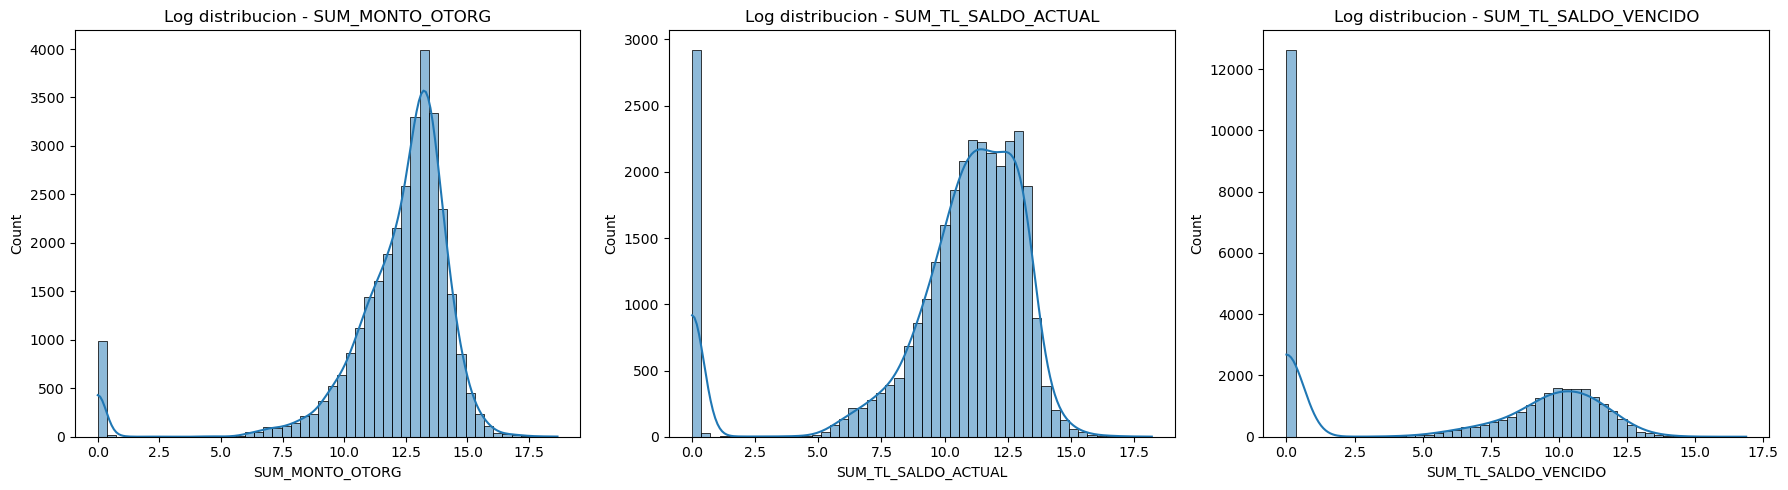

In [106]:
variables_monetarias = [
    "SUM_MONTO_OTORG",
    "SUM_TL_SALDO_ACTUAL",
    "SUM_TL_SALDO_VENCIDO"
]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(variables_monetarias):
    
    sns.histplot(
        np.log1p(df_master_final[col]),
        bins=50,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Log distribucion - {col}")

plt.tight_layout()
plt.show()

# 3. Analisis bivariado y multivariado

Relaciones entre variables, especialmente la variable objetivo (ingreso).

In [111]:
def plot_corr_heatmap(df, cols, title, figsize=(10, 8), annot=True):
    cols_existentes = [col for col in cols if col in df.columns]
    
    corr = df[cols_existentes].corr()
    
    plt.figure(figsize=figsize)
    
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=annot,
        fmt=".2f",
        linewidths=0.5
    )
    
    plt.title(title)
    plt.show()

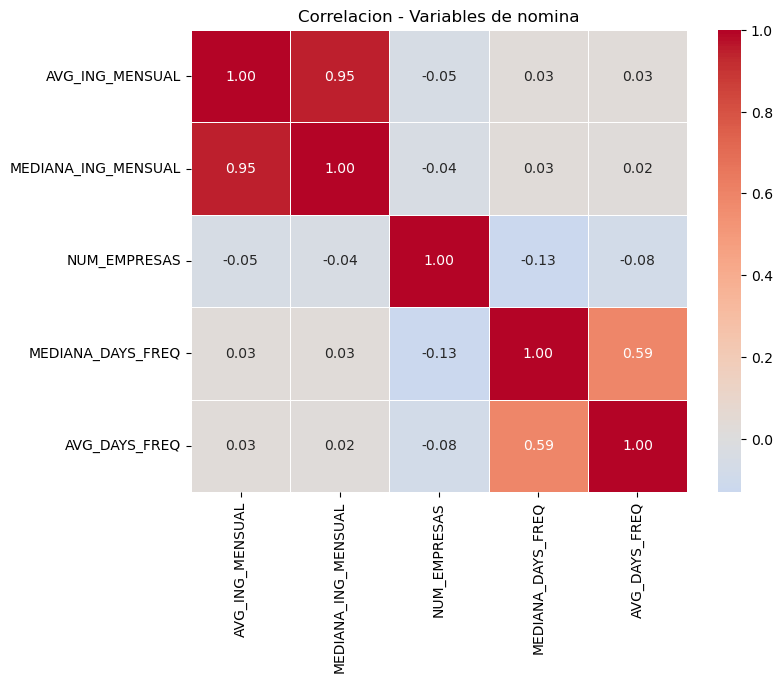

In [112]:
cols_nomina = [
    "AVG_ING_MENSUAL",
    "MEDIANA_ING_MENSUAL",
    "NUM_EMPRESAS",
    "MEDIANA_DAYS_FREQ",
    "AVG_DAYS_FREQ"
]

plot_corr_heatmap(
    df_master_final,
    cols_nomina,
    "Correlacion - Variables de nomina",
    figsize=(8,6)
)

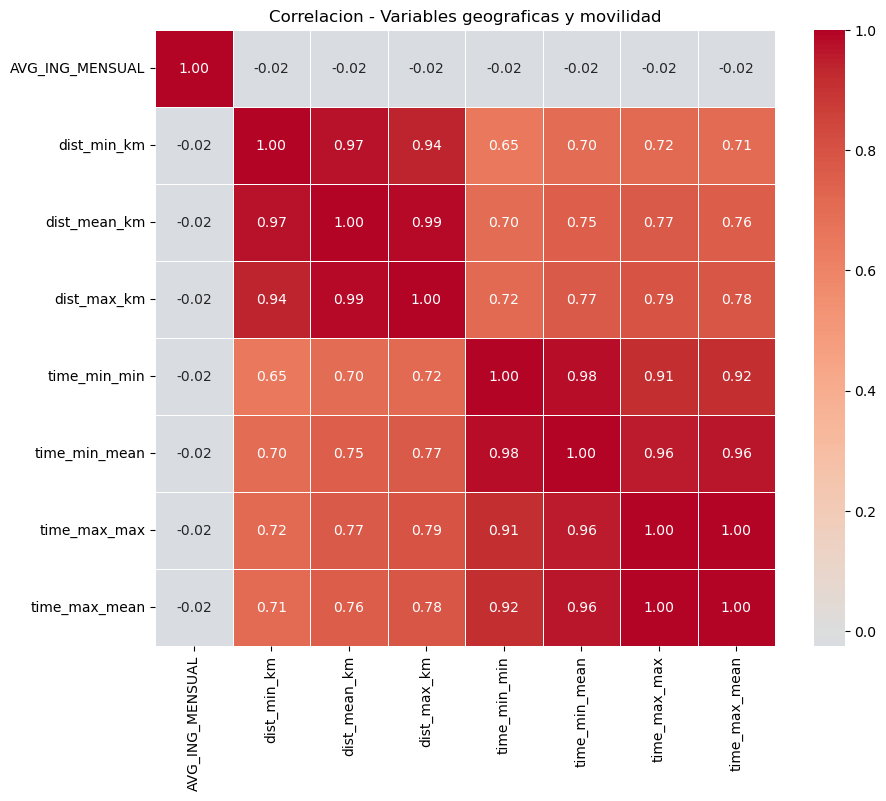

In [113]:
cols_google_maps = [
    "AVG_ING_MENSUAL",
    "dist_min_km",
    "dist_mean_km",
    "dist_max_km",
    "time_min_min",
    "time_min_mean",
    "time_max_max",
    "time_max_mean"
]

plot_corr_heatmap(
    df_master_final,
    cols_google_maps,
    "Correlacion - Variables geograficas y movilidad",
    figsize=(10,8)
)

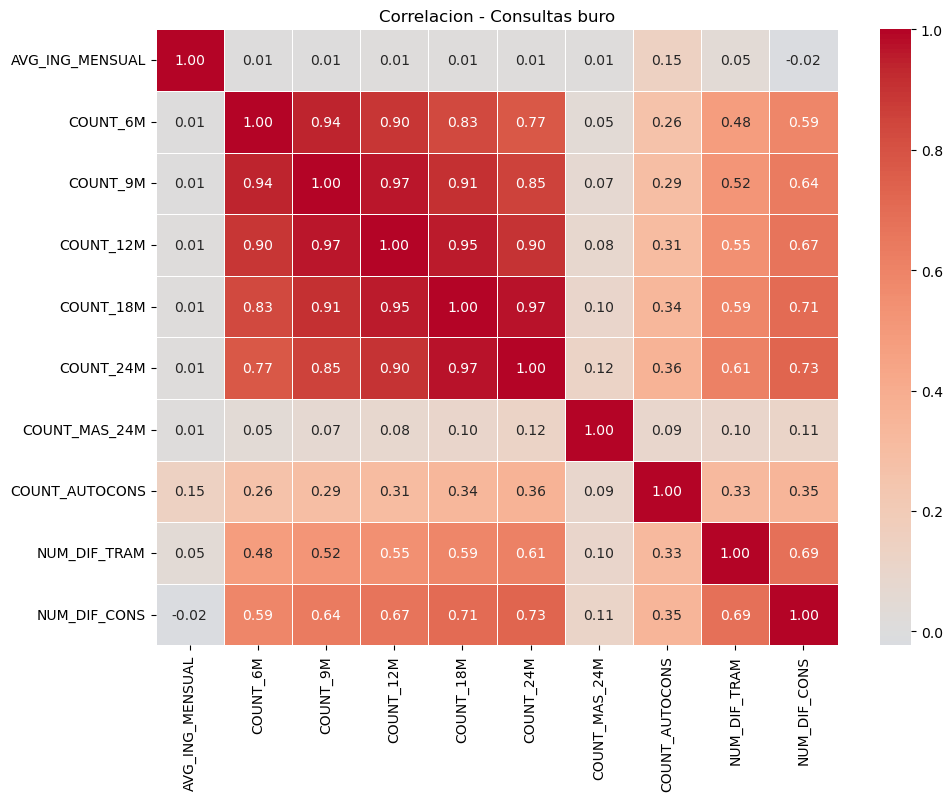

In [114]:
cols_buro_consultas = [
    "AVG_ING_MENSUAL",
    "COUNT_6M",
    "COUNT_9M",
    "COUNT_12M",
    "COUNT_18M",
    "COUNT_24M",
    "COUNT_MAS_24M",
    "COUNT_AUTOCONS",
    "NUM_DIF_TRAM",
    "NUM_DIF_CONS"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_consultas,
    "Correlacion - Consultas buro",
    figsize=(11,8)
)

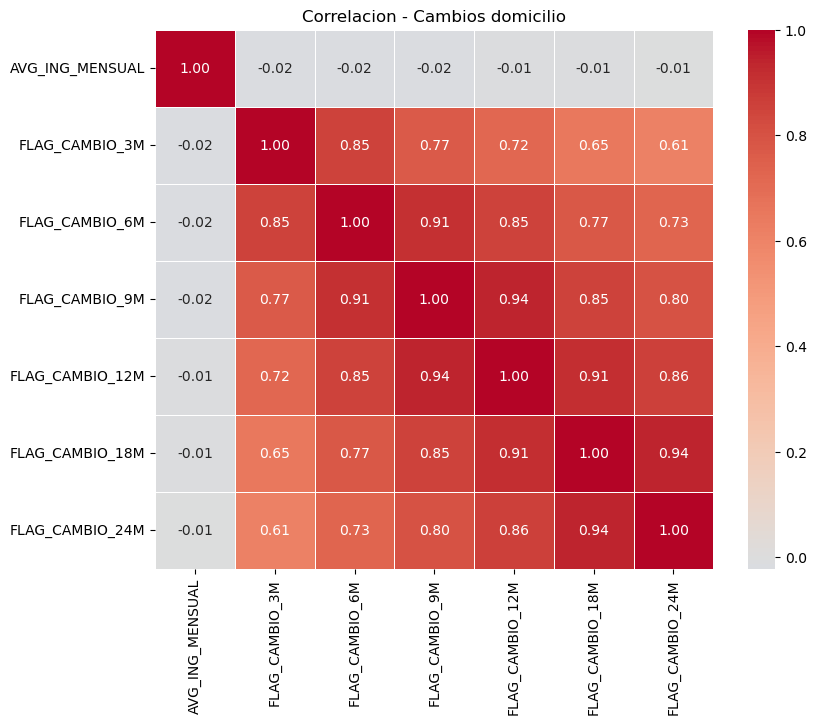

In [115]:
cols_buro_direcciones = [
    "AVG_ING_MENSUAL",
    "FLAG_CAMBIO_3M",
    "FLAG_CAMBIO_6M",
    "FLAG_CAMBIO_9M",
    "FLAG_CAMBIO_12M",
    "FLAG_CAMBIO_18M",
    "FLAG_CAMBIO_24M"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_direcciones,
    "Correlacion - Cambios domicilio",
    figsize=(9,7)
)

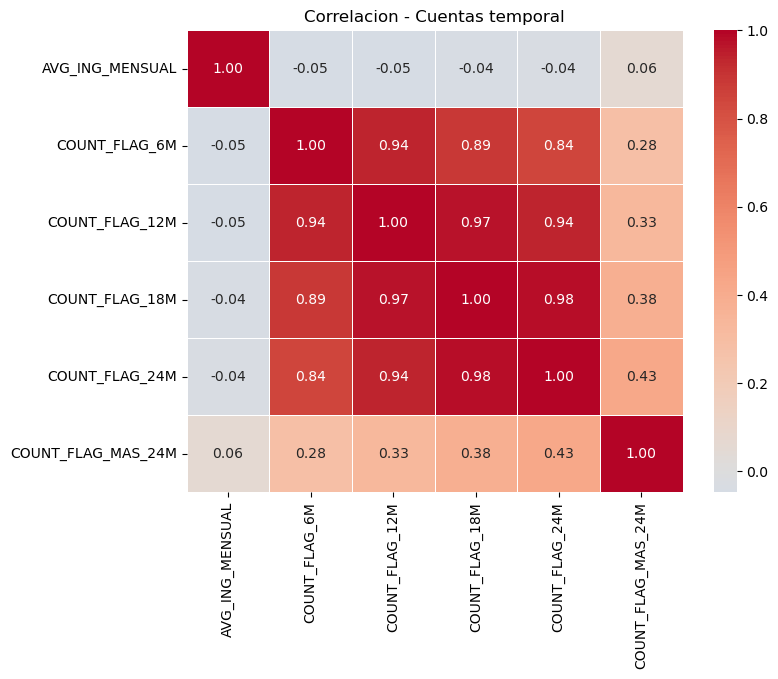

In [116]:
cols_buro_cuentas_tiempo = [
    "AVG_ING_MENSUAL",
    "COUNT_FLAG_6M",
    "COUNT_FLAG_12M",
    "COUNT_FLAG_18M",
    "COUNT_FLAG_24M",
    "COUNT_FLAG_MAS_24M"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_cuentas_tiempo,
    "Correlacion - Cuentas temporal",
    figsize=(8,6)
)

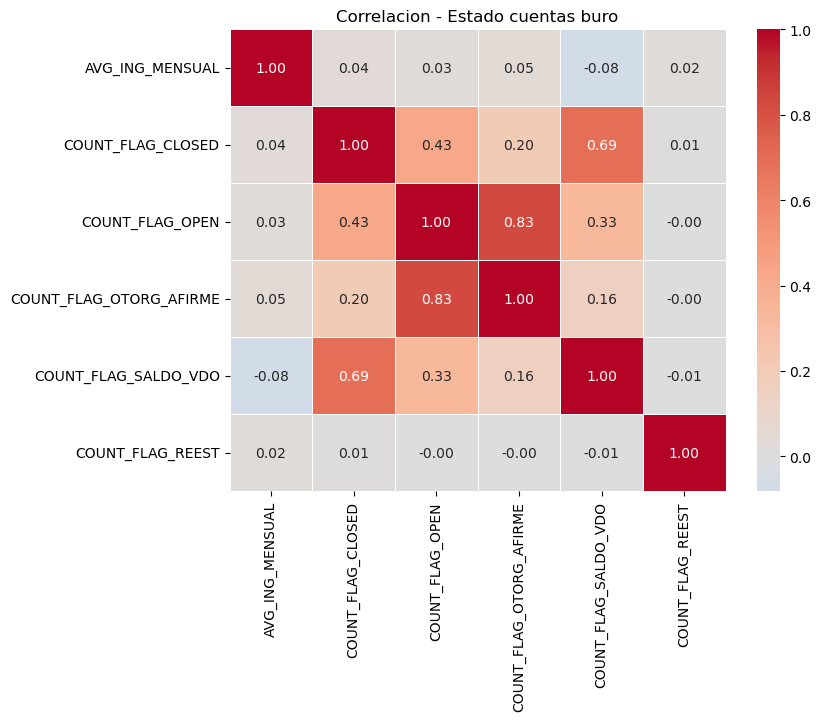

In [117]:
cols_buro_estado_cuentas = [
    "AVG_ING_MENSUAL",
    "COUNT_FLAG_CLOSED",
    "COUNT_FLAG_OPEN",
    "COUNT_FLAG_OTORG_AFIRME",
    "COUNT_FLAG_SALDO_VDO",
    "COUNT_FLAG_REEST"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_estado_cuentas,
    "Correlacion - Estado cuentas buro",
    figsize=(8,6)
)

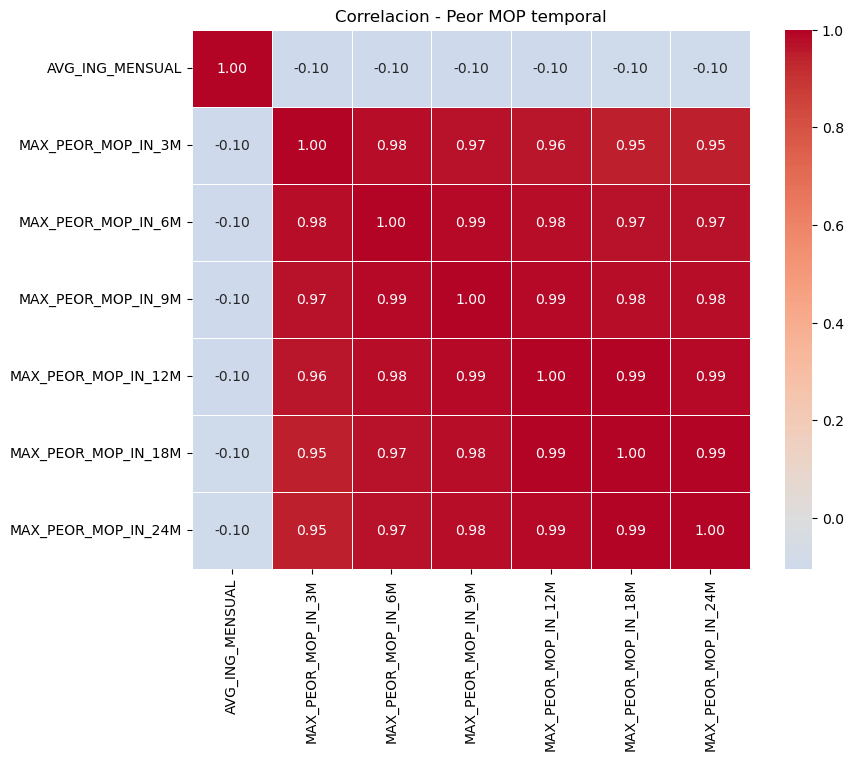

In [118]:
cols_buro_mop = [
    "AVG_ING_MENSUAL",
    "MAX_PEOR_MOP_IN_3M",
    "MAX_PEOR_MOP_IN_6M",
    "MAX_PEOR_MOP_IN_9M",
    "MAX_PEOR_MOP_IN_12M",
    "MAX_PEOR_MOP_IN_18M",
    "MAX_PEOR_MOP_IN_24M"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_mop,
    "Correlacion - Peor MOP temporal",
    figsize=(9,7)
)

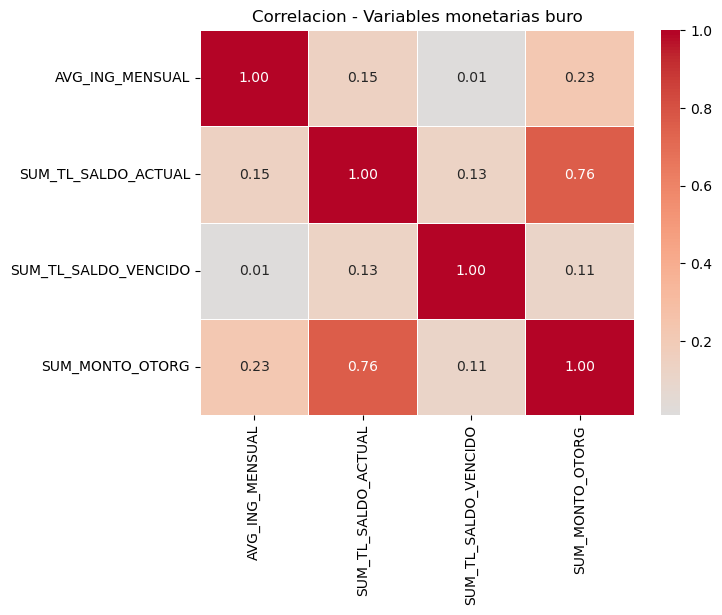

In [119]:
cols_buro_monetarias = [
    "AVG_ING_MENSUAL",
    "SUM_TL_SALDO_ACTUAL",
    "SUM_TL_SALDO_VENCIDO",
    "SUM_MONTO_OTORG"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_monetarias,
    "Correlacion - Variables monetarias buro",
    figsize=(7,5)
)

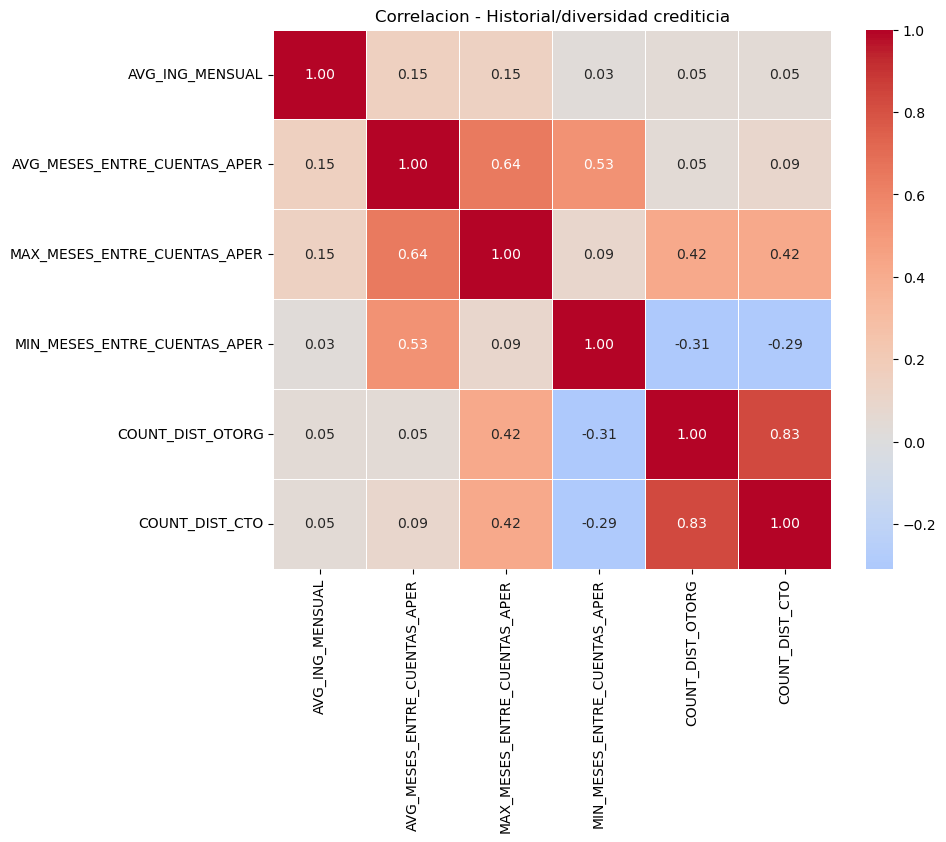

In [120]:
cols_buro_historial = [
    "AVG_ING_MENSUAL",
    "AVG_MESES_ENTRE_CUENTAS_APER",
    "MAX_MESES_ENTRE_CUENTAS_APER",
    "MIN_MESES_ENTRE_CUENTAS_APER",
    "COUNT_DIST_OTORG",
    "COUNT_DIST_CTO"
]

plot_corr_heatmap(
    df_master_final,
    cols_buro_historial,
    "Correlacion - Historial/diversidad crediticia",
    figsize=(9,7)
)

In [121]:
corr = df_master_final[numericas].corr()

corr_target = corr["AVG_ING_MENSUAL"].sort_values(ascending=False)
corr_target

AVG_ING_MENSUAL                 1.00
MEDIANA_ING_MENSUAL             0.95
SUM_MONTO_OTORG                 0.23
AVG_MESES_ENTRE_CUENTAS_APER    0.15
MAX_MESES_ENTRE_CUENTAS_APER    0.15
COUNT_AUTOCONS                  0.15
SUM_TL_SALDO_ACTUAL             0.15
COUNT_FLAG_MAS_24M              0.06
COUNT_DIST_OTORG                0.05
COUNT_FLAG_OTORG_AFIRME         0.05
COUNT_DIST_CTO                  0.05
NUM_DIF_TRAM                    0.05
COUNT_FLAG_CLOSED               0.04
MIN_MESES_ENTRE_CUENTAS_APER    0.03
MEDIANA_DAYS_FREQ               0.03
latitude                        0.03
AVG_DAYS_FREQ                   0.03
COUNT_FLAG_OPEN                 0.03
CP                              0.02
COUNT_FLAG_REEST                0.02
COUNT_24M                       0.01
COUNT_18M                       0.01
COUNT_MAS_24M                   0.01
COUNT_12M                       0.01
SUM_TL_SALDO_VENCIDO            0.01
COUNT_9M                        0.01
COUNT_6M                        0.01
I

<Axes: xlabel='dist_mean_km', ylabel='AVG_ING_MENSUAL'>

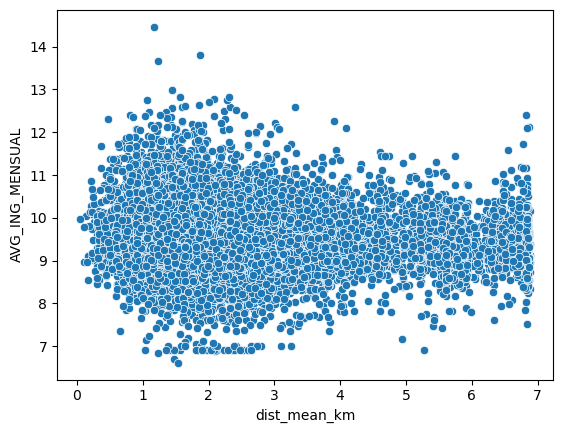

In [122]:
sns.scatterplot(
    x=np.log1p(df_master_final["dist_mean_km"]),
    y=np.log1p(df_master_final["AVG_ING_MENSUAL"])
)

No se observa una relacion lineal clara entre la distancia promedio a la sucursal y el ingreso mensual del cliente.Se identifica una alta dispersión en los ingresos para distancias bajas, lo cual indica que la proximidad a una sucursal no es un algo plenamente determinante del nivel de ingreso.

Tambien se observan valores atipicos con ingresos extremadamente altos en distancias cercanas, lo cual reafirma la presencia de outliers en nuestra variable objetivo.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


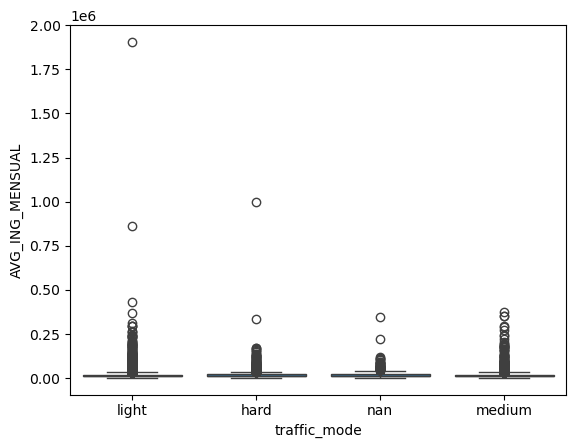

In [123]:
sns.boxplot(
    x="traffic_mode",
    y="AVG_ING_MENSUAL",
    data=df_master_final
)
plt.show()

No se observa una separacion claramente diferenciada entre los niveles de trafico y el ingreso mensual. Sin embargo la variable podraa aportar informacion complementaria en combinacion con otras variables geograficas y sociodemograficas

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


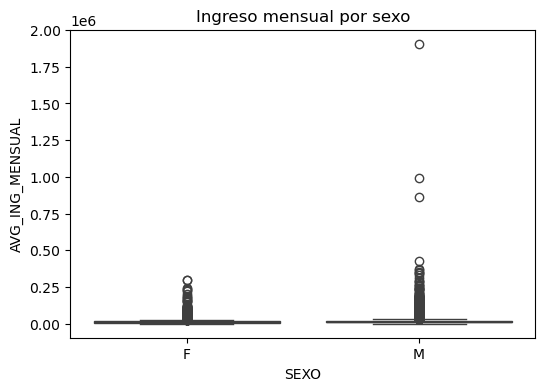

In [124]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="SEXO",
    y="AVG_ING_MENSUAL",
    data=df_master_final
)

plt.title("Ingreso mensual por sexo")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


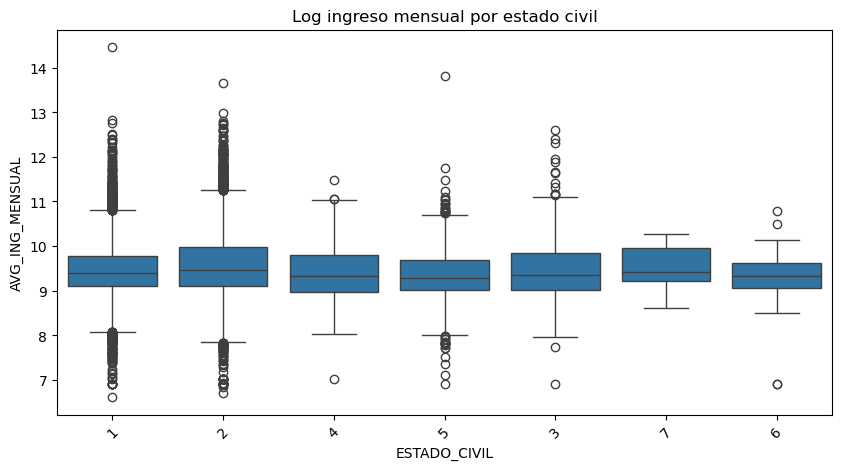

In [125]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="ESTADO_CIVIL",
    y=np.log1p(df_master_final["AVG_ING_MENSUAL"]),
    data=df_master_final
)

plt.title("Log ingreso mensual por estado civil")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='SUM_MONTO_OTORG', ylabel='AVG_ING_MENSUAL'>

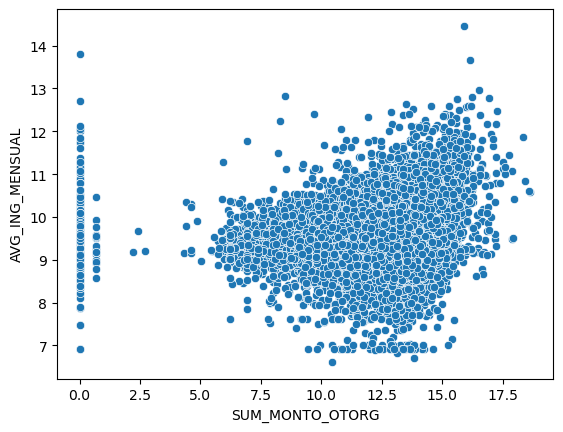

In [126]:
sns.scatterplot(
    x=np.log1p(df_master_final["SUM_MONTO_OTORG"]),
    y=np.log1p(df_master_final["AVG_ING_MENSUAL"])
)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


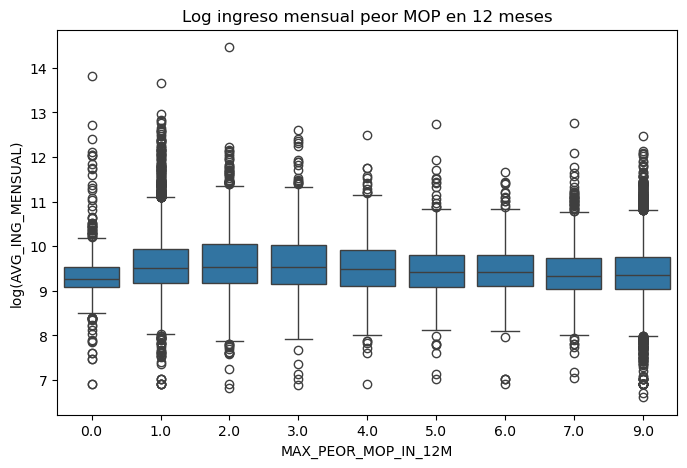

In [127]:
#Morosidad

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_master_final,
    x="MAX_PEOR_MOP_IN_12M",
    y=np.log1p(df_master_final["AVG_ING_MENSUAL"])
)

plt.title("Log ingreso mensual peor MOP en 12 meses")
plt.xlabel("MAX_PEOR_MOP_IN_12M")
plt.ylabel("log(AVG_ING_MENSUAL)")
plt.show()

# 4. Hallazgos y consideraciones para preprocesamiento

Se identifican y justifican transformaciones necesarias antes del modelado

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


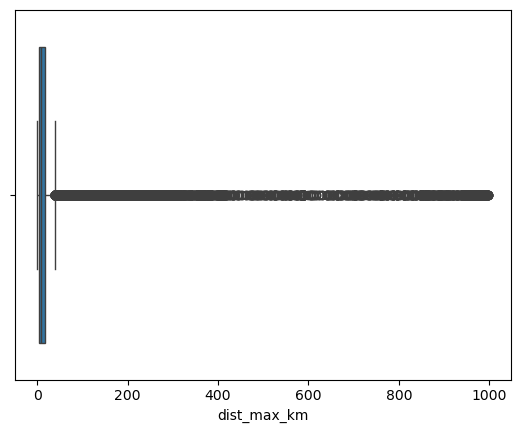

In [128]:
sns.boxplot(x=df_master_final["dist_max_km"])
plt.show()

Se muestra una gran cantidad de valores atipicos en la variable de distancia maxima. La mayoria de los clientes se concentran en rangos bajos de distancia pero existen muchos valores extremos que se extienden hasta casi 1000 km.
Esto nos reafirma la necesidad de aplicar tecnicas de tratamiento de outliers.

In [129]:
for col in categoricas:
    print(col, df_master_final[col].nunique())

SEXO 2
ESTADO_CIVIL 7
CALLE 30601
COLONIA 12691
CIUDAD 516
CODIGO_ESTADO 28
CP_CALCULADO 3827
CLAVE_PAIS 13
direccion_sugerida 27660
traffic_mode 4


Se identifican variables categoricas con alta cardinalidad, especialmente las relacionadas con direcciones.
Estas variables no son adecuadas para ser utilizadas directamente en modelos ya que generarian un numero excesivo de categorias.

### **Feature Engineering Global (Antes del split)**

## 5. Definicion de variables

Antes de iniciar la etapa de ingeniería de caracteristicas, se realizo un analisis conceptual y operativo de las variables disponibles en el dataset `df_master_final`.

El objetivo de esta etapa es identificar:

- variables validas para el modelado
- posibles riesgos de data leakage
- variables redundantes o altamente correlacionadas
- variables con alta cardinalidad
- variables que requieren transformaciones
- variables que requieren tratamiento especial debido a valores extremos o datos faltantes.

Esta etapa nos ayudara a construir un conjunto de variables consistente con el escenario real del negocio y alineado con la metodologia CRISP-ML.

#### 5.2 Tabla maestra de decisiones de variables

En esta seccion se construye una tabla maestra para documentar el tratamiento propuesto para cada variable del dataset. Esta tabla resume el dominio de negocio, la accion recomendada y la justificacion de negocio.

La tabla sera utilizada como guia para la etapa de ingenieríia de caracteristicas permitiendo identificar variables a eliminar, transformar, conservar o utilizar para crear nuevas caracteristicas.

In [130]:
tabla_variables = pd.DataFrame({
    "Variable": df_master_final.columns,
    "Tipo_Dato": df_master_final.dtypes.astype(str)
})

tabla_variables["Dominio"] = "Sin clasificar"
tabla_variables["Accion"] = "Pendiente"
tabla_variables["Justificacion"] = "Pendiente de evaluar"

In [131]:
dominios = {
    "Nomina": [
        "NUM_EMPRESAS",
        "MEDIANA_DAYS_FREQ",
        "AVG_DAYS_FREQ",
        "MEDIANA_ING_MENSUAL",
        "AVG_ING_MENSUAL",
        "FECHA_FIRST_DEPOSITO",
        "MONTH_LAST_DEPOSITO",
        "FECHA_RANGO_IZQ",
        "FECHA_LAST_DEPOSITO_x",
        "FECHA_LAST_DEPOSITO_y"
    ],

    "Sociodemografico": [
        "SEXO",
        "ESTADO_CIVIL",
        "FECHA_NACIMIENTO",
        "FECHA_CLIENTE_DESDE"
    ],

    "Geografico": [
        "CALLE",
        "COLONIA",
        "CIUDAD",
        "CODIGO_ESTADO",
        "CP",
        "CP_CALCULADO",
        "CLAVE_PAIS",
        "latitude",
        "longitude",
        "score",
        "direccion_sugerida"
    ],

    "Movilidad": [
        "dist_min_km",
        "dist_mean_km",
        "dist_max_km",
        "time_min_min",
        "time_min_mean",
        "time_max_max",
        "time_max_mean",
        "traffic_mode"
    ],

    "Buro": [
        "FECHA_CONS_FINAL",
        "ID_BURO_FINAL",
        "COUNT_6M",
        "COUNT_9M",
        "COUNT_12M",
        "COUNT_18M",
        "COUNT_24M",
        "COUNT_MAS_24M",
        "COUNT_AUTOCONS",
        "NUM_DIF_TRAM",
        "NUM_DIF_CONS",
        "FLAG_CAMBIO_3M",
        "FLAG_CAMBIO_6M",
        "FLAG_CAMBIO_9M",
        "FLAG_CAMBIO_12M",
        "FLAG_CAMBIO_18M",
        "FLAG_CAMBIO_24M",
        "COUNT_FLAG_CLOSED",
        "COUNT_FLAG_OPEN",
        "COUNT_FLAG_OTORG_AFIRME",
        "COUNT_FLAG_SALDO_VDO",
        "COUNT_FLAG_REEST",
        "COUNT_FLAG_6M",
        "COUNT_FLAG_12M",
        "COUNT_FLAG_18M",
        "COUNT_FLAG_24M",
        "COUNT_FLAG_MAS_24M",
        "MAX_PEOR_MOP_IN_3M",
        "MAX_PEOR_MOP_IN_6M",
        "MAX_PEOR_MOP_IN_9M",
        "MAX_PEOR_MOP_IN_12M",
        "MAX_PEOR_MOP_IN_18M",
        "MAX_PEOR_MOP_IN_24M",
        "SUM_TL_SALDO_ACTUAL",
        "SUM_TL_SALDO_VENCIDO",
        "SUM_MONTO_OTORG",
        "AVG_MESES_ENTRE_CUENTAS_APER",
        "MAX_MESES_ENTRE_CUENTAS_APER",
        "MIN_MESES_ENTRE_CUENTAS_APER",
        "COUNT_DIST_OTORG",
        "COUNT_DIST_CTO"
    ],

    "ID": [
        "NUMERO_CLIENTE"
    ]
}

In [132]:
for dominio, variables in dominios.items():
    tabla_variables.loc[
        tabla_variables["Variable"].isin(variables),
        "Dominio"
    ] = dominio

In [133]:
pd.set_option('display.max_rows', None)

In [134]:
decisiones = {
    # TARGET,LEAKAGE,IDS

    "AVG_ING_MENSUAL": (
        "Target",
        "Variable objetivo del modelo. Se conservara para modelado se evaluara transformacion log por su fuerte asimetria positiva"
    ),

    "MEDIANA_ING_MENSUAL": (
        "Eliminar",
        "Alta correlacion con el target (aprox. 0.95). Se considera posible data leakage."
    ),

    "NUMERO_CLIENTE": (
        "Eliminar",
        "Identificador unico del cliente. No aporta valor predictivo."
    ),

    "ID_BURO_FINAL": (
        "Eliminar",
        "Identificador tecnico de buro. No aporta valor predictivo."
    ),


    #NOMINA

    "NUM_EMPRESAS": (
        "Conservar",
        "Puede aportar informacion sobre estabilidad laboral o multiples fuentes de ingreso"
    ),

    "MEDIANA_DAYS_FREQ": (
        "Conservar",
        "Representa frecuencia mediana de depositos. Puede capturar regularidad de ingreso"
    ),

    "AVG_DAYS_FREQ": (
        "Conservar",
        "Representa frecuencia promedio de depositos. Se evaluara junto con MEDIANA_DAYS_FREQ por correlacion moderada"
    ),

    "FECHA_FIRST_DEPOSITO": (
        "Transformar",
        "Se usara para crear variables de antiguedad de nomina. La fecha cruda no se usara directamente"
    ),

    "MONTH_LAST_DEPOSITO": (
        "Transformar",
        "Se usara para crear variables del ultimo deposito. La fecha cruda no se usara directamente"
    ),

    "FECHA_RANGO_IZQ": (
        "Evaluar",
        "Variable temporal de origen de nomina. Se revisara si aporta informacion adicional o si es redundante con otras fechas"
    ),

    "FECHA_LAST_DEPOSITO_x": (
        "Transformar",
        "Representa el ultimo deposito historico disponible en la base, puede contener informacion posterior a la fecha de consulta de buro. Requiere validacion adicional"
    ),

    "FECHA_LAST_DEPOSITO_y": (
        "Eliminar",
        "Duplicado exacto de FECHA_LAST_DEPOSITO_x generado durante la union de bases"
    ),


    #SOCIODEMOGRAFICO

    "SEXO": (
        "Conservar",
        "Variable sociodemografica. Se codificara en pipelin"
    ),

    "ESTADO_CIVIL": (
        "Conservar",
        "Variable sociodemografica con cardinalidad baja. Se codificara en pipeline"
    ),

    "FECHA_NACIMIENTO": (
        "Transformar",
        "Se usara para construir EDAD. La fecha cruda no se usara directamente"
    ),

    "FECHA_CLIENTE_DESDE": (
        "Transformar",
        "Se usara para construir antiguedad como cliente del banco. La fecha cruda no se usara directamente"
    ),


    #GEOGRAFICO

    "CALLE": (
        "Eliminar",
        "Alta cardinalidad: 23,546 valores unicos. Se comporta casi como identificador, no generaliza bien"
    ),

    "COLONIA": (
        "Eliminar",
        "Alta cardinalidad: 10,173 valores unicos. Puede contener informacion geografica, como texto crudo genera alta dimensionalidad y ruido"
    ),

    "CIUDAD": (
        "Conservar",
        "Cardinalidad media: 425 valores unicos. Puede capturar diferencias regionales relevantes para ingreso"
    ),

    "CODIGO_ESTADO": (
        "Conservar",
        "Cardinalidad manejable: 27 valores. Puede aportar informacion regional que puede ser interpretable"
    ),

    "CP": (
        "Transformar",
        "Codigo postal reportado. Alta granularidad geografica, podria usarse como categoria agrupada o derivar prefijos"
    ),

    "CP_CALCULADO": (
        "Transformar",
        "Codigo postal calculado con 13.14% de faltantes y 3,183 valores unicos. Puede aportar pero requiere tratamiento de missing y agrupacion"
    ),

    "CLAVE_PAIS": (
        "Evaluar",
        "Cardinalidad baja: 10 valores. Se revisara su distribucion, podria ser constante o poco informativa"
    ),

    "latitude": (
        "Conservar",
        "Variable geografica numerica. Tiene 10.87% de faltantes por problemas de geocodificacion"
    ),

    "longitude": (
        "Conservar",
        "Variable geografica numerica. Tiene 10.87% de faltantes por problemas de geocodificacion"
    ),

    "score": (
        "Conservar",
        "Calidad de geocodificacion. Tiene 10.87% de faltantes y puede ayudar a identificar confiabilidad de coordenadas"
    ),

    "direccion_sugerida": (
        "Eliminar",
        "Alta cardinalidad: 19,963 valores unicos. Poco adecuado para modelos modelos"
    ),

    #MOVILIDAD

    "dist_min_km": (
        "Transformar",
        "Variable de distancia con outliers extremos,maximo observado aprox. 974 km. Requiere  imputacion y posible log"
    ),

    "dist_mean_km": (
        "Evaluar",
        "Alta correlacion con otras variables de distancia. Se evaluara si conservarla o sustituirla por una variable resumen"
    ),

    "dist_max_km": (
        "Evaluar",
        "Variable con outliers extremos, maximo observado aprox 998 km, menos estable que la distancia minima"
    ),

    "time_min_min": (
        "Transformar",
        "Variable de tiempo con outliers extremos, maximo observado aprox 2,160 minutos. Requiere y posible log"
    ),

    "time_min_mean": (
        "Evaluar",
        "Alta correlacion con otras variables de tiempo. Se evaluara redundancia"
    ),

    "time_max_max": (
        "Evaluar",
        "Variable con outliers extremos, maximo observado aprox 3,780 minutos, errores de scraping"
    ),

    "time_max_mean": (
        "Evaluar",
        "Alta correlacion con time_min_mean y time_max_max. Se evaluara redundancia"
    ),

    "traffic_mode": (
        "Conservar",
        "Variable categorica de baja cardinalidad: 4 valores. Puede capturar condicion general de movilidad"
    ),



    #BURO,CONSULTAS

    "FECHA_CONS_FINAL": (
        "Transformar",
        "Fecha de consulta de Buro. Se puede usar para crear mes, año o variables temporales"
    ),

    "COUNT_6M": (
        "Evaluar",
        "Variable de consultas recientes. Baja correlacion individual con el ingreso pero pudiera aportar comportamiento crediticio"
    ),

    "COUNT_9M": (
        "Evaluar",
        "Alta correlacion con otras ventanas de consultas. Se evaluara redundancia"
    ),

    "COUNT_12M": (
        "Evaluar",
        "Alta correlacion con otras ventanas de consultas. Puede usarse como ventana intermedia representativa"
    ),

    "COUNT_18M": (
        "Evaluar",
        "Alta correlacion con COUNT_24M. Se evaluara redundancia"
    ),

    "COUNT_24M": (
        "Evaluar",
        "Variable historica de consultas. Puede usarse para construir ratios de consultas recientes vs historicas"
    ),

    "COUNT_MAS_24M": (
        "Conservar",
        "Captura consultas con antiguedad mayor a 24 meses; baja redundancia con ventanas recientes"
    ),

    "COUNT_AUTOCONS": (
        "Conservar",
        "Tiene correlacion positiva con el ingreso ( aporx 0.15). Puede capturar actividad o monitoreo crediticio"
    ),

    "NUM_DIF_TRAM": (
        "Conservar",
        "Representa diversidad de tramites. Puede aportar informacion de comportamiento crediticio"
    ),

    "NUM_DIF_CONS": (
        "Conservar",
        "Representa diversidad de consultas. Su correlacion con el target es baja, puede aportar algo complementario"
    ),

    # BURO, CAMBIO DOMICILIO

    "FLAG_CAMBIO_3M": (
        "Evaluar",
        "Baja correlacion con el target y alta correlacion con otras ventanas. Se recevaluara resumir en una variable agregada"
    ),

    "FLAG_CAMBIO_6M": (
        "Evaluar",
        "Alta redundancia con otros flags de cambio de domicilio"
    ),

    "FLAG_CAMBIO_9M": (
        "Evaluar",
        "Alta redundancia con otros flags de cambio de domicilio"
    ),

    "FLAG_CAMBIO_12M": (
        "Evaluar",
        "Alta redundancia con otros flags de cambio de domicilio"
    ),

    "FLAG_CAMBIO_18M": (
        "Evaluar",
        "Alta redundancia con otros flags de cambio de domicilio"
    ),

    "FLAG_CAMBIO_24M": (
        "Evaluar",
        "Puede usarse como ventana historica para resumir cambios de domicilio"
    ),


    # BURO, ESTADO CUENTAS

    "COUNT_FLAG_CLOSED": (
        "Conservar",
        "Cuenta cerradas. Puede aportar informacion sobre experiencia crediticia"
    ),

    "COUNT_FLAG_OPEN": (
        "Conservar",
        "Cuentas abiertas. Puede aportar informacion sobre actividad crediticia vigente"
    ),

    "COUNT_FLAG_OTORG_AFIRME": (
        "Evaluar",
        "Alta correlacion con COUNT_FLAG_OPEN (aprox0.84). Se evaluara redundancia"
    ),

    "COUNT_FLAG_SALDO_VDO": (
        "Conservar",
        "Tiene correlacion negativa con ingreso (aprox -0.08). Puede capturar riesgo o deterioro crediticio"
    ),

    "COUNT_FLAG_REEST": (
        "Evaluar",
        "Variable casi constante, se revisara posiblemente con umbral de varianza"
    ),


    # BURO, CUENTAS TEMPORALES

    "COUNT_FLAG_6M": (
        "Evaluar",
        "Alta correlacion con otras ventanas temporales. Se espera resumir o seleccionar una solaventana"
    ),

    "COUNT_FLAG_12M": (
        "Evaluar",
        "Alta correlacion con ventanas 6M, 18M y 24M"
    ),

    "COUNT_FLAG_18M": (
        "Evaluar",
        "Alta correlacion con COUNT_FLAG_24M"
    ),

    "COUNT_FLAG_24M": (
        "Evaluar",
        "Puede representar actividad historica reciente de cuentas"
    ),

    "COUNT_FLAG_MAS_24M": (
        "Conservar",
        "Tiene ligera correlacion positiva con el ingreso (aprox 0.06) y aporta historial mas antiguo"
    ),

    # BURO, MOP


    "MAX_PEOR_MOP_IN_3M": (
        "Evaluar",
        "Correlacion negativa con ingreso (aprox -0.11) pero alta redundancia con otras ventanas MOP"
    ),

    "MAX_PEOR_MOP_IN_6M": (
        "Evaluar",
        "Correlacion negativa con ingreso (aprox -0.11) pero alta redundancia con otras ventanas MOP"
    ),

    "MAX_PEOR_MOP_IN_9M": (
        "Evaluar",
        "Correlacion negativa con ingreso (aprox -0.11) pero alta redundancia con otras ventanas MOP"
    ),

    "MAX_PEOR_MOP_IN_12M": (
        "Conservar",
        "Ventana media representativa. Correlacion negativa con ingreso ( aprox -0.10), facil interpretacion"
    ),

    "MAX_PEOR_MOP_IN_18M": (
        "Evaluar",
        "Alta redundancia con MOP 12M y 24M"
    ),

    "MAX_PEOR_MOP_IN_24M": (
        "Evaluar",
        "Ventana historica amplia. Se evaluara si aporta mas que MOP 12M"
    ),

    # BURO,MONETARIAS


    "SUM_TL_SALDO_ACTUAL": (
        "Transformar",
        "Variable monetaria muy sesgada, maximo observado aprox. 80.7 millones. Requiere log y posible recorte"
    ),

    "SUM_TL_SALDO_VENCIDO": (
        "Transformar",
        "Variable monetaria con muchos ceros y valores extremos, maximo observado aprox 21.1 millones. Requiere log y flag de saldo vencido"
    ),

    "SUM_MONTO_OTORG": (
        "Transformar",
        "Variable monetaria con mayor correlacion con el target despues de MEDIANA_ING_MENSUAL (aprox 0.23). Requiere log por fuerte asimetria"
    ),


    # BURO,HISTORIAL,DIVERSIDAD
 
    "AVG_MESES_ENTRE_CUENTAS_APER": (
        "Conservar",
        "Correlacion positiva con ingreso (aprox 0.16). Puede capturar la madurez del historial crediticio"
    ),

    "MAX_MESES_ENTRE_CUENTAS_APER": (
        "Conservar",
        "Correlacion positiva con ingreso (aprox 0.15). Puede capturar antiguedad maxima del historial crediticio"
    ),

    "MIN_MESES_ENTRE_CUENTAS_APER": (
        "Evaluar",
        "Correlacion baja con ingreso (aprox 0.03) y minimo observado negativo. Requiere revision de calidad"
    ),

    "COUNT_DIST_OTORG": (
        "Evaluar",
        "Mide diversidad de otorgantes. Correlacion baja con target y alta correlacion con COUNT_DIST_CTO ( aprox 0.83)"
    ),

    "COUNT_DIST_CTO": (
        "Evaluar",
        "Numero distinto de tipo de contratos de crédito que ha tenido el cliente. Alta correlacion con COUNT_DIST_OTORG (aprox 0.83)"
    )
}

In [135]:
for variable, (accion, justificacion) in decisiones.items():
    
    tabla_variables.loc[
        tabla_variables["Variable"] == variable,
        ["Accion", "Justificacion"]
    ] = [accion, justificacion]

In [136]:
tabla_variables[tabla_variables["Accion"] == "Pendiente"]

,Variable,Tipo_Dato,Dominio,Accion,Justificacion


In [137]:
tabla_variables

,Variable,Tipo_Dato,Dominio,Accion,Justificacion
NUM_EMPRESAS,NUM_EMPRESAS,int64,Nomina,Conservar,Puede aportar informacion sobre estabilidad laboral o multiples fuentes de i...
MEDIANA_DAYS_FREQ,MEDIANA_DAYS_FREQ,float64,Nomina,Conservar,Representa frecuencia mediana de depositos. Puede capturar regularidad de in...
AVG_DAYS_FREQ,AVG_DAYS_FREQ,float64,Nomina,Conservar,Representa frecuencia promedio de depositos. Se evaluara junto con MEDIANA_D...
MEDIANA_ING_MENSUAL,MEDIANA_ING_MENSUAL,float64,Nomina,Eliminar,Alta correlacion con el target (aprox. 0.95). Se considera posible data leak...
AVG_ING_MENSUAL,AVG_ING_MENSUAL,float64,Nomina,Target,Variable objetivo del modelo. Se conservara para modelado se evaluara transf...
FECHA_FIRST_DEPOSITO,FECHA_FIRST_DEPOSITO,datetime64[ns],Nomina,Transformar,Se usara para crear variables de antiguedad de nomina. La fecha cruda no se ...
MONTH_LAST_DEPOSITO,MONTH_LAST_DEPOSITO,datetime64[ns],Nomina,Transformar,Se usara para crear variables del ultimo deposito. La fecha cruda no se usar...
FECHA_RANGO_IZQ,FECHA_RANGO_IZQ,datetime64[ns],Nomina,Evaluar,Variable temporal de origen de nomina. Se revisara si aporta informacion adi...
FECHA_LAST_DEPOSITO_x,FECHA_LAST_DEPOSITO_x,datetime64[ns],Nomina,Transformar,"Representa el ultimo deposito historico disponible en la base, puede contene..."
NUMERO_CLIENTE,NUMERO_CLIENTE,int64,ID,Eliminar,Identificador unico del cliente. No aporta valor predictivo.


In [138]:
tabla_variables.to_csv(
    "tabla_maestra_variables.csv",
    index=False
)

In [139]:
tabla_variables["Accion"].value_counts()

Accion
Evaluar        32
Conservar      22
Transformar    13
Eliminar        7
Target          1
Name: count, dtype: int64

In [140]:
tabla_variables["Dominio"].value_counts()

Dominio
Buro                41
Geografico          11
Nomina              10
Movilidad            8
Sociodemografico     4
ID                   1
Name: count, dtype: int64

In [141]:
for accion in tabla_variables["Accion"].unique():
    print("\n" + "="*50)
    print(f"ACCION: {accion}")
    print("="*80)
    display(tabla_variables[tabla_variables["Accion"] == accion][
        ["Variable", "Dominio", "Tipo_Dato", "Justificacion"]])


ACCION: Conservar


,Variable,Dominio,Tipo_Dato,Justificacion
NUM_EMPRESAS,NUM_EMPRESAS,Nomina,int64,Puede aportar informacion sobre estabilidad laboral o multiples fuentes de i...
MEDIANA_DAYS_FREQ,MEDIANA_DAYS_FREQ,Nomina,float64,Representa frecuencia mediana de depositos. Puede capturar regularidad de in...
AVG_DAYS_FREQ,AVG_DAYS_FREQ,Nomina,float64,Representa frecuencia promedio de depositos. Se evaluara junto con MEDIANA_D...
SEXO,SEXO,Sociodemografico,object,Variable sociodemografica. Se codificara en pipelin
ESTADO_CIVIL,ESTADO_CIVIL,Sociodemografico,object,Variable sociodemografica con cardinalidad baja. Se codificara en pipeline
CIUDAD,CIUDAD,Geografico,object,Cardinalidad media: 425 valores unicos. Puede capturar diferencias regionale...
CODIGO_ESTADO,CODIGO_ESTADO,Geografico,object,Cardinalidad manejable: 27 valores. Puede aportar informacion regional que p...
latitude,latitude,Geografico,float64,Variable geografica numerica. Tiene 10.87% de faltantes por problemas de geo...
longitude,longitude,Geografico,float64,Variable geografica numerica. Tiene 10.87% de faltantes por problemas de geo...
score,score,Geografico,float64,Calidad de geocodificacion. Tiene 10.87% de faltantes y puede ayudar a ident...



ACCION: Eliminar


,Variable,Dominio,Tipo_Dato,Justificacion
MEDIANA_ING_MENSUAL,MEDIANA_ING_MENSUAL,Nomina,float64,Alta correlacion con el target (aprox. 0.95). Se considera posible data leak...
NUMERO_CLIENTE,NUMERO_CLIENTE,ID,int64,Identificador unico del cliente. No aporta valor predictivo.
CALLE,CALLE,Geografico,object,"Alta cardinalidad: 23,546 valores unicos. Se comporta casi como identificado..."
COLONIA,COLONIA,Geografico,object,"Alta cardinalidad: 10,173 valores unicos. Puede contener informacion geograf..."
direccion_sugerida,direccion_sugerida,Geografico,object,"Alta cardinalidad: 19,963 valores unicos. Poco adecuado para modelos modelos"
ID_BURO_FINAL,ID_BURO_FINAL,Buro,int64,Identificador tecnico de buro. No aporta valor predictivo.
FECHA_LAST_DEPOSITO_y,FECHA_LAST_DEPOSITO_y,Nomina,datetime64[ns],Duplicado exacto de FECHA_LAST_DEPOSITO_x generado durante la union de bases



ACCION: Target


,Variable,Dominio,Tipo_Dato,Justificacion
AVG_ING_MENSUAL,AVG_ING_MENSUAL,Nomina,float64,Variable objetivo del modelo. Se conservara para modelado se evaluara transf...



ACCION: Transformar


,Variable,Dominio,Tipo_Dato,Justificacion
FECHA_FIRST_DEPOSITO,FECHA_FIRST_DEPOSITO,Nomina,datetime64[ns],Se usara para crear variables de antiguedad de nomina. La fecha cruda no se ...
MONTH_LAST_DEPOSITO,MONTH_LAST_DEPOSITO,Nomina,datetime64[ns],Se usara para crear variables del ultimo deposito. La fecha cruda no se usar...
FECHA_LAST_DEPOSITO_x,FECHA_LAST_DEPOSITO_x,Nomina,datetime64[ns],"Representa el ultimo deposito historico disponible en la base, puede contene..."
FECHA_NACIMIENTO,FECHA_NACIMIENTO,Sociodemografico,datetime64[ns],Se usara para construir EDAD. La fecha cruda no se usara directamente
FECHA_CLIENTE_DESDE,FECHA_CLIENTE_DESDE,Sociodemografico,datetime64[ns],Se usara para construir antiguedad como cliente del banco. La fecha cruda no...
CP,CP,Geografico,Int64,"Codigo postal reportado. Alta granularidad geografica, podria usarse como ca..."
CP_CALCULADO,CP_CALCULADO,Geografico,object,"Codigo postal calculado con 13.14% de faltantes y 3,183 valores unicos. Pued..."
dist_min_km,dist_min_km,Movilidad,float64,"Variable de distancia con outliers extremos,maximo observado aprox. 974 km. ..."
time_min_min,time_min_min,Movilidad,int64,"Variable de tiempo con outliers extremos, maximo observado aprox 2,160 minut..."
FECHA_CONS_FINAL,FECHA_CONS_FINAL,Buro,datetime64[ns],"Fecha de consulta de Buro. Se puede usar para crear mes, año o variables tem..."



ACCION: Evaluar


,Variable,Dominio,Tipo_Dato,Justificacion
FECHA_RANGO_IZQ,FECHA_RANGO_IZQ,Nomina,datetime64[ns],Variable temporal de origen de nomina. Se revisara si aporta informacion adi...
CLAVE_PAIS,CLAVE_PAIS,Geografico,object,"Cardinalidad baja: 10 valores. Se revisara su distribucion, podria ser const..."
dist_mean_km,dist_mean_km,Movilidad,float64,Alta correlacion con otras variables de distancia. Se evaluara si conservarl...
dist_max_km,dist_max_km,Movilidad,float64,"Variable con outliers extremos, maximo observado aprox 998 km, menos estable..."
time_min_mean,time_min_mean,Movilidad,float64,Alta correlacion con otras variables de tiempo. Se evaluara redundancia
time_max_max,time_max_max,Movilidad,int64,"Variable con outliers extremos, maximo observado aprox 3,780 minutos, errore..."
time_max_mean,time_max_mean,Movilidad,float64,Alta correlacion con time_min_mean y time_max_max. Se evaluara redundancia
COUNT_6M,COUNT_6M,Buro,int64,Variable de consultas recientes. Baja correlacion individual con el ingreso ...
COUNT_9M,COUNT_9M,Buro,int64,Alta correlacion con otras ventanas de consultas. Se evaluara redundancia
COUNT_12M,COUNT_12M,Buro,int64,Alta correlacion con otras ventanas de consultas. Puede usarse como ventana ...


In [143]:
#  para eliminar directamente
cols_eliminar = tabla_variables.loc[
    tabla_variables["Accion"] == "Eliminar",
    "Variable"
].tolist()

#Variables a conservar 
cols_conservar = tabla_variables.loc[
    tabla_variables["Accion"] == "Conservar",
    "Variable"
].tolist()

#Variables que se usaran para crear nuevas columnas
cols_transformar = tabla_variables.loc[
    tabla_variables["Accion"] == "Transformar",
    "Variable"
].tolist()

#Variables que requieren evaluacion , CONSULTA CESAR
cols_evaluar = tabla_variables.loc[
    tabla_variables["Accion"] == "Evaluar",
    "Variable"
].tolist()

#Target
target = "AVG_ING_MENSUAL"

print("Columnas a eliminar:", len(cols_eliminar))
print("Columnas a conservar:", len(cols_conservar))
print("Columnas a transformar:", len(cols_transformar))
print("Columnas a evaluar:", len(cols_evaluar))
print("Target:", target)

Columnas a eliminar: 7
Columnas a conservar: 22
Columnas a transformar: 13
Columnas a evaluar: 32
Target: AVG_ING_MENSUAL


La tabla maestra de decisiones pernos perimete establecer un primer criterio forml para el tratamiento de las variables antes de iniciar la creacion de nuevas caracteristicas.

En esta etapa se identificaron variables que deben eliminarse, duplicados, texto de alta cardinalidad o posible data leakage.Se identificaron variables que deben transformarse, principalmente fechas, variables monetarias, variables geograficas y variables de movilidad con valores extremos.

### 5.3 Feature Engineering global

En esta seccion se construyen nuevas variables a partir de la informacion disponible en `df_master_final`.  
Estas transformaciones se realizan antes de la partición train/validation/test porque no dependen de estadisticas aprendidas del conjunto completo, mas bien de reglas, diferencias entre fechas o relaciones matematicas simples entre variables.

In [229]:
df_fe = df_master_final.copy()

print("Shape original:", df_master_final.shape)
print("Shape copia FE:", df_fe.shape)

Shape original: (31407, 75)
Shape copia FE: (31407, 75)


In [230]:
fecha_referencia = df_fe["FECHA_CONS_FINAL"]

fecha_referencia.head()

0   2025-11-03 00:00:00
1   2025-07-01 00:00:00
2   2026-01-13 08:35:03
3   2025-12-09 15:19:51
4   2025-07-18 00:00:00
Name: FECHA_CONS_FINAL, dtype: datetime64[ns]

Variables temporales

Para construir variables temporales se utiliza `FECHA_CONS_FINAL` como fecha de referencia, ya que representa la fecha en la que el banco consulto el buro del cliente. Esta fecha es coherente con el escenario del modelo pues aproxima el momento en el que se evalua al solicitante.

In [231]:
df_fe["EDAD"] = (
    (fecha_referencia - df_fe["FECHA_NACIMIENTO"]).dt.days / 365 #365.25
)

df_fe["ANTIGUEDAD_CLIENTE_ANIOS"] = (
    (fecha_referencia - df_fe["FECHA_CLIENTE_DESDE"]).dt.days / 365
)

df_fe["ANTIGUEDAD_NOMINA_MESES"] = (
    (df_fe["FECHA_LAST_DEPOSITO_x"] - df_fe["FECHA_FIRST_DEPOSITO"]).dt.days / 30
)


df_fe[[
    "EDAD",
    "ANTIGUEDAD_CLIENTE_ANIOS",
    "ANTIGUEDAD_NOMINA_MESES"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
EDAD,"31,406.00",39.93,12.42,18.02,29.61,38.37,49.04,78.50
ANTIGUEDAD_CLIENTE_ANIOS,"31,407.00",4.59,4.82,-0.04,1.14,2.64,6.28,30.56
ANTIGUEDAD_NOMINA_MESES,"31,407.00",49.99,40.71,0.00,17.20,34.50,76.80,136.87


Se generaron cuatro variables temporales principales:

- `EDAD`: edad aproximada del cliente al momento de la consulta de buro.
- `ANTIGUEDAD_CLIENTE_ANIOS`: tiempo que el solicitante ha sido cliente del banco.
- `ANTIGUEDAD_NOMINA_MESES`: periodo aproximado entre el primer y ultimo deposito observado.


In [232]:
variables_temporales_c = [
    "EDAD",
    "ANTIGUEDAD_CLIENTE_ANIOS",
    "ANTIGUEDAD_NOMINA_MESES"
]

for col in variables_temporales_c:
    negativos = (df_fe[col] < 0).sum()
    print(f"{col}: {negativos} valores negativos")

EDAD: 0 valores negativos
ANTIGUEDAD_CLIENTE_ANIOS: 7 valores negativos
ANTIGUEDAD_NOMINA_MESES: 0 valores negativos


In [233]:
df_fe.loc[
    df_fe["ANTIGUEDAD_CLIENTE_ANIOS"] < 0,
    "ANTIGUEDAD_CLIENTE_ANIOS"
] = np.nan

In [234]:
df_fe["FLAG_GEO_MISSING"] = (
    df_fe[["latitude", "longitude", "score"]].isna().any(axis=1)
).astype(int)

df_fe["FLAG_SCORE_BAJO"] = (
    df_fe["score"] < 90
).astype(int)

df_fe[["FLAG_GEO_MISSING", "FLAG_SCORE_BAJO"]].mean()

FLAG_GEO_MISSING   0.06
FLAG_SCORE_BAJO    0.12
dtype: float64

Durante el EDA se identifico que las variables `latitude`, `longitude`, `score` y `direccion_sugerida` presentan aproximadamente 10.87% de valores faltantes. 
Por este motivo se creo `FLAG_GEO_MISSING`, que identifica clientes con información geografica incompleta. Se creo `FLAG_SCORE_BAJO` que marca registros con score de geocodificacion menor a 90. Estas variables permiten que el modelo distinga entre clientes con información geografica confiable y clientes con datos geograficos potencialmente menos confiables

In [235]:
df_fe["FLAG_DISTANCIA_EXTREMA"] = (
    df_fe["dist_min_km"] > 60
).astype(int)

df_fe["FLAG_TIEMPO_EXTREMO"] = (
    df_fe["time_min_min"] > 120
).astype(int)

df_fe[["FLAG_DISTANCIA_EXTREMA", "FLAG_TIEMPO_EXTREMO"]].mean()

FLAG_DISTANCIA_EXTREMA   0.07
FLAG_TIEMPO_EXTREMO      0.05
dtype: float64

### Variables de calidad de movilidad

El EDA mostro valores extremos en variables de distancia y tiempo hacia sucursal bancaria. Por ejemplo, `dist_min_km` alcanzo valores cercanos a 974 km y `time_min_min` llego a aproximadamente 2,160 minutos

De acuerdo con el negocio, distancias de 60 kms  corresponden a errores de scraping o extraccion de datos. Por esta razon se crearon flags para identificar registros con distancia o tiempo extremo. Estos flags permiten preservar la informacion de que el registro tuvo un problema potencial de calidad incluso si se decide imputar los valores numericos.

In [236]:
df_fe["FLAG_TIENE_SALDO_VENCIDO"] = (
    df_fe["SUM_TL_SALDO_VENCIDO"] > 0
).astype(int)

df_fe["FLAG_TIENE_MONTO_OTORGADO"] = (
    df_fe["SUM_MONTO_OTORG"] > 0
).astype(int)

df_fe["RATIO_SALDO_ACTUAL_MONTO"] = (
    df_fe["SUM_TL_SALDO_ACTUAL"] / (df_fe["SUM_MONTO_OTORG"] + 1)
)

df_fe["RATIO_SALDO_VENCIDO_ACTUAL"] = np.where(
    df_fe["SUM_TL_SALDO_ACTUAL"] > 0,
    df_fe["SUM_TL_SALDO_VENCIDO"] / df_fe["SUM_TL_SALDO_ACTUAL"],
    0
)

df_fe[[
    "FLAG_TIENE_SALDO_VENCIDO",
    "FLAG_TIENE_MONTO_OTORGADO",
    "RATIO_SALDO_ACTUAL_MONTO",
    "RATIO_SALDO_VENCIDO_ACTUAL"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
FLAG_TIENE_SALDO_VENCIDO,"31,407.00",0.60,0.49,0.00,0.00,1.00,1.00,1.00
FLAG_TIENE_MONTO_OTORGADO,"31,407.00",0.97,0.17,0.00,1.00,1.00,1.00,1.00
RATIO_SALDO_ACTUAL_MONTO,"31,407.00",2.08,140.78,0.00,0.09,0.25,0.50,"19,716.00"
RATIO_SALDO_VENCIDO_ACTUAL,"31,407.00",0.65,50.80,0.00,0.00,0.04,0.55,"8,998.00"


Variables financieras derivadas

Se construyeron variables financieras simples a partir de los saldos y montos observados en el buro, estas variables buscan capturar el tamaño absoluto del historial crediticio, tambien la relación entre saldo actual, monto otorgado y saldo vencido.

- `FLAG_TIENE_SALDO_VENCIDO` identifica clientes con algun saldo vencido.
- `FLAG_TIENE_MONTO_OTORGADO` identifica clientes con historial de monto otorgado positivo.
- `RATIO_SALDO_ACTUAL_MONTO` aproxima el porcentaje del monto otorgado que permanece como saldo actual.
- `RATIO_SALDO_VENCIDO_ACTUAL` aproxima que proporcion del saldo actual se encuentra vencida.

Estas variables son interpretables para negocio y pueden ayudar a capturar señales de capacidad financiera y comportamiento crediticio

In [237]:
cols_mop = [
    "MAX_PEOR_MOP_IN_3M",
    "MAX_PEOR_MOP_IN_6M",
    "MAX_PEOR_MOP_IN_9M",
    "MAX_PEOR_MOP_IN_12M",
    "MAX_PEOR_MOP_IN_18M",
    "MAX_PEOR_MOP_IN_24M"
]

df_fe["MOP_MAX_24M"] = df_fe[cols_mop].max(axis=1)

df_fe["FLAG_MOP_MALO"] = (
    df_fe["MOP_MAX_24M"] >= 4
).astype(int)

df_fe[["MOP_MAX_24M", "FLAG_MOP_MALO"]].describe().T

,count,mean,std,min,25%,50%,75%,max
MOP_MAX_24M,"31,407.00",5.59,3.61,0.00,2.00,7.00,9.00,9.00
FLAG_MOP_MALO,"31,407.00",0.60,0.49,0.00,0.00,1.00,1.00,1.00


Las variables `MAX_PEOR_MP_IN_*` mostraron correlaciones muy altas entre si, cercanas a 0.95 0.99. Para reducir redundancia se creo `MOP_MAX_24M`, que resume el peor comportamiento observado en cualquier ventana temporal de hasta 24 meses.

Tambien se creo `FLAG_MOP_MALO`, que identifica clientes con un MOP maximo igual o superior a 4. Esta variable nos ayuda a capturar de forma sencilla la presencia de deterioro crediticio relevante.

In [238]:
df_fe["RATIO_CONSULTAS_6M_24M"] = (
    df_fe["COUNT_6M"] / (df_fe["COUNT_24M"] + 1)
)

df_fe["FLAG_ALTA_BUSQUEDA_CREDITO"] = (
    df_fe["COUNT_6M"] >= 10
).astype(int)

df_fe[[
    "RATIO_CONSULTAS_6M_24M",
    "FLAG_ALTA_BUSQUEDA_CREDITO"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
RATIO_CONSULTAS_6M_24M,"31,407.00",0.35,0.18,0.00,0.21,0.33,0.47,0.98
FLAG_ALTA_BUSQUEDA_CREDITO,"31,407.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00


Las variables de consultas de buro por una ventana temporal presentan alta multicolinealidad debido a esto se construyo `RATIO_CONSULTAS_6M_24M`, que compara la actividad reciente de consultas contra la actividad acumulada en 24 meses.

Tambien se creo `FLAG_ALTA_BUSQUEDA_CREDITO` que identifica clientes con 10 o mas consultas en los ultimos 6 meses. Esta variable busca capturar posibles señales de alta busqueda de credito reciente

In [239]:
print("Tamaño original:", df_master_final.shape)
print("Tamaño con FE global:", df_fe.shape)

nuevas_features = [
    "EDAD",
    "ANTIGUEDAD_CLIENTE_ANIOS",
    "ANTIGUEDAD_NOMINA_MESES",
    "FLAG_GEO_MISSING",
    "FLAG_SCORE_BAJO",
    "FLAG_DISTANCIA_EXTREMA",
    "FLAG_TIEMPO_EXTREMO",
    "FLAG_TIENE_SALDO_VENCIDO",
    "FLAG_TIENE_MONTO_OTORGADO",
    "RATIO_SALDO_ACTUAL_MONTO",
    "RATIO_SALDO_VENCIDO_ACTUAL",
    "MOP_MAX_24M",
    "FLAG_MOP_MALO",
    "RATIO_CONSULTAS_6M_24M",
    "FLAG_ALTA_BUSQUEDA_CREDITO"
]

df_fe[nuevas_features].describe().T

Tamaño original: (31407, 75)
Tamaño con FE global: (31407, 90)


,count,mean,std,min,25%,50%,75%,max
EDAD,"31,406.00",39.93,12.42,18.02,29.61,38.37,49.04,78.50
ANTIGUEDAD_CLIENTE_ANIOS,"31,400.00",4.59,4.82,0.00,1.14,2.64,6.28,30.56
ANTIGUEDAD_NOMINA_MESES,"31,407.00",49.99,40.71,0.00,17.20,34.50,76.80,136.87
FLAG_GEO_MISSING,"31,407.00",0.06,0.23,0.00,0.00,0.00,0.00,1.00
FLAG_SCORE_BAJO,"31,407.00",0.12,0.33,0.00,0.00,0.00,0.00,1.00
FLAG_DISTANCIA_EXTREMA,"31,407.00",0.07,0.26,0.00,0.00,0.00,0.00,1.00
FLAG_TIEMPO_EXTREMO,"31,407.00",0.05,0.22,0.00,0.00,0.00,0.00,1.00
FLAG_TIENE_SALDO_VENCIDO,"31,407.00",0.60,0.49,0.00,0.00,1.00,1.00,1.00
FLAG_TIENE_MONTO_OTORGADO,"31,407.00",0.97,0.17,0.00,1.00,1.00,1.00,1.00
RATIO_SALDO_ACTUAL_MONTO,"31,407.00",2.08,140.78,0.00,0.09,0.25,0.50,"19,716.00"


In [240]:
df_fe[[
    "RATIO_SALDO_ACTUAL_MONTO",
    "RATIO_SALDO_VENCIDO_ACTUAL"
]].describe(
    percentiles=[0.90, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
RATIO_SALDO_ACTUAL_MONTO,"31,407.00",2.08,140.78,0.00,0.25,0.78,0.92,1.35,"19,716.00"
RATIO_SALDO_VENCIDO_ACTUAL,"31,407.00",0.65,50.80,0.00,0.04,1.00,1.09,1.95,"8,998.00"


In [241]:
df_fe[[
    "dist_min_km",
    "dist_mean_km",
    "dist_max_km",
    "time_min_min",
    "time_min_mean",
    "time_max_max",
    "time_max_mean"
]].describe(
    percentiles=[0.90, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
dist_min_km,"31,405.00",33.60,114.88,0.00,6.30,39.50,154.00,794.00,974.00
dist_mean_km,"31,405.00",37.10,123.16,0.04,6.83,43.69,186.67,825.67,982.33
dist_max_km,"31,405.00",40.48,133.91,0.04,7.50,47.40,208.00,916.96,998.00
time_min_min,"31,407.00",37.54,108.24,1.00,12.00,40.00,140.00,650.00,"2,160.00"
time_min_mean,"31,407.00",41.97,118.30,1.00,13.00,45.00,163.33,706.47,"2,310.00"
time_max_max,"31,407.00",69.68,179.25,1.00,26.00,80.00,250.00,"1,000.00","3,780.00"
time_max_mean,"31,407.00",65.36,168.19,1.00,24.00,76.67,236.67,956.67,"3,300.00"


Durante el EDA se identificaron variables con valores extremos especialmente en variables de movilidad y algunos ratios financieros.

De acuerdo con la validacion realizada con el experto de negocio, valores extremadamente altos en distancias y tiempos probablemente corresponden a errores de scraping o integracion de datos.

Por esta razon en esta etapa se aplican reglas de negocio para limitar valores extremos y crear variables indicadoras de inconsistencias buscando reducir ruido sin eliminar registros completos del dataset

Las variables de distancia y tiempo hacia sucursal bancaria presentaron distribuciones altamente sesgadas y valores extremos. Por ejemplo:

- distancias cercanas a 900 km
- tiempos superiores a 2,000 minutos

Con base en la validacion realizada con el negocio, se definieron limites razonables:

- distancia maxima razonable: 60 km
- tiempo maximo razonable: 120 minutos

Los valores superiores a estos limites no seran eliminados, solo limitados al valor maximo permitido para evitar perdida de registros y reducir el impacto de posibles errores de calidad de datos

In [242]:
variables_distancia = [
    "dist_min_km",
    "dist_mean_km",
    "dist_max_km"
]

variables_tiempo = [
    "time_min_min",
    "time_min_mean",
    "time_max_max",
    "time_max_mean"
]

#60 km
for col in variables_distancia:
    
    df_fe[col] = np.where(
        df_fe[col] > 60,
        60,
        df_fe[col])

#120 minutos
for col in variables_tiempo:
    
    df_fe[col] = np.where(
        df_fe[col] > 120,
        120,
        df_fe[col])

In [243]:
df_fe[variables_distancia + variables_tiempo].describe(percentiles=[0.90, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
dist_min_km,"31,405.00",13.15,16.38,0.00,6.30,39.50,60.00,60.00,60.00
dist_mean_km,"31,405.00",13.98,16.75,0.04,6.83,43.69,60.00,60.00,60.00
dist_max_km,"31,405.00",14.78,17.03,0.04,7.50,47.40,60.00,60.00,60.00
time_min_min,"31,407.00",21.18,27.01,1.00,12.00,40.00,120.00,120.00,120.00
time_min_mean,"31,407.00",22.88,28.23,1.00,13.00,45.00,120.00,120.00,120.00
time_max_max,"31,407.00",36.52,30.70,1.00,26.00,80.00,120.00,120.00,120.00
time_max_mean,"31,407.00",34.70,30.21,1.00,24.00,76.67,120.00,120.00,120.00


Algunos ratios financieros  presentaron valores extremadamente altos debido a divisiones donde el denominador era cercano a cero.

Se decidio limitar los ratios utilizando percentiles altos de la distribucion, preservando la señal general de la variable sin permitir valores desproporcionados

In [244]:
variables_ratios = [
    "RATIO_SALDO_ACTUAL_MONTO",
    "RATIO_SALDO_VENCIDO_ACTUAL"
]

for col in variables_ratios:
    limite_superior = df_fe[col].quantile(0.995) #percentil 99.5
    print(f"{col} limite P99.5: {limite_superior:.2f}")
    
    df_fe[col] = np.where(
        df_fe[col] > limite_superior,
        limite_superior,
        df_fe[col])

RATIO_SALDO_ACTUAL_MONTO limite P99.5: 1.73
RATIO_SALDO_VENCIDO_ACTUAL limite P99.5: 3.17


In [245]:
df_fe[variables_ratios].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995]
).T

,count,mean,std,min,50%,90%,95%,99%,99.5%,max
RATIO_SALDO_ACTUAL_MONTO,"31,407.00",0.33,0.31,0.00,0.25,0.78,0.92,1.35,1.73,1.73
RATIO_SALDO_VENCIDO_ACTUAL,"31,407.00",0.31,0.48,0.00,0.04,1.00,1.09,1.95,3.17,3.17


Ademas de limitar valores extremos, se conservara informacion sobre que registros originalmente excedian los limites. Esto ayudaa que el modelo pueda capturar posibles patrones asociados a errores de calidad, ubicaciones atiípicas o comportamientos financieros inusuales.

In [246]:
columnas_eliminar = [
    #Leakage
    "MEDIANA_ING_MENSUAL",

    #IDs
    "NUMERO_CLIENTE",
    "ID_BURO_FINAL",

    #Alta cardinalidad
    "CALLE",
    "direccion_sugerida",
    "COLONIA",
    #"CP_CALCULADO"

    #Redundantes
    "FECHA_LAST_DEPOSITO_y",
    #"CLAVE_PAIS"

    #Leakage temporal potencial
    "FECHA_LAST_DEPOSITO_x",

    #Fechas originales ya derivadas
    "FECHA_NACIMIENTO",
    "FECHA_CLIENTE_DESDE",
    "FECHA_FIRST_DEPOSITO",
    "FECHA_CONS_FINAL"

    #Variables sin utilidad de negocio
    #"MONTH_LAST_DEPOSITO",
    #"FECHA_RANGO_IZQ"
    #Sin utilidad para el modelo y solo muestra el promedio de la frecuencia en la que el cliente recibe su nomina
    "AVG_DAYS_FREQ",
    #ademas de su alta cardinalidad, estas variables solo fungieron como cruce entre todas las bases de datos, por lo que no aportarian al modelo
    'CP','latitude','longitude','score',
    #al final se determina que el valor agregado de estas variables es casi nulo, por lo que no se incluiran
    'FLAG_DISTANCIA_EXTREMA','FLAG_TIEMPO_EXTREMO','FLAG_GEO_MISSING'
    #debido a su cardinalidad, se optara por eliminar la ciudad, para contemplar un catalogo de regiones en sigs pasos
    ,'CIUDAD'

]

df_fe.drop(
    columns=columnas_eliminar,
    inplace=True,
    errors="ignore"
)

print("Nuevo tamaño:", df_fe.shape)

Nuevo tamaño: (31407, 71)


In [247]:
numericas = df_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categoricas = df_fe.select_dtypes(
    include=["object"]
).columns.tolist()

fechas = df_fe.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

print("Numericas:", len(numericas))
print("Categoricas:", len(categoricas))
print("Fechas:", len(fechas))

Numericas: 57
Categoricas: 6
Fechas: 3


In [248]:
print("\n- NUMERICAS -")
print(numericas)

print("\n- CATEGORICAS -")
print(categoricas)

print("\n- FECHAS -")
print(fechas)


- NUMERICAS -
['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'AVG_DAYS_FREQ', 'AVG_ING_MENSUAL', 'dist_min_km', 'dist_mean_km', 'dist_max_km', 'time_min_min', 'time_min_mean', 'time_max_max', 'time_max_mean', 'COUNT_6M', 'COUNT_9M', 'COUNT_12M', 'COUNT_18M', 'COUNT_24M', 'COUNT_MAS_24M', 'COUNT_AUTOCONS', 'NUM_DIF_TRAM', 'NUM_DIF_CONS', 'FLAG_CAMBIO_3M', 'FLAG_CAMBIO_6M', 'FLAG_CAMBIO_9M', 'FLAG_CAMBIO_12M', 'FLAG_CAMBIO_18M', 'FLAG_CAMBIO_24M', 'COUNT_FLAG_CLOSED', 'COUNT_FLAG_OPEN', 'COUNT_FLAG_OTORG_AFIRME', 'COUNT_FLAG_SALDO_VDO', 'COUNT_FLAG_REEST', 'COUNT_FLAG_6M', 'COUNT_FLAG_12M', 'COUNT_FLAG_18M', 'COUNT_FLAG_24M', 'COUNT_FLAG_MAS_24M', 'MAX_PEOR_MOP_IN_3M', 'MAX_PEOR_MOP_IN_6M', 'MAX_PEOR_MOP_IN_9M', 'MAX_PEOR_MOP_IN_12M', 'MAX_PEOR_MOP_IN_18M', 'MAX_PEOR_MOP_IN_24M', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'SUM_MONTO_OTORG', 'AVG_MESES_ENTRE_CUENTAS_APER', 'MAX_MESES_ENTRE_CUENTAS_APER', 'MIN_MESES_ENTRE_CUENTAS_APER', 'COUNT_DIST_OTORG', 'COUNT_DIST_CTO', 'EDAD', 'ANTIGUEDAD

Variables sin utilidad de negocio

In [347]:
df_fe.drop(
    columns=[
        "MONTH_LAST_DEPOSITO",
        "FECHA_RANGO_IZQ"
        ,"AVG_DAYS_FREQ"
        ,"FECHA_CONS_FINAL"
    ],
    inplace=True,
    errors="ignore"
)

print(df_fe.shape)

(31407, 45)


In [91]:
df_fe.to_csv(
    "df_feature_engineering_pre_split.csv",
    index=False
)


### Eliminacion de CP_CALCULADO

La variable `CP_CALCULADO` presento una cardinalidad elevada (3,183 categorias distintas), lo que implicaria una expansion considerable de dimensionalidad al utilizar tecnicas como One-Hot Encoding

Ademas el dataset ya contiene multiples variables geograficas relacionadas incluyendo:

-ciudad
-estado
-coordenadas
-metricas de movilidad
-distancias y tiempos hacia sucursal bancaria

Por esta razon se considero que `CP_CALCULADO` podria introducir complejidad adicional sin aportar suficiente informacion incremental para esta primera version del modelo.

La variable fue eliminada para simplificar el espacio de caracteristicas y reducir riesgo de sobreajuste.

In [250]:
df_fe.drop(
    columns=["CP_CALCULADO"],
    inplace=True,
    errors="ignore"
)

print(df_fe.shape)

(31407, 68)


In [251]:
df_fe.drop(
    columns=["CLAVE_PAIS"],
    inplace=True,
    errors="ignore"
)

print(df_fe.shape)

(31407, 67)


### Agrupacion de estados

La variable `CODIGO_ESTADO` presento mas de 32 categorias distintas lo cual representa una cardinalidad considerable para tecnicas de codificacion categorica como One-Hot Encoding.

Aun asi, esta variable puede contener informacion relevante relacionada con:

-nivel socioeconomico regional
-actividad economica
-comportamiento financiero por zona geografica

Por esto, en lugar de eliminarla, hemos decidido agrupar estos valores por las regiones definidas por INEGI segun la posicion geografica en el pais. Las regiones contemplan: Norte, Sureste, Centro, Centro_Occidente

Esta estrategia permite conservar señal geografica util reduciendo simultaneamente la complejidad del modelo.

In [252]:
bd_estado=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\primera_prueba_bd\bd_estado.csv",encoding='latin1',usecols=['CUSSTE','REGION'])

In [253]:
df_fe=df_fe.merge(bd_estado.rename(columns={'CUSSTE':'CODIGO_ESTADO'}),how='left',on='CODIGO_ESTADO')

Ya contemplando la nueva variable para su uso en el modelo, se elimina el Codigo Estado

In [254]:
df_fe.drop(columns=['CODIGO_ESTADO'],axis=1,inplace=True)

## 6. Preparacion para modelado

Una vez finalizada la etapa de ingenieria de caracteristicas, se preparo el dataset para la construccion de modelos de machine learning.

En esta fase se definieron:

- variable objetivo

- variables predictoras

- particionamiento de datos

- pipelines de transformacion

- estructuras necesarias para entrenamiento y validacion

objetivo:  garantizar flujo reproducible y evitar data leakage durante el entrenamiento de modelos.

Antes de pasar a generar las poblaciones de entrenamiento, validacion y prueba, se realiza un analisis para observar si no hay variables con alta correlacion que puedan impactar al modelo

In [294]:
corr_matrix = df_fe[df_fe.select_dtypes(include=["int64", "float64"]).columns].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Definimos umbral de correlación
correlation_threshold = 0.90

to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
    and column.find('mean')==-1
]
to_drop_corr

['dist_max_km',
 'time_max_max',
 'COUNT_9M',
 'COUNT_12M',
 'COUNT_18M',
 'COUNT_24M',
 'FLAG_CAMBIO_9M',
 'FLAG_CAMBIO_12M',
 'FLAG_CAMBIO_18M',
 'FLAG_CAMBIO_24M',
 'COUNT_FLAG_12M',
 'COUNT_FLAG_18M',
 'COUNT_FLAG_24M',
 'COUNT_FLAG_MAS_24M',
 'MAX_PEOR_MOP_IN_6M',
 'MAX_PEOR_MOP_IN_9M',
 'MAX_PEOR_MOP_IN_12M',
 'MAX_PEOR_MOP_IN_18M',
 'MAX_PEOR_MOP_IN_24M',
 'MOP_MAX_24M']

En este analisis nos percatamos que una buena cantidad de variables provenientes de buro presentan alta correlacion, ya que miden una misma variable pero en diferentes ventanas de tiempo, por lo que, para evitar sesgo en el modelo, muchas veces se decide solo considerar una variable del mismo grupo de variables. Se decide que permanezcan las variables promedio del modulo de Google Maps

In [295]:
df_fe.drop(columns=to_drop_corr,axis=1,inplace=True)

## 6.1 Definicion de variable objetivo

La variable objetivo seleccionada fue `AVG_ING_MENSUAL` correspondiente al ingreso mensual promedio del cliente.

Durante el EDA se observo que esta variable presenta una distribucion fuertemente sesgada hacia la derecha, con presencia de valores extremos elevados.

Por esta razon, se decidio aplicar una transformacion logaritmica utilizando `log1p`, buscando:

- reducir asimetría
- estabilizar varianza
- mejorar comportamiento de modelos sensibles a escalamiento
- reducir impacto de outliers extremos

In [350]:
y = np.log1p(df_fe["AVG_ING_MENSUAL"])

X = df_fe.drop(
    columns=["AVG_ING_MENSUAL"]
)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (31407, 44)
Shape y: (31407,)


## 6.2 Particionamiento del dataset

El dataset fue dividido en tres subconjuntos:

- entrenamiento (60%)
- validación (20%)
- prueba (20%)

Esto permite:

- entrenar modelos
- ajustar hiperparametros

El particionamiento se realizo antes de aplicar imputacion, escalamiento y codificacion categorica, evitando data leakage.

In [351]:
from sklearn.model_selection import train_test_split

Xtrain, Xtv, ytrain, ytv = train_test_split(
    X,
    y,
    train_size=0.6,
    shuffle=True,
    random_state=42
)

Xval, Xtest, yval, ytest = train_test_split(
    Xtv,
    ytv,
    test_size=0.5,
    shuffle=True,
    random_state=42
)

print("Train:", Xtrain.shape, ytrain.shape)
print("Validation:", Xval.shape, yval.shape)
print("Test:", Xtest.shape, ytest.shape)

Train: (18844, 44) (18844,)
Validation: (6281, 44) (6281,)
Test: (6282, 44) (6282,)


In [352]:
variables_log = [
    "SUM_MONTO_OTORG",
    "SUM_TL_SALDO_ACTUAL",
    "SUM_TL_SALDO_VENCIDO",
    "AVG_DAYS_FREQ",
    "MEDIANA_DAYS_FREQ"
]

variables_log = [
    col for col in variables_log
    if col in Xtrain.columns
]

variables_num_sin_log = [
    col for col in numericas
    if col not in variables_log
]

print("Variables con log1p:", len(variables_log))
print(variables_log)

print("\nVariables numericas sin log1p:", len(variables_num_sin_log))

Variables con log1p: 4
['SUM_MONTO_OTORG', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'MEDIANA_DAYS_FREQ']

Variables numericas sin log1p: 38


In [353]:
limites_ratios = {}

for col in variables_ratios:
    limite_superior = Xtrain[col].quantile(0.995)
    limites_ratios[col] = limite_superior
    
    print(f"{col} limite P99.5 aprendido en Xtrain: {limite_superior:.2f}")

RATIO_SALDO_ACTUAL_MONTO limite P99.5 aprendido en Xtrain: 1.73
RATIO_SALDO_VENCIDO_ACTUAL limite P99.5 aprendido en Xtrain: 3.13


In [354]:
for df in [Xtrain, Xval, Xtest]:
    df["FLAG_RATIO_SALDO_ACTUAL_ALTO"] = (
        df["RATIO_SALDO_ACTUAL_MONTO"] > limites_ratios["RATIO_SALDO_ACTUAL_MONTO"]
    ).astype(int)

    df["FLAG_RATIO_VENCIDO_ALTO"] = (
        df["RATIO_SALDO_VENCIDO_ACTUAL"] > limites_ratios["RATIO_SALDO_VENCIDO_ACTUAL"]
    ).astype(int)

In [355]:
for df in [Xtrain, Xval, Xtest]:
    for col in variables_ratios:
        df[col] = np.where(
            df[col] > limites_ratios[col],
            limites_ratios[col],
            df[col]
        )

In [356]:
Xtrain[variables_ratios + [
    "FLAG_RATIO_SALDO_ACTUAL_ALTO",
    "FLAG_RATIO_VENCIDO_ALTO"
]].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995]
).T

,count,mean,std,min,50%,90%,95%,99%,99.5%,max
RATIO_SALDO_ACTUAL_MONTO,"18,844.00",0.33,0.31,0.00,0.25,0.78,0.92,1.36,1.73,1.73
RATIO_SALDO_VENCIDO_ACTUAL,"18,844.00",0.32,0.48,0.00,0.04,1.00,1.10,1.93,3.13,3.13
FLAG_RATIO_SALDO_ACTUAL_ALTO,"18,844.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
FLAG_RATIO_VENCIDO_ALTO,"18,844.00",0.01,0.07,0.00,0.00,0.00,0.00,0.00,0.78,1.00


In [357]:
# VARIABLES NUMERICAS Y CATEGORICAS

numericas = Xtrain.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categoricas = Xtrain.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numericas:", len(numericas))
print("Categoricas:", len(categoricas))

Numericas: 35
Categoricas: 4


In [358]:
print("\n NUMERICAS ")
print(numericas)

print("\n CATEGORICAS ")
print(categoricas)


 NUMERICAS 
['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'dist_min_km', 'dist_mean_km', 'time_min_min', 'time_min_mean', 'time_max_mean', 'COUNT_6M', 'COUNT_MAS_24M', 'COUNT_AUTOCONS', 'NUM_DIF_TRAM', 'NUM_DIF_CONS', 'FLAG_CAMBIO_3M', 'FLAG_CAMBIO_6M', 'COUNT_FLAG_CLOSED', 'COUNT_FLAG_OPEN', 'COUNT_FLAG_OTORG_AFIRME', 'COUNT_FLAG_SALDO_VDO', 'COUNT_FLAG_REEST', 'COUNT_FLAG_6M', 'MAX_PEOR_MOP_IN_3M', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'SUM_MONTO_OTORG', 'AVG_MESES_ENTRE_CUENTAS_APER', 'MAX_MESES_ENTRE_CUENTAS_APER', 'MIN_MESES_ENTRE_CUENTAS_APER', 'COUNT_DIST_OTORG', 'COUNT_DIST_CTO', 'EDAD', 'ANTIGUEDAD_CLIENTE_ANIOS', 'ANTIGUEDAD_NOMINA_MESES', 'RATIO_SALDO_ACTUAL_MONTO', 'RATIO_SALDO_VENCIDO_ACTUAL', 'RATIO_CONSULTAS_6M_24M']

 CATEGORICAS 
['SEXO', 'ESTADO_CIVIL', 'traffic_mode', 'REGION']


In [359]:
variables_log = [
    "SUM_MONTO_OTORG",
    "SUM_TL_SALDO_ACTUAL",
    "SUM_TL_SALDO_VENCIDO",
    "AVG_DAYS_FREQ",
    "MEDIANA_DAYS_FREQ"
]

variables_log = [
    col for col in variables_log
    if col in Xtrain.columns
]

variables_num_sin_log = [
    col for col in numericas
    if col not in variables_log
]

print("Variables con log1p:", len(variables_log))
print(variables_log)

print("\nVariables numericas sin log1p:", len(variables_num_sin_log))

Variables con log1p: 4
['SUM_MONTO_OTORG', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'MEDIANA_DAYS_FREQ']

Variables numericas sin log1p: 31


## 6.2.1 Seleccion inicial de caracteristicas por baja varianza

Antes de construir el pipeline de transformacion, se realizo una revision de variables con baja variabilidad utilizando exclusivamente el conjunto de entrenamiento.

Este procedimiento permite identificar variables constantes o casi constantes que aportan poca informacion al modelo y pueden incrementar innecesariamente la complejidad del entrenamiento.

Para evitar data leakage, cualquier criterio de seleccion fue calculado unicamente sobre `Xtrain` y posteriormente aplicado de forma consistente a validacion y prueba.

In [360]:
constantes = [
    col for col in Xtrain.columns
    if Xtrain[col].nunique(dropna=False) <= 1
]

print("Variables constantes:")
print(constantes)

print("\nCantidad:", len(constantes))

Variables constantes:
['FLAG_RATIO_SALDO_ACTUAL_ALTO']

Cantidad: 1


In [361]:
umbral_dominancia = 0.99

casi_constantes = []

for col in Xtrain.columns:
    
    proporcion_mayoritaria = Xtrain[col].value_counts(
        normalize=True,
        dropna=False
    ).iloc[0]
    
    if proporcion_mayoritaria >= umbral_dominancia:
        
        casi_constantes.append({
            "Variable": col,
            "Proporcion": proporcion_mayoritaria
        })

casi_constantes_df = pd.DataFrame(casi_constantes)

casi_constantes_df.sort_values(
    by="Proporcion",
    ascending=False
)

,Variable,Proporcion
1,FLAG_RATIO_SALDO_ACTUAL_ALTO,1.00
0,COUNT_FLAG_REEST,1.00
2,FLAG_RATIO_VENCIDO_ALTO,0.99


In [362]:
#VARIABLES A ELIMINAR POR BAJA VARIANZA

cols_baja_varianza = constantes.copy()

print(cols_baja_varianza)

Xtrain = Xtrain.drop(
    columns=cols_baja_varianza,
    errors="ignore"
)

Xval = Xval.drop(
    columns=cols_baja_varianza,
    errors="ignore"
)

Xtest = Xtest.drop(
    columns=cols_baja_varianza,
    errors="ignore"
)

print("Xtrain:", Xtrain.shape)
print("Xval:", Xval.shape)
print("Xtest:", Xtest.shape)

['FLAG_RATIO_SALDO_ACTUAL_ALTO']
Xtrain: (18844, 45)
Xval: (6281, 45)
Xtest: (6282, 45)


### Consideraciones sobre transformaciones adicionales

Durante esta etapa se evaluo la posibilidad de aplicar transformaciones adicionales como Box-Cox o Yeo-Johnson sobre variables monetarias y variables altamente sesgadas.

Sin embargo, para esta primera version del baseline se decidio mantener un enfoque mas interpretable y controlado, priorizando:

- limpieza estructural
- tratamiento de valores extremos
- reducción de leakage
- estabilidad del pipeline.

La transformacion logaritmica fue aplicada sobre la variable objetivo (`AVG_ING_MENSUAL`) debido a su fuerte asimetria positiva observada durante el EDA.

Transformaciones adicionales podran evaluarse posteriormente como parte de la optimizacion de modelos mas avanzados.

## Conclusiones de la fase de preparacion de datos e ingenieria de caracteristicas

La etapa de preparacion de datos permitio transformar el dataset maestro en una base mas consistente y adecuada para modelado supervisado.

Durante esta fase se realizaron actividades de limpieza estructural, reduccion de cardinalidad, tratamiento de valores extremos, deteccion de posibles fuentes de leakage y construccion de nuevas variables orientadas al negocio.

Entre los principales hallazgos destacan:

- fuerte asimetria positiva en la variable objetivo
- presencia de valores extremos en variables monetarias y de movilidad
- alta multicolinealidad entre variables temporales y de comportamiento crediticio
- posibles inconsistencias temporales en algunas variables de nomina
- errores potenciales de scraping y geocodificacion

Se construyeron variables derivadas relacionadas con:

- estabilidad financiera
- antiguedad del cliente
- comportamiento crediticio
- movilidad geografica
- calidad de informacion
- indicadores de riesgo.

En el contexto de la metodologia CRISP-ML(Q) esta etapa contribuyo a mejorar la calidad, trazabilidad e interpretabilidad del dataset previo al modelado. Todas las decisiones fueron documentadas y justificadas utilizando tanto evidencia estadistica como validacion con conocimiento de negocio.

In [363]:
df_fe.to_csv("df_final_pre_modelado.csv",index=False,encoding="utf-8-sig")

## 7.3 Construccion del pipeline de transformacion

Una vez realizado el particionamiento del dataset, se construyo un pipeline de transformacion utilizando `scikit-learn`.

El pipeline tiene como objetivo:

- imputar valores faltantes
- codificar variables categoricas
- escalar variables numericas
- garantizar reproducibilidad
- evitar data leakage

Las transformaciones se ajustan unicamente sobre el conjunto de entrenamiento y posteriormente se aplican a validacion y prueba.

In [364]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

Antes de construir el pipeline de transformacion, se revisaron los tipos de datos presentes en los conjuntos de entrenamiento, validacion y prueba.

In [365]:
numericas = Xtrain.select_dtypes(
    include=["int64", "float64", "int32", "float32", "int16", "float16", "bool"]
).columns.tolist()

categoricas = Xtrain.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numericas:", len(numericas))
print("Categóoricas:", len(categoricas))
print("Total seleccionadas:", len(numericas) + len(categoricas))
print("Total columnas Xtrain:", Xtrain.shape[1])

columnas_no_incluidas = set(Xtrain.columns) - set(numericas) - set(categoricas)
print("Columnas no incluidas:")
print(columnas_no_incluidas)

Numericas: 41
Categóoricas: 4
Total seleccionadas: 45
Total columnas Xtrain: 45
Columnas no incluidas:
set()


Diagnostico de distribuciones y variables extremas

In [366]:
skewness = Xtrain[numericas].skew().sort_values(
    ascending=False
)

skewness.head(20)

COUNT_FLAG_REEST               137.27
SUM_TL_SALDO_VENCIDO            75.00
MEDIANA_DAYS_FREQ               62.81
SUM_TL_SALDO_ACTUAL             32.93
SUM_MONTO_OTORG                 28.66
COUNT_MAS_24M                   15.73
FLAG_RATIO_VENCIDO_ALTO         13.98
MIN_MESES_ENTRE_CUENTAS_APER     6.56
COUNT_AUTOCONS                   4.46
COUNT_FLAG_SALDO_VDO             4.04
COUNT_FLAG_6M                    3.99
COUNT_FLAG_OTORG_AFIRME          3.20
COUNT_FLAG_OPEN                  2.97
COUNT_6M                         2.97
time_min_min                     2.81
COUNT_FLAG_CLOSED                2.70
time_min_mean                    2.62
FLAG_SCORE_BAJO                  2.32
RATIO_SALDO_VENCIDO_ACTUAL       2.15
dist_min_km                      1.96
dtype: float64

In [367]:
from sklearn.preprocessing import FunctionTransformer


pipeline_num_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

pipeline_num_sin_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # drop="first"
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_log", pipeline_num_log, variables_log),
        ("num", pipeline_num_sin_log, variables_num_sin_log),
        ("cat", pipeline_cat, categoricas)
    ],
    remainder="drop"
)

### 7.4 Ajuste del preprocesador

El preprocessor se ajusto exclusivamente con `Xtrain`. Esto permite que los parametros de imputacion, escalamiento y codificacion categorica se aprendan solo a partir de los datos de entrenamiento. Despues, el mismo objeto ajustado se utilizo para transformar los conjuntos de validación y prueba.

In [368]:
preprocessor.fit(Xtrain)

XtrainFit = preprocessor.transform(Xtrain)
XvalFit = preprocessor.transform(Xval)
XtestFit = preprocessor.transform(Xtest)

In [369]:
print("Train transformado:", XtrainFit.shape)
print("Validation transformado:", XvalFit.shape)
print("Test transformado:", XtestFit.shape)

Train transformado: (18844, 52)
Validation transformado: (6281, 52)
Test transformado: (6282, 52)


### 7.5 Definicion de metricas de evaluacion

Debido a que el objetivo del proyecto es estimar el ingreso mensual de los clientes, el problema se formulo como una tarea de regresion supervisada. La variable objetivo fue transformada mediante `log1p` para reducir el efecto de la asimetria positiva y de los valores extremos observados en el analisis exploratorio.

Para evaluar el desempeño del modelo se utilizaron metricas tanto en escala logaritmica como en escala original. Las metricas en escala logaritmica permiten analizar la capacidad predictiva del modelo sobre la variable transformada, mientras que las metricas en escala original facilitan la interpretacion en terminos monetarios.

Las metricas consideradas fueron:

- MAE: error absoluto promedio.
- RMSE: penaliza con mayor fuerza errores grandes.
- R²: proporcion de variabilidad explicada por el modelo.
- MAPE: error porcentual absoluto promedio util para interpretacion de negocio, debe analizarse con atencion cuando existen ingresos bajos.

In [370]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

### 7.6 Modelo baseline DummyRegressor

Como primer punto de comparacion usamos `DummyRegressor` con estrategia de mediana. Este modelo no aprende relaciones entre las variables explicativas y el ingreso mensual, unicamente predice para todos los clientes el valor mediano del ingreso observado en el conjunto de entrenamiento.

Este modelo funciona como referencia minima. Se espera que cualquier otro modelo de ML deberia superar este desempeño para justificar el uso de variables adicionales y mayor complejidad.

In [371]:
dummy = DummyRegressor(strategy="median") #siempre va a predecir la mediana de ytrain

dummy.fit(XtrainFit, ytrain) #ajustamos el modelo usando las variables de entrenamiento transformadas y el tarrget ytrain

pred_train_dummy_log = dummy.predict(XtrainFit)#predicciones para entrenamiento
pred_val_dummy_log = dummy.predict(XvalFit)

Metricas del Dummy en escala logaritmica

In [372]:
mae_train_dummy_log = mean_absolute_error(ytrain, pred_train_dummy_log)
rmse_train_dummy_log = np.sqrt(mean_squared_error(ytrain, pred_train_dummy_log)) #penaliza errores mas grandes

r2_train_dummy_log = r2_score(ytrain, pred_train_dummy_log)

mae_val_dummy_log = mean_absolute_error(yval, pred_val_dummy_log)
rmse_val_dummy_log = np.sqrt(mean_squared_error(yval, pred_val_dummy_log))

r2_val_dummy_log = r2_score(yval, pred_val_dummy_log)

print("DummyRegressor - Escala logaritmica")
print("Train MAE log:", mae_train_dummy_log)
print("Train RMSE log:", rmse_train_dummy_log)
print("Train R2 log:", r2_train_dummy_log)

print("\nValidation MAE log:", mae_val_dummy_log)
print("Validation RMSE log:", rmse_val_dummy_log)
print("Validation R2 log:", r2_val_dummy_log)

DummyRegressor - Escala logaritmica
Train MAE log: 0.4594080346073189
Train RMSE log: 0.6126183031573993
Train R2 log: -0.01747782631175121

Validation MAE log: 0.4592452565985785
Validation RMSE log: 0.611364749848773
Validation R2 log: -0.01613120506982657


Si RMSE es bastante mayor que MAE, significa que existen casos donde el error es mas fuerte.

R2 mide que tanto explica el modelo la variabilidad del target

R2 = 1      modelo perfecto

R2 = 0      similar a predecir la media

R2 < 0      peor que predecir la media

Regresar predicciones a escala original:

In [373]:
ytrain_original = np.expm1(ytrain)
yval_original = np.expm1(yval)

#Conviertiendo las predicciones de entrenamiento a pesos
pred_train_dummy_original = np.expm1(pred_train_dummy_log)
pred_val_dummy_original = np.expm1(pred_val_dummy_log)

#evitamos negativos
pred_train_dummy_original = np.maximum(pred_train_dummy_original, 0)
pred_val_dummy_original = np.maximum(pred_val_dummy_original, 0)

Metricas Dummy en pesos

In [374]:
mae_train_dummy_mxn = mean_absolute_error(ytrain_original, pred_train_dummy_original)
rmse_train_dummy_mxn = np.sqrt(mean_squared_error(ytrain_original, pred_train_dummy_original))

mae_val_dummy_mxn = mean_absolute_error(yval_original, pred_val_dummy_original)
rmse_val_dummy_mxn = np.sqrt(mean_squared_error(yval_original, pred_val_dummy_original))

#error porcentual promedio
mape_train_dummy = np.mean(
    np.abs((ytrain_original - pred_train_dummy_original) / ytrain_original)
) * 100

mape_val_dummy = np.mean(
    np.abs((yval_original - pred_val_dummy_original) / yval_original)
) * 100

print("DummyRegressor - Escala original MXN")
print("Train MAE MXN:", mae_train_dummy_mxn)
print("Train RMSE MXN:", rmse_train_dummy_mxn)
print("Train MAPE %:", mape_train_dummy)

print("\nValidation MAE MXN:", mae_val_dummy_mxn)
print("Validation RMSE MXN:", rmse_val_dummy_mxn)
print("Validation MAPE %:", mape_val_dummy)

DummyRegressor - Escala original MXN
Train MAE MXN: 7828.210605595733
Train RMSE MXN: 22634.32391844737
Train MAPE %: 46.28866499558365

Validation MAE MXN: 7778.549648316676
Validation RMSE MXN: 19694.05799936961
Validation MAPE %: 46.247836615183346


Validation MAE MXN: 7,778.55 - En promedio, el modelo se equivoca por aproximadamente $7,779 MXN.

Validation RMSE MXN: 19,694.06 - Que RMSE sea mucho mayor que MAE significa que hay clientes donde el error es muy alto.

Validation MAPE %: 46.25% - En promedio el error equivale aproximadamente al 46.25% del ingreso real.

In [375]:
resultados_dummy = pd.DataFrame({
    "Modelo": ["DummyRegressor_median", "DummyRegressor_median"],
    "Conjunto": ["Train", "Validation"],
    "MAE_log": [mae_train_dummy_log, mae_val_dummy_log],
    "RMSE_log": [rmse_train_dummy_log, rmse_val_dummy_log],
    "R2_log": [r2_train_dummy_log, r2_val_dummy_log],
    "MAE_MXN": [mae_train_dummy_mxn, mae_val_dummy_mxn],
    "RMSE_MXN": [rmse_train_dummy_mxn, rmse_val_dummy_mxn],
    "MAPE_%": [mape_train_dummy, mape_val_dummy]
})

resultados_dummy

,Modelo,Conjunto,MAE_log,RMSE_log,R2_log,MAE_MXN,RMSE_MXN,MAPE_%
0,DummyRegressor_median,Train,0.46,0.61,-0.02,"7,828.21","22,634.32",46.29
1,DummyRegressor_median,Validation,0.46,0.61,-0.02,"7,778.55","19,694.06",46.25


Train MAE MXN: 7,828
Validation MAE MXN: 7,779

Eso significa que no hay sobreajuste y  no hay subajuste, porque el modelo ni siquiera intenta aprender.

Contras:

Capacidad predictiva es muy limitada.
R2 negativo indica que no explica la variabilidad del ingreso.
MAPE de 46% es alto para una solucion.

### 7.7 Modelo baseline Ridge Regression

Despues de establecer un baseline mediante `DummyRegressor`, se entreno un modelo de Ridge Regression como primer modelo baseline.

Ridge Regression corresponde a una regresion lineal regularizada mediante penalizacion L2. Esta regularizacion ayuda a  reducir la sensibilidad del modelo ante multicolinealidad y evitar coeficientes excesivamente grandes.

Esto es adecuado por que:

- El problema corresponde a una tarea de regresion supervisada.
- Existen variables numericas y categoricas transformadas mediante One-Hot Encoding.
- Durante el EDA se identificaron grupos de variables altamente correlacionadas.
- Se requiere un modelo interpretable y computacionalmente eficiente como referencia inicial antes de evaluar modelos mas complejos.

In [376]:
from sklearn.linear_model import Ridge

In [377]:
ridge = Ridge(
    alpha=1.0, #castiga coeficientes grandes
    random_state=42
)

ridge.fit(XtrainFit, ytrain)

pred_train_ridge_log = ridge.predict(XtrainFit)

pred_val_ridge_log = ridge.predict(XvalFit)

Metricas logaritmicas:

In [378]:
mae_train_ridge_log = mean_absolute_error(
    ytrain,
    pred_train_ridge_log
)

rmse_train_ridge_log = np.sqrt(mean_squared_error(
    ytrain, 
    pred_train_ridge_log)
)

r2_train_ridge_log = r2_score(
    ytrain,
    pred_train_ridge_log
)

#Val
mae_val_ridge_log = mean_absolute_error(
    yval,
    pred_val_ridge_log
)

rmse_val_ridge_log = np.sqrt(mean_squared_error(
    yval, 
    pred_val_ridge_log)
)

r2_val_ridge_log = r2_score(
    yval,
    pred_val_ridge_log
)

In [379]:
print("Ridge Regression escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_ridge_log)
print("RMSE log:", rmse_train_ridge_log)
print("R2 log:", r2_train_ridge_log)

print("\nVALIDATION")
print("MAE log:", mae_val_ridge_log)
print("RMSE log:", rmse_val_ridge_log)
print("R2 log:", r2_val_ridge_log)

Ridge Regression escala logaritmica

TRAIN
MAE log: 0.4067700309969856
RMSE log: 0.545148416325512
R2 log: 0.1942978418016268

VALIDATION
MAE log: 0.40537672636400557
RMSE log: 0.5413654070243186
R2 log: 0.20323545213757555


Las metricas indican buena generalizacion, un modelo estable, no memoriza train y la regularizacion esta funcionando correctamente.

Metricas pesos:

In [380]:
ytrain_original = np.expm1(ytrain)
yval_original = np.expm1(yval)

pred_train_ridge_original = np.expm1(pred_train_ridge_log)
pred_val_ridge_original = np.expm1(pred_val_ridge_log)

pred_train_ridge_original = np.maximum(
    pred_train_ridge_original,
    0)

pred_val_ridge_original = np.maximum(
    pred_val_ridge_original,
    0)

In [381]:
mae_train_ridge_mxn = mean_absolute_error(
    ytrain_original,
    pred_train_ridge_original
)

rmse_train_ridge_mxn = np.sqrt(mean_squared_error(
        ytrain_original,
        pred_train_ridge_original
    )
)

#Val

mae_val_ridge_mxn = mean_absolute_error(
    yval_original,
    pred_val_ridge_original
)

rmse_val_ridge_mxn = np.sqrt(mean_squared_error(
        yval_original,
        pred_val_ridge_original
    )
)

mape_train_ridge = np.mean(
    np.abs(
        (ytrain_original - pred_train_ridge_original)
        / ytrain_original
    )
) * 100

mape_val_ridge = np.mean(
    np.abs(
        (yval_original - pred_val_ridge_original)
        / yval_original
    )
) * 100

In [382]:
print("Ridge Regression escala original MXN")

print("\nTRAIN")
print("MAE MXN:", mae_train_ridge_mxn)
print("RMSE MXN:", rmse_train_ridge_mxn)
print("MAPE %:", mape_train_ridge)

print("\nVALIDATION")
print("MAE MXN:", mae_val_ridge_mxn)
print("RMSE MXN:", rmse_val_ridge_mxn)
print("MAPE %:", mape_val_ridge)

Ridge Regression escala original MXN

TRAIN
MAE MXN: 7050.546940870799
RMSE MXN: 21452.1740030094
MAPE %: 46.109024775127665

VALIDATION
MAE MXN: 6994.54303072982
RMSE MXN: 18283.687060582604
MAPE %: 46.033097230314496


In [383]:
resultados_ridge = pd.DataFrame({
    
    "Modelo": ["RidgeRegression", "RidgeRegression"],
    "Conjunto": ["Train", "Validation"],
    
    "MAE_log": [
        mae_train_ridge_log,
        mae_val_ridge_log
    ],
    
    "RMSE_log": [
        rmse_train_ridge_log,
        rmse_val_ridge_log
    ],
    
    "R2_log": [
        r2_train_ridge_log,
        r2_val_ridge_log
    ],
    
    "MAE_MXN": [
        mae_train_ridge_mxn,
        mae_val_ridge_mxn
    ],
    
    "RMSE_MXN": [
        rmse_train_ridge_mxn,
        rmse_val_ridge_mxn
    ],
    
    "MAPE_%": [
        mape_train_ridge,
        mape_val_ridge
    ]
})

resultados_ridge

,Modelo,Conjunto,MAE_log,RMSE_log,R2_log,MAE_MXN,RMSE_MXN,MAPE_%
0,RidgeRegression,Train,0.41,0.55,0.19,"7,050.55","21,452.17",46.11
1,RidgeRegression,Validation,0.41,0.54,0.20,"6,994.54","18,283.69",46.03


Dummy R2 = -0.016

Ridge R2 = 0.20

Eso significa que las variables si contienen informacion predictiva util.

In [384]:
predicciones_val = pd.DataFrame({
    "real": yval_original,
    "pred": pred_val_ridge_original
})

predicciones_val["error_abs"] = np.abs(
    predicciones_val["real"] - predicciones_val["pred"]
)

predicciones_val = predicciones_val.sort_values(
    by="error_abs",
    ascending=False
)

predicciones_val.head(10)

,real,pred,error_abs
17975,"859,956.42","30,952.07","829,004.34"
6492,"331,942.74","10,069.68","321,873.06"
890,"351,159.19","39,543.09","311,616.10"
30755,"309,464.13","18,611.15","290,852.98"
14285,"296,743.35","20,861.04","275,882.30"
15263,"222,435.68","19,290.98","203,144.70"
6600,"223,226.00","30,584.66","192,641.34"
5595,"210,458.56","23,741.03","186,717.53"
6293,"197,999.87","30,233.53","167,766.34"
27564,"181,733.53","19,375.26","162,358.27"


In [385]:
predicciones_val["pred"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995]
)

count    6,281.00
mean    13,768.19
std      4,193.61
min      5,329.75
50%     12,869.23
90%     18,908.40
95%     21,365.36
99%     27,627.69
99.5%   30,691.81
max     70,236.33
Name: pred, dtype: float64

In [386]:
predicciones_val["pred"].sort_values(
    ascending=False
).head(20)

15199   70,236.33
6612    60,455.30
7708    55,560.84
19634   54,598.80
6225    48,178.48
7767    42,766.50
27725   41,650.93
6234    40,347.86
17599   39,750.64
890     39,543.09
4843    38,712.44
18041   38,408.79
5199    37,698.87
28341   37,465.78
2947    36,202.85
14774   34,966.08
13783   34,587.30
11081   34,559.12
14771   34,306.45
31374   33,008.69
Name: pred, dtype: float64

In [387]:
print("Max real:", predicciones_val["real"].max())
print("Max pred:", predicciones_val["pred"].max())

Max real: 859956.4157139994
Max pred: 70236.33021918003


In [388]:
idx_peor = predicciones_val["pred"].idxmax()

print(idx_peor)

Xval.loc[idx_peor][numericas].sort_values(
    ascending=False
).head(20)

15199


SUM_MONTO_OTORG                5,273,334.00
SUM_TL_SALDO_ACTUAL              829,415.00
MAX_MESES_ENTRE_CUENTAS_APER         240.00
AVG_MESES_ENTRE_CUENTAS_APER          84.63
EDAD                                  62.20
MEDIANA_DAYS_FREQ                     31.00
time_max_mean                         26.67
ANTIGUEDAD_NOMINA_MESES               21.37
ANTIGUEDAD_CLIENTE_ANIOS              21.17
COUNT_FLAG_CLOSED                     16.00
time_min_mean                         14.67
time_min_min                             14
MIN_MESES_ENTRE_CUENTAS_APER          12.00
COUNT_FLAG_OPEN                       11.00
COUNT_DIST_OTORG                          9
COUNT_AUTOCONS                         9.00
COUNT_6M                                  8
dist_mean_km                           7.70
COUNT_DIST_CTO                            7
dist_min_km                            6.00
Name: 15199, dtype: object

Durante el entrenamiento inicial del modelo Ridge se identificaron predicciones extremadamente altas en algunos registros de validacion, alcanzando valores superiores a los 16 millones de MXN. Este comportamiento ocasiono un incremento considerable en metricas como RMSE, indicando que el modelo lineal estaba extrapolando de manera inestable ante ciertos perfiles de clientes.

Se realizo un analisis de skewness, histogramas y boxplots sobre las variables numericas del conjunto de entrenamiento (`Xtrain`). El analisis permitio identificar multiples variables financieras con distribuciones altamente sesgadas y presencia de valores extremos, particularmente:

- `SUM_MONTO_OTORG`
- `SUM_TL_SALDO_ACTUAL`
- `SUM_TL_SALDO_VENCIDO`
- `AVG_DAYS_FREQ`
- `MEDIANA_DAYS_FREQ`

Algunas de estas variables presentaban coeficientes de skewness superiores a 20 y mayores a 70, lo cual evidenciaba colas extremadamente largas y ordenes de magnitud muy elevados.

En base en este hallazgo, se decidio incorporar una transformacion logarítmica `log1p` dentro del pipeline de preprocesamiento unicamente para las variables numericas altamente sesgadas. Esta transformacion nos permitio reducir el impacto de valores extremos y estabilizar el comportamiento del modelo lineal.

Despues del ajuste del preprocesamiento, el modelo presento una mejora importante en estabilidad y desempeño:

- El RMSE de validacion disminuyo de aproximadamente $205,663 MXN a $17,971 MXN.
- El MAE de validacion disminuyo a aproximadamente $6,799 MXN.
- El MAPE de validación se redujo a aproximadamente 44.46%.
- El coeficiente de determinación \(R^2\) aumento hasta aproximadamente 0.246.

Adicionalmente las predicciones extremas desaparecieron y el valor maximo predicho se redujo de mas de 16 millones de MXN a aproximadamente 62 mil MXN, lo cual representa un comportamiento mucho mas estable y coherente.

Finalmente se observo que el modelo continua subestimando algunos ingresos extremadamente altos. Este comportamiento resulta esperable en modelos lineales regularizados y noa confirma la necesidad de evaluar despues modelos no lineales maás robustos, como Random Forest, XGBoost o LightGBM.

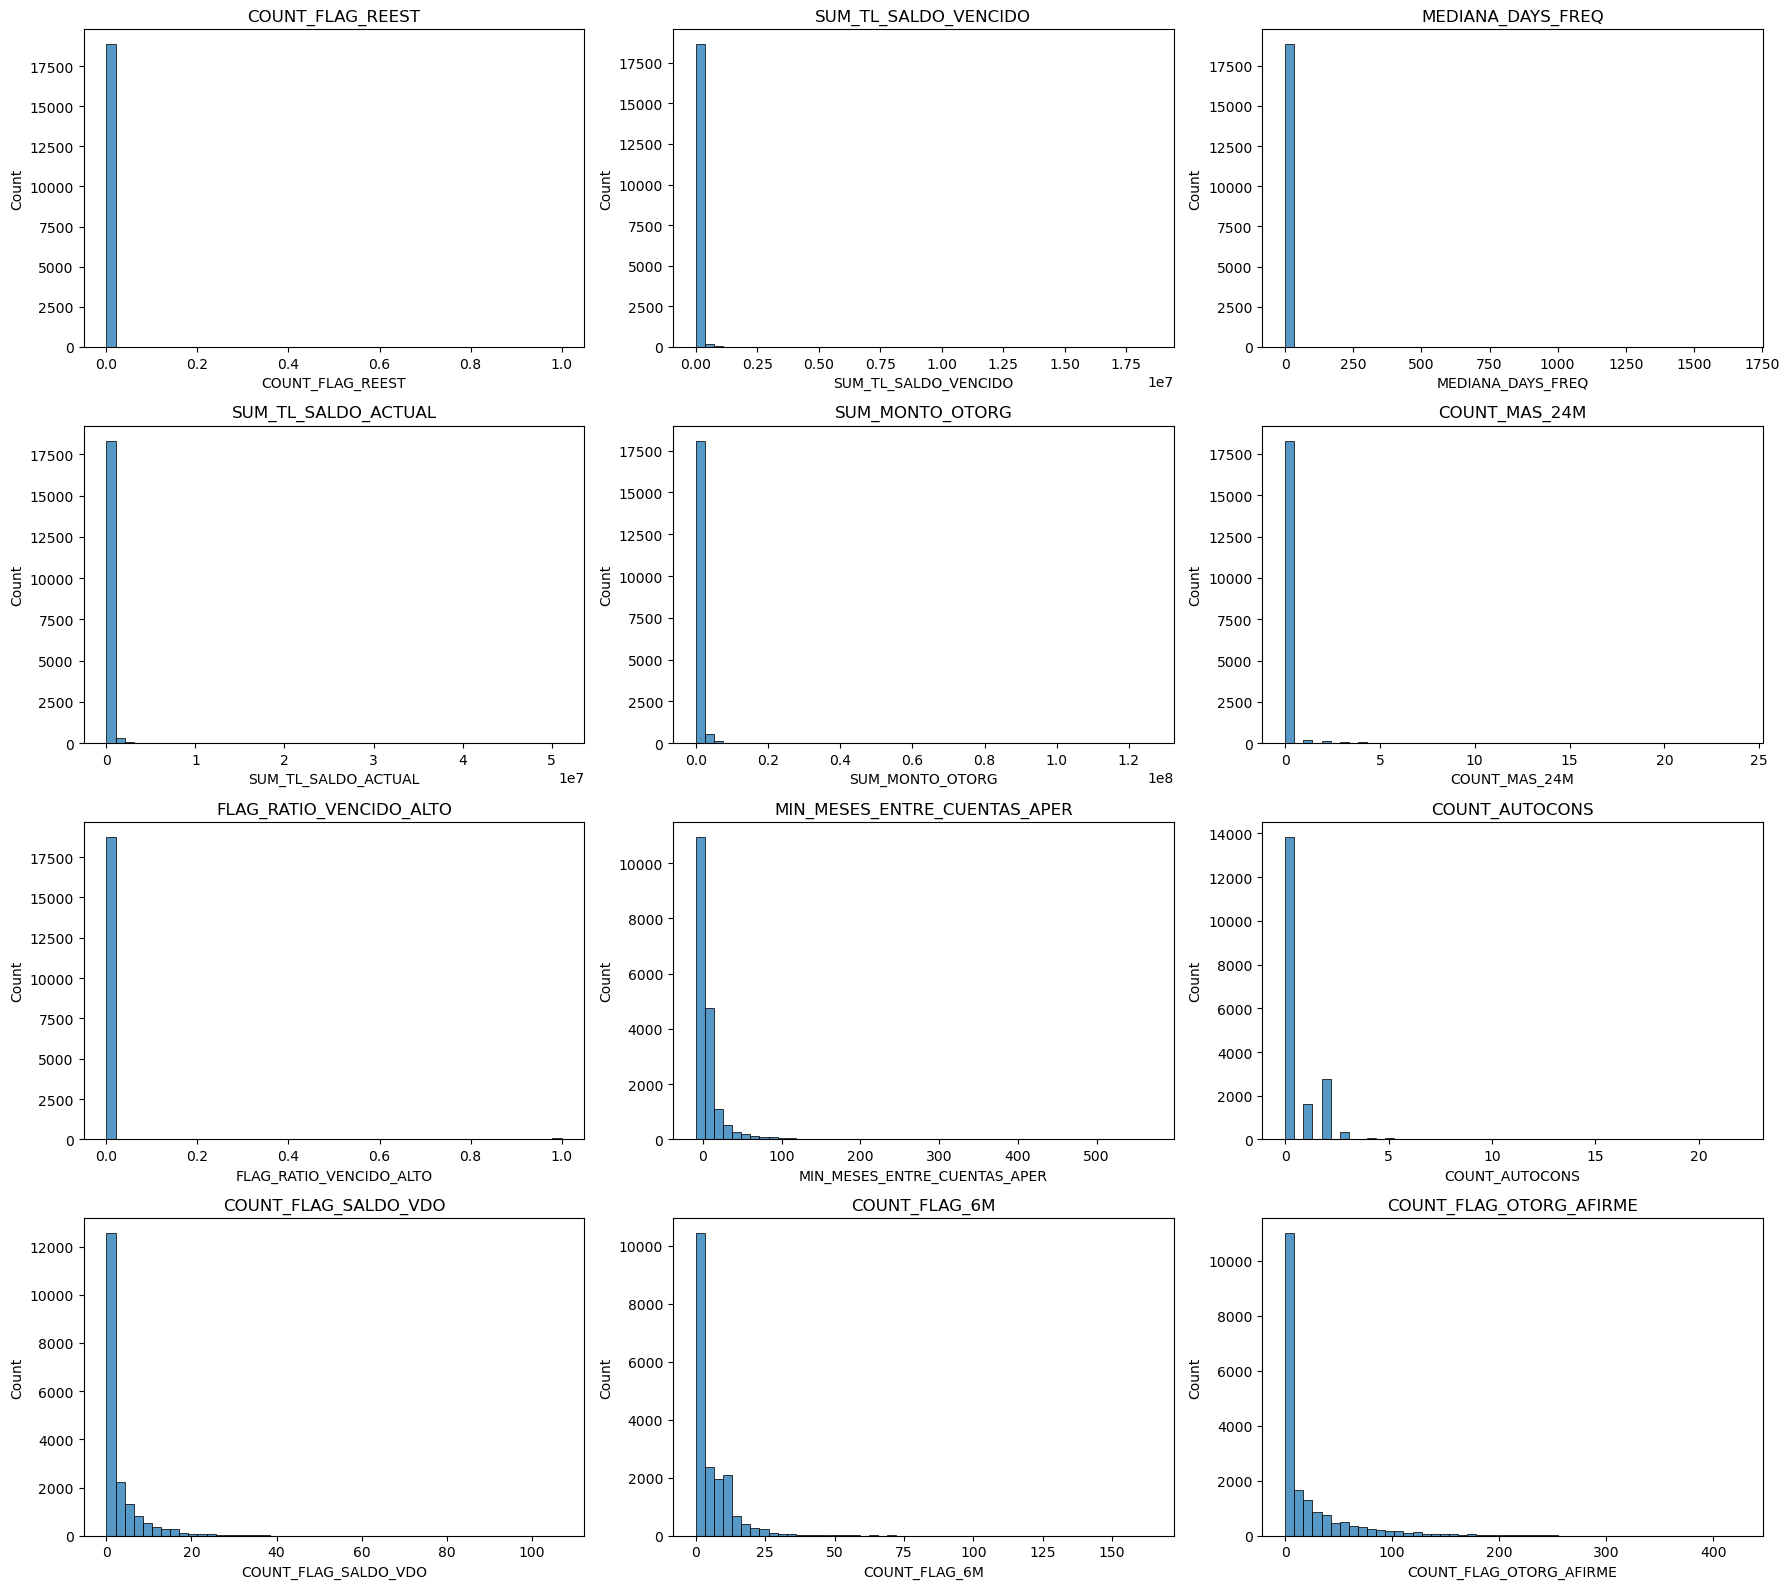

In [389]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_graficar = skewness.head(12).index.tolist()

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18,16)
)

axes = axes.flatten()

for i, col in enumerate(variables_graficar):
    
    sns.histplot(
        Xtrain[col],
        bins=50,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col}")

plt.tight_layout()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\ProgramData\anaconda3\Lib\site-packages\seabo

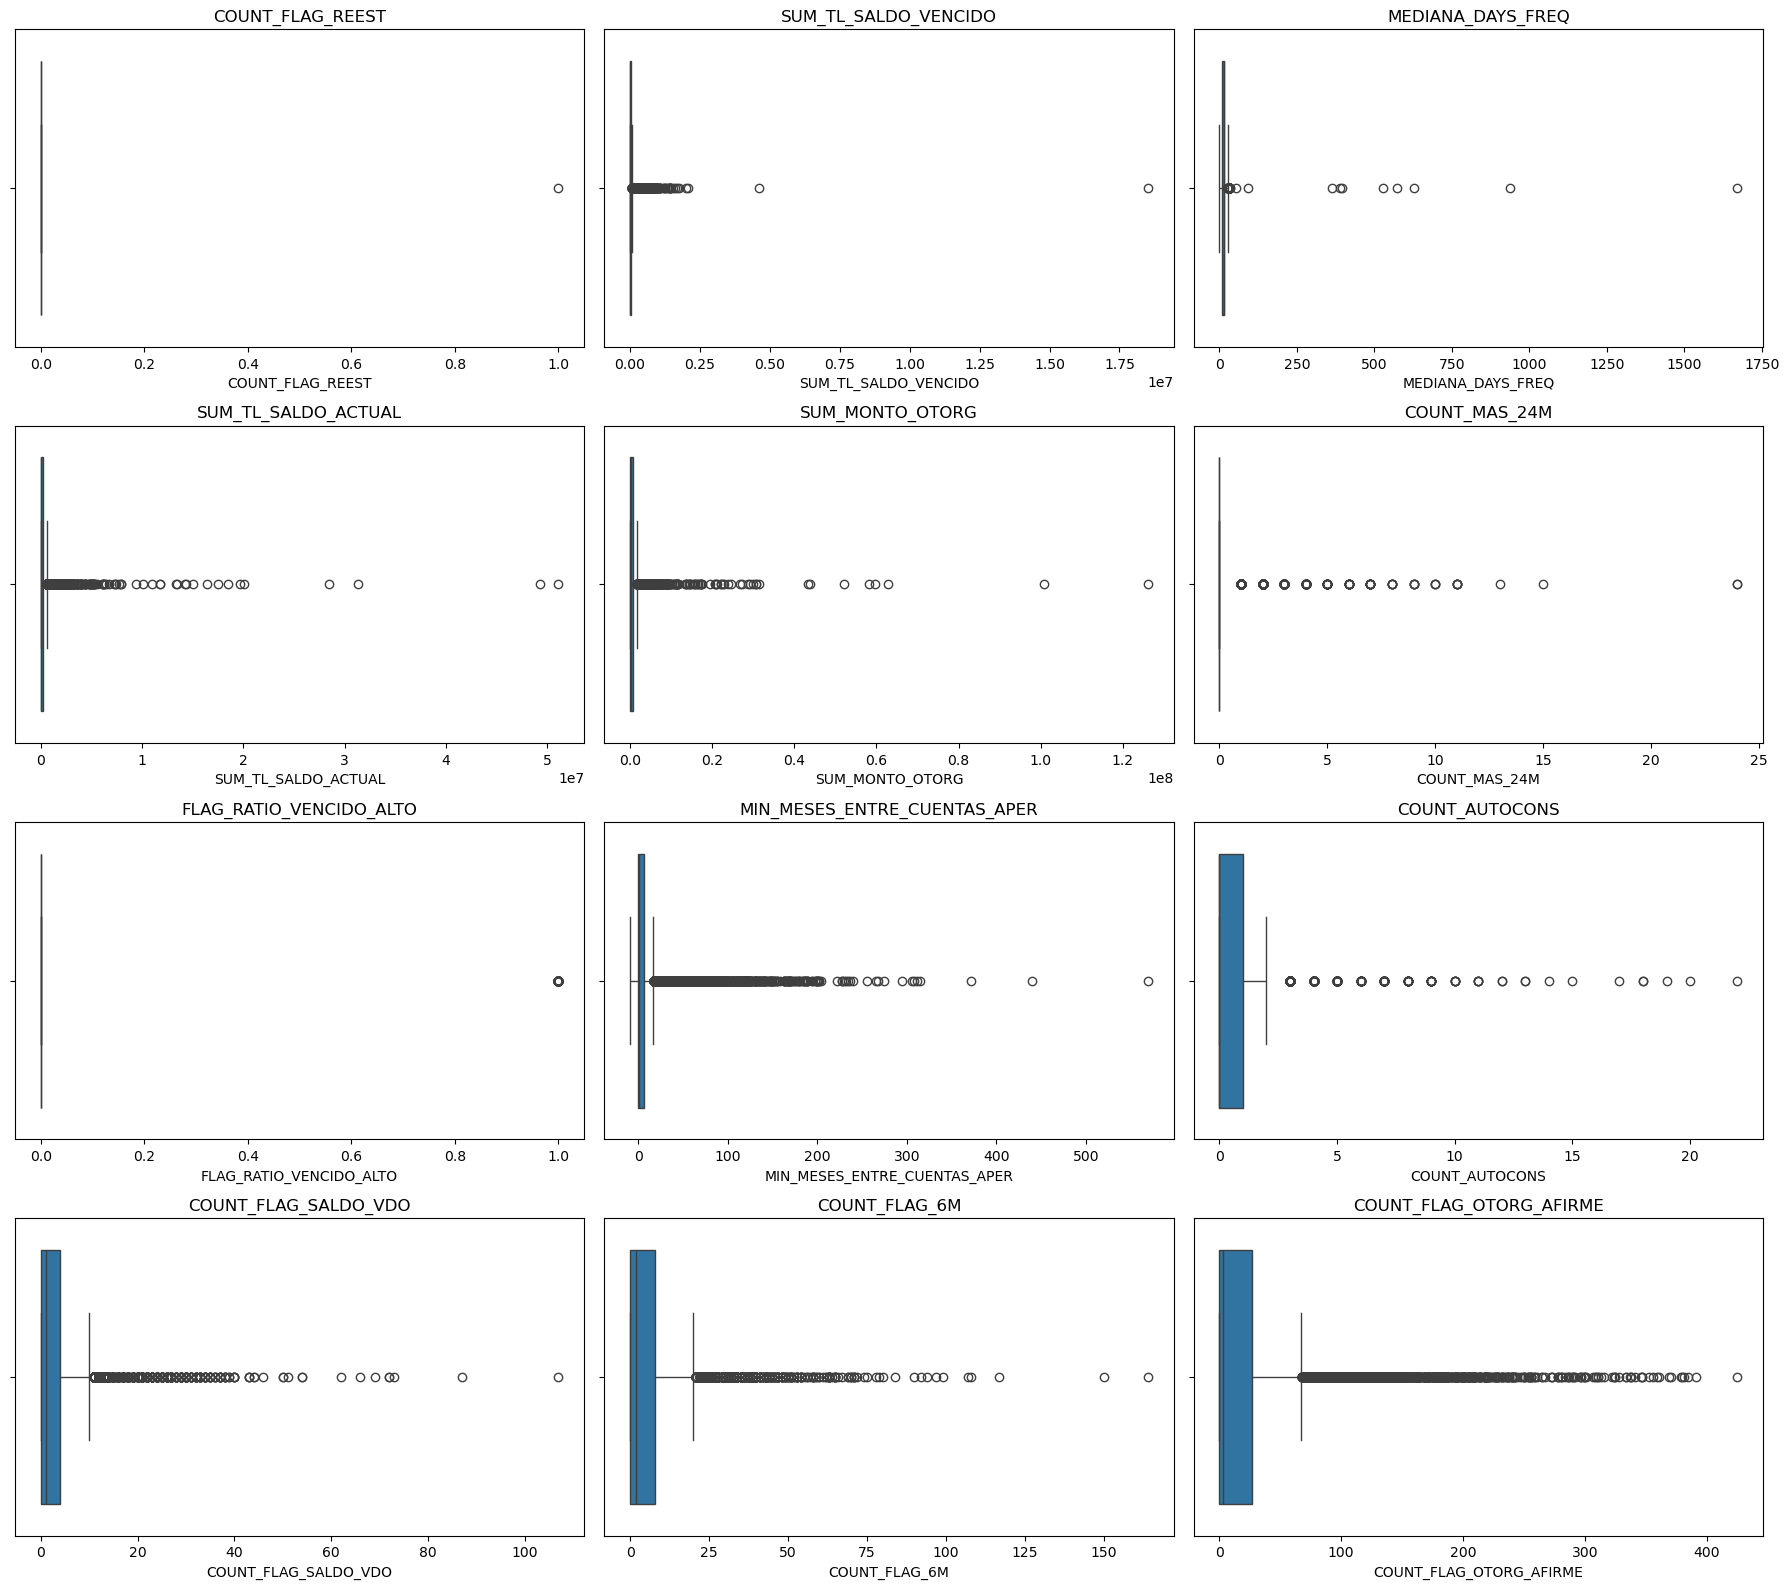

In [390]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18,16)
)

axes = axes.flatten()

for i, col in enumerate(variables_graficar):
    
    sns.boxplot(
        x=Xtrain[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col}")

plt.tight_layout()
plt.show()

### 7.7.3 Interpretabilidad e importancia de variables

En el contexto financiero la capacidad de explicar que variables influyen en la estimacion de ingresos resulta especialmente importante para facilitar la validacion del modelo y generar confianza en los resultados.

Debido a que Ridge Regression corresponde a un modelo lineal regularizado es posible analizar directamente los coeficientes asociados a cada variable transformada. La magnitud absoluta de estos coeficientes permite identificar que variables tienen mayor influencia sobre la prediccion del ingreso mensual estimado.

In [391]:
feature_names = preprocessor.get_feature_names_out()

print("Total features transformadas:", len(feature_names))

Total features transformadas: 52


In [394]:
coeficientes = ridge.coef_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
})

importance_df["Abs_Coef"] = np.abs(
    importance_df["Coeficiente"]
)

In [395]:
importance_df = importance_df.sort_values(
    by="Abs_Coef",
    ascending=False
)

importance_df.head(20)

,Variable,Coeficiente,Abs_Coef
51,cat__REGION_Sureste,-0.19,0.19
50,cat__REGION_Norte,0.13,0.13
49,cat__REGION_Centro_Occidente,0.12,0.12
40,cat__ESTADO_CIVIL_4,-0.11,0.11
17,num__COUNT_FLAG_CLOSED,0.10,0.10
12,num__COUNT_AUTOCONS,0.09,0.09
42,cat__ESTADO_CIVIL_6,-0.09,0.09
0,num_log__SUM_MONTO_OTORG,0.09,0.09
30,num__ANTIGUEDAD_CLIENTE_ANIOS,0.08,0.08
43,cat__ESTADO_CIVIL_7,0.07,0.07


El modelo detecto que las regiones estan asociadas con ingresos mas altos. Esto no significa causalidad,solo significa que en los datos observados el modelo encontro asociacion estadistica.

Variable financiera importante: **num__COUNT_FLAG_CLOSED**, esto nos indica relacion con el numero de creditos que ha tenido historicamente

**num_log__SUM_MONTO_OTORG** indicaria que quienes tienen cuentas con mayores saldos suelen tener mayor capacidad financiera

**num__COUNT_FLAG_SALDO_VDO** nos dice que clientes con saldo vencido tienden a relacionarse con menor capacidad financiera.

El modelo identifica señal predictiva relevante en:

- variables financieras
- variables geograficas
- historial crediticio

Las variables geograficas presentan alta influencia relativa, particularmente ciertos estados y ciudades.

Variables relacionadas con monto otorgado y saldo vencido muestran coherencia financiera con el problema que busca el banco.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


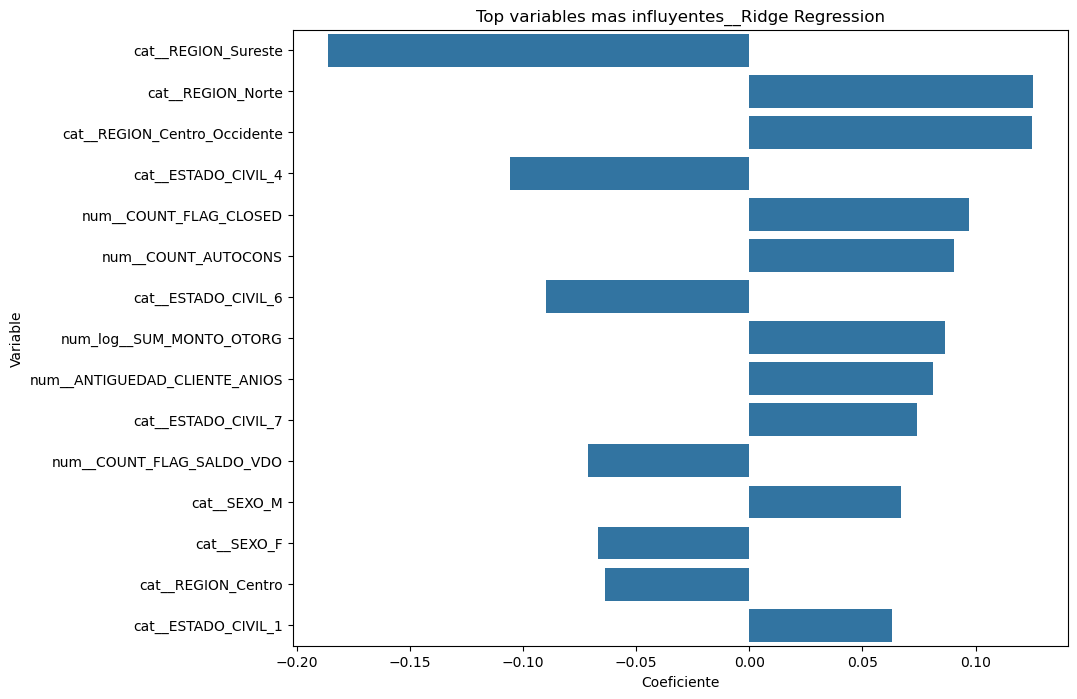

In [399]:
top_n = 15

top_features = importance_df.head(top_n)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    y="Variable",
    x="Coeficiente"
)

plt.title(
    "Top variables mas influyentes__Ridge Regression"
)

plt.xlabel("Coeficiente")
plt.ylabel("Variable")

plt.show()

Positivos = aumentan ingreso estimado.

Negativos = disminuyen ingreso estimado.

Variables positivas

In [397]:
top_positivas = importance_df.sort_values(
    by="Coeficiente",
    ascending=False
)

top_positivas.head(10)

,Variable,Coeficiente,Abs_Coef
50,cat__REGION_Norte,0.13,0.13
49,cat__REGION_Centro_Occidente,0.12,0.12
17,num__COUNT_FLAG_CLOSED,0.10,0.10
12,num__COUNT_AUTOCONS,0.09,0.09
0,num_log__SUM_MONTO_OTORG,0.09,0.09
30,num__ANTIGUEDAD_CLIENTE_ANIOS,0.08,0.08
43,cat__ESTADO_CIVIL_7,0.07,0.07
36,cat__SEXO_M,0.07,0.07
37,cat__ESTADO_CIVIL_1,0.06,0.06
38,cat__ESTADO_CIVIL_2,0.05,0.05


Variables negativas

In [398]:
top_negativas = importance_df.sort_values(
    by="Coeficiente",
    ascending=True
)

top_negativas.head(10)

,Variable,Coeficiente,Abs_Coef
51,cat__REGION_Sureste,-0.19,0.19
40,cat__ESTADO_CIVIL_4,-0.11,0.11
42,cat__ESTADO_CIVIL_6,-0.09,0.09
20,num__COUNT_FLAG_SALDO_VDO,-0.07,0.07
35,cat__SEXO_F,-0.07,0.07
48,cat__REGION_Centro,-0.06,0.06
2,num_log__SUM_TL_SALDO_VENCIDO,-0.06,0.06
32,num__RATIO_SALDO_ACTUAL_MONTO,-0.05,0.05
8,num__time_min_mean,-0.04,0.04
23,num__MAX_PEOR_MOP_IN_3M,-0.04,0.04


### Conclusiones

Se responden las siguientes preguntas

### ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo? 

Se considea el algoritmo de Regresion Ridge como modelo de baseline debido a sus cortos tiempos de entrenamiento y que no es complejo. Este modelo baseline nos ayuda a tener primera idea de si nuestros modelos futuros tendran buen desempeño, o si bien, nos pueden indicar si es recomendable añadir mas variables

### ¿Se puede determinar la importancia de las características para el modelo generado?

Asi es, en un primer ejercicio puede ser reviasr los coeficientes de las variables y observar cuales tienen mayores valores absolutos (tiene que ser valor absoluto ya que una variable puede tener coeficiente negativo muy grande, lo que igualmente indica un impacto muy importante en el modelo)

### ¿El modelo está sub/sobreajustando los datos de entrenamiento?

Para los conjuntos de entrenamiento y validacion se observan porcentajes muy similares de R2, asi como de MAPE, lo que indica que estos porcentajes de error son casi los mismos para ambas poblaciones, considerando asi que los valores que se predicen para ambos conjuntos de datos tienen el mismo porcentaje de acertividad, por lo que se puede considerar que el modelo no presenta sub ni sobre ajuste.

### ¿Cuál es la métrica adecuada para este problema de negocio? 

Ambas metricas (R2 y MAPE) son correctas para su consideracion. R2 puede considerarse para revisar la calidad de las predicciones que hace el modelo y entender que tanto las variables del modelo explican el problema, mientras que el MAPE nos ayuda a entender el porcentaje de desviación entre la predicción y el valor real

### ¿Cuál debería ser el desempeño mínimo a obtener?

Segun lo definido con el negocio, el desempeño minimo deseado debe ser 15% de desviacion (ya sea positiva o negativa) de la prediccion contra el valor real